In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



# Is VAL disturbance related info routed to Mop and CP

In [4]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [5]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [6]:
df__ = dt.add_pca_df(df_)

In [7]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [13]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()
fields = [
    'power',
    'phases', 
    'MOp_rates_pca_concat',
    'SSp_rates_pca_concat',
    'VAL_rates_pca_concat',
    'CP_rates_pca_concat',
    'bhv_concat'
    ]
for field in fields:
    df_tr_sliced[field] = df_tr.apply(
        lambda row: row[field][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
        axis=1
    )

# Add instantaneous phase
df_tr_sliced["perturb_phase"] = df_tr_sliced["phases"].apply(lambda a: a[300, :])

disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


## Predict Disturb Score from 

In [8]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [134]:
areas = ['VAL', 'MOp', 'CP', 'SSp']
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)
# test_df = perturb_td.sample(frac=1, random_state=33).reset_index(drop=True)

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
rank = 50
res = {}
for area in areas:
    if area != 'VAL':
        emb = subspaces.compute_embedding(
                    perturb_td__,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=rank)
                )
        arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]
    else:
        arr = np.stack(perturb_td[f'VAL_rates_pca'])[:, 200:, :]
    n_trials, _, _ = arr.shape
    res[area] = cross_val_score(
        Ridge(100),
        arr.reshape(n_trials, -1),
        perturb_td.disturb_sum.values,
        cv=5,
        scoring=vw_r2_scorer
    )
    # print(f'VAL -> {area} r2 mean: {r2s.mean():.3f}, r2 std: {r2s.std():.3f}')



In [132]:
n_trials

100

Text(0.5, 1.0, 'Decoding disturb sum. Rank 50. VAL comm space. 200 trials. Potent')

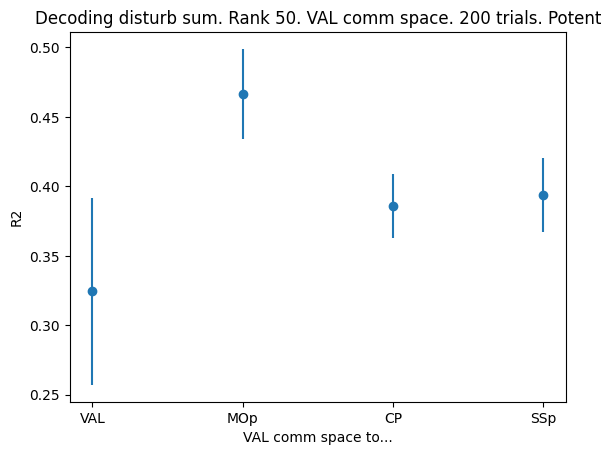

In [135]:
fig, ax = plt.subplots()
ax.errorbar(
    areas, 
    [val.mean() for val in res.values()], 
    yerr=[val.std() for val in res.values()],
    fmt='o')
ax.set_ylabel(f'R2')
ax.set_xlabel(f'VAL comm space to...')
# ax.set_ylim(0, 0.5)

ax.set_title(f'Decoding disturb sum. Rank {rank}. VAL comm space. 200 trials. Potent')

In [11]:
areas = ['VAL', 'MOp', 'CP', 'SSp']
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
rank = 30
res = {}
for area in areas:
    if area != 'VAL':
        emb = subspaces.compute_embedding(
                    perturb_td__,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=rank),
                    null=True
                )
        arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]
    else:
        arr = np.stack(perturb_td[f'VAL_rates_pca'])[:, 200:, :]
    n_trials, _, _ = arr.shape
    res[area] = cross_val_score(
        Ridge(100),
        arr.reshape(n_trials, -1),
        perturb_td.disturb_sum.values,
        cv=5,
        scoring=vw_r2_scorer
    )
    # print(f'VAL -> {area} r2 mean: {r2s.mean():.3f}, r2 std: {r2s.std():.3f}')



Text(0.5, 1.0, 'Decoding disturb sum. Rank 30. VAL comm space. 200 trials. Null')

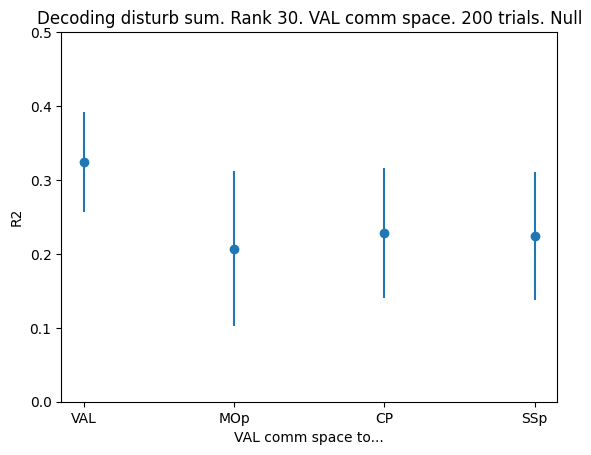

In [12]:
fig, ax = plt.subplots()
ax.errorbar(
    areas, 
    [val.mean() for val in res.values()], 
    yerr=[val.std() for val in res.values()],
    fmt='o')
ax.set_ylabel(f'R2')
ax.set_xlabel(f'VAL comm space to...')
ax.set_ylim(0, 0.5)
ax.set_title(f'Decoding disturb sum. Rank {rank}. VAL comm space. 200 trials. Null')

In [39]:
emb = subspaces.compute_embedding(
            perturb_td,
            f'VAL_rates_pca',
            ['MOp_rates_pca', 'CP_rates_pca'],
            (0, 500),
            subspaces.ReducedRankCommSubspace(rank=50),
            null=False
        )
arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]

n_trials, _, _ = arr.shape
r2s_potent = cross_val_score(
    Ridge(100),
    arr.reshape(n_trials, -1),
    perturb_td.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)
print(f'VAL -> Mop, CP r2 mean: {r2s_potent.mean():.3f}, r2 std: {r2s_potent.std():.3f}')

emb = subspaces.compute_embedding(
            perturb_td,
            f'VAL_rates_pca',
            ['MOp_rates_pca', 'CP_rates_pca'],
            (0, 500),
            subspaces.ReducedRankCommSubspace(rank=30),
            null=True
        )
arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]

n_trials, _, _ = arr.shape
r2s_null = cross_val_score(
    Ridge(100),
    arr.reshape(n_trials, -1),
    perturb_td.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)
print(f'VAL -> Mop, CP Null r2 mean: {r2s_null.mean():.3f}, r2 std: {r2s_null.std():.3f}')


VAL -> Mop, CP r2 mean: 0.219, r2 std: 0.217
VAL -> Mop, CP Null r2 mean: 0.128, r2 std: 0.163


Text(0.5, 1.0, 'Decoding disturb sum. Rank 50. VAL comm space. 200 trials')

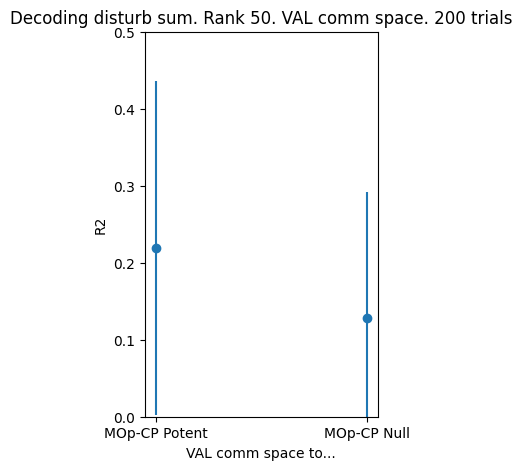

In [40]:
fig, ax = plt.subplots(figsize=(3, 5))
ax.errorbar(
    ['MOp-CP Potent', 'MOp-CP Null'], 
    [r2s_potent.mean(), r2s_null.mean()], 
    yerr=[r2s_potent.std(), r2s_null.std()],
    fmt='o')
ax.set_ylabel(f'R2')
ax.set_xlabel(f'VAL comm space to...')
ax.set_ylim(0, 0.5)
ax.set_title(f'Decoding disturb sum. Rank {rank}. VAL comm space. 200 trials')

## Check explained variances

In [61]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [63]:
area = 'MOp'
rank=30
emb = subspaces.compute_embedding(
                    perturb_td,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=rank)
                )
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, 200:, :]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
print(f'Variance in VAL-{area}: {var_} Potent')

area = 'MOp'
emb = subspaces.compute_embedding(
                    perturb_td,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=rank),
                    null=True
                )
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, 200:, :]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
print(f'Variance in VAL-{area}: {var_} Null')

Variance in VAL-MOp: 2853.5730064285904 Potent
Variance in VAL-MOp: 16499.19991864492 Null


In [64]:
arr.shape

(100, 301, 168)

In [72]:
val_rank = 7
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, 200:, :val_rank]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), np.eye(val_rank))
print(f'Variance in VAL: {var_}')

Variance in VAL: 3288.083400648786


In [53]:
area = 'MOp'
emb = subspaces.compute_embedding(
                    perturb_td,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=50)
                )
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, :, :]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
print(f'Variance in VAL-{area}: {var_} Potent')

area = 'MOp'
emb = subspaces.compute_embedding(
                    perturb_td,
                    f'VAL_rates_pca',
                    f'{area}_rates_pca',
                    (0, 500),
                    subspaces.ReducedRankCommSubspace(rank=50),
                    null=True
                )
arr = np.stack(perturb_td[f'VAL_rates_pca'].values)[:, :, :]
var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
print(f'Variance in VAL-{area}: {var_} Null')

Variance in VAL-MOp: 4289.872321014969 Potent
Variance in VAL-MOp: 14387.43350751314 Null


## Check potent vs. null for increasing ranks

In [94]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [132]:

areas = ['MOp', 'CP', 'SSp']
area = 'SSp'
ranks = np.arange(10, 100, step=1)
res = {}
for area in areas:
    res[area] = {}
    r2s = []
    vars_ = []
    for rank in tqdm(ranks):
        emb = subspaces.compute_embedding(
                            perturb_td_,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank)
                        )
        arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]
        r2 = cross_val_score(
                Ridge(100),
                arr.reshape(n_trials, -1),
                perturb_td.disturb_sum.values,
                cv=5,
                scoring=vw_r2_scorer
            )
        r2s.append(r2)
        arr = np.stack(perturb_td[f'VAL_rates_pca'].values)
        var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
        vars_.append(var_)

    res[area]['r2s'] = np.array(r2s)
    res[area]['vars'] = np.array(vars_)

100%|██████████| 90/90 [02:12<00:00,  1.47s/it]


In [154]:

areas = ['MOp', 'CP', 'SSp']
area = 'SSp'
ranks = np.arange(10, 100, step=1)
res_null = {}
for area in areas:
    res_null[area] = {}
    r2s = []
    vars_ = []
    for rank in tqdm(ranks):
        emb = subspaces.compute_embedding(
                            perturb_td_,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
        arr = np.array([arr_ @ emb for arr_ in perturb_td[f'VAL_rates_pca'].values])[:, 200:, :]
        r2 = cross_val_score(
                Ridge(100),
                arr.reshape(n_trials, -1),
                perturb_td.disturb_sum.values,
                cv=5,
                scoring=vw_r2_scorer
            )
        r2s.append(r2)
        arr = np.stack(perturb_td[f'VAL_rates_pca'].values)
        var_ = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), emb)
        vars_.append(var_)

    res_null[area]['r2s'] = np.array(r2s)
    res_null[area]['vars'] = np.array(vars_)

100%|██████████| 90/90 [02:21<00:00,  1.57s/it]


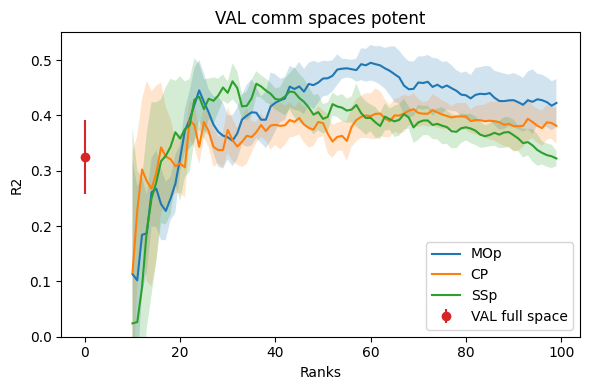

In [155]:
arr = np.stack(perturb_td[f'VAL_rates_pca'])[:, 200:, :]
n_trials, _, _ = arr.shape
r2 = cross_val_score(
    Ridge(100),
    arr.reshape(n_trials, -1),
    perturb_td.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(6, 4))

for area in areas:
    vizutils.shaded_errorbar(ax, ranks, res[area]['r2s'], label=area)

ax.errorbar(0, r2.mean(), yerr=r2.std(), fmt='o', label='VAL full space')
ax.legend()
ax.set_xlabel('Ranks')
ax.set_ylabel('R2')
ax.set_title('VAL comm spaces potent')

ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.show()

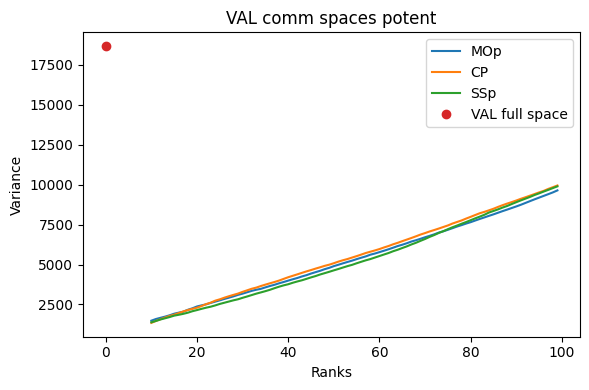

In [161]:
arr = np.stack(perturb_td[f'VAL_rates_pca'])
var_val = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), np.eye(arr.shape[-1]))
# n_trials, _, _ = arr.shape
# r2 = cross_val_score(
#     Ridge(100),
#     arr.reshape(n_trials, -1),
#     perturb_td.disturb_sum.values,
#     cv=5,
#     scoring=vw_r2_scorer
# )

fig, ax = plt.subplots(figsize=(6, 4))

for area in areas:
    ax.plot(ranks, res[area]['vars'], label=area)

ax.errorbar(0, var_val, fmt='o', label='VAL full space')
ax.legend()
ax.set_xlabel('Ranks')
ax.set_ylabel('Variance')
ax.set_title('VAL comm spaces potent')
# ax.set_yscale('log')
# ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.show()

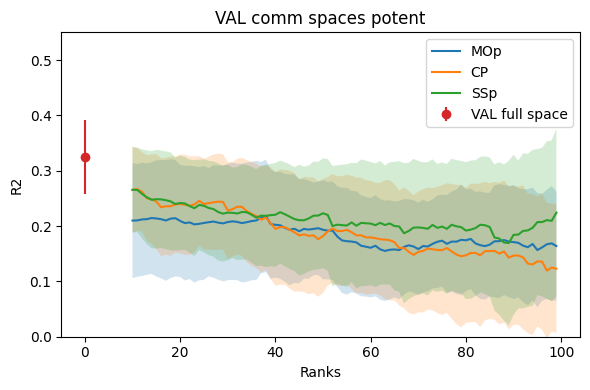

In [162]:
arr = np.stack(perturb_td[f'VAL_rates_pca'])[:, 200:, :]
n_trials, _, _ = arr.shape
r2 = cross_val_score(
    Ridge(100),
    arr.reshape(n_trials, -1),
    perturb_td.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(6, 4))

for area in areas:
    vizutils.shaded_errorbar(ax, ranks, res_null[area]['r2s'], label=area)

ax.errorbar(0, r2.mean(), yerr=r2.std(), fmt='o', label='VAL full space')
ax.legend()
ax.set_xlabel('Ranks')
ax.set_ylabel('R2')
ax.set_title('VAL comm spaces potent')

ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.show()

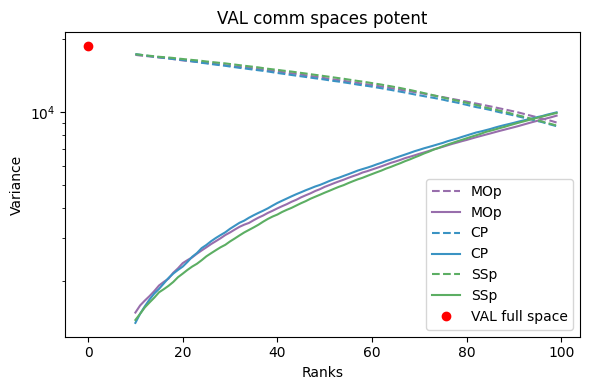

In [172]:
arr = np.stack(perturb_td[f'VAL_rates_pca'])
var_val = subspaces.variance_in_subspace(arr.reshape(-1, arr.shape[-1]), np.eye(arr.shape[-1]))
# n_trials, _, _ = arr.shape
# r2 = cross_val_score(
#     Ridge(100),
#     arr.reshape(n_trials, -1),
#     perturb_td.disturb_sum.values,
#     cv=5,
#     scoring=vw_r2_scorer
# )

fig, ax = plt.subplots(figsize=(6, 4))

for area in areas:
    ax.plot(ranks, res_null[area]['vars'], label=area, linestyle='--', color=getattr(colors, f'{area}_light'))
    ax.plot(ranks, res[area]['vars'], label=area, color=getattr(colors, f'{area}_light'))

ax.errorbar(0, var_val, fmt='o', label='VAL full space', color='red')
ax.legend()
ax.set_xlabel('Ranks')
ax.set_ylabel('Variance')
ax.set_title('VAL comm spaces potent')
ax.set_yscale('log')
# ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.show()

In [180]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = 0, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = 0, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [173]:
np.concatenate(perturb_td_.VAL_rates_pca.values).shape

(143286, 168)

In [192]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

r2 = cross_val_score(
    Ridge(100),
    np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
    np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
    cv=5,
    scoring=vw_r2_scorer
)
print(f'Score {r2.mean()}, std = {r2.std()}')

Score 0.1425518810749054, std = 0.008614224631406426


## Remove MOp from val activity

In [9]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [77]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'MOp'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

118
68
18


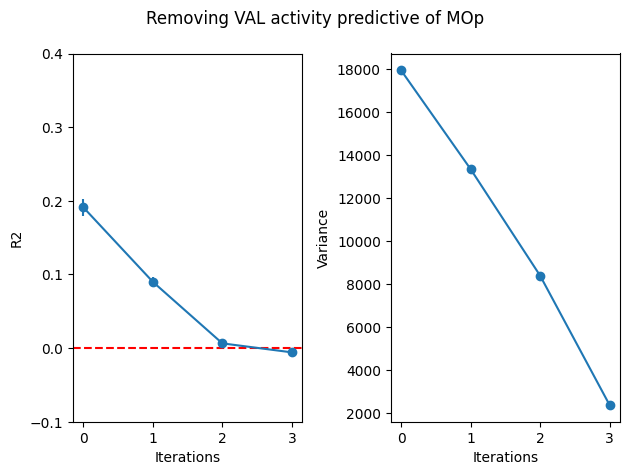

In [90]:
fig, ax = plt.subplots(1, 2)
plt.suptitle('Removing VAL activity predictive of MOp')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()


In [104]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'MOp'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

50


ValueError: 'x' and 'y' must have the same size

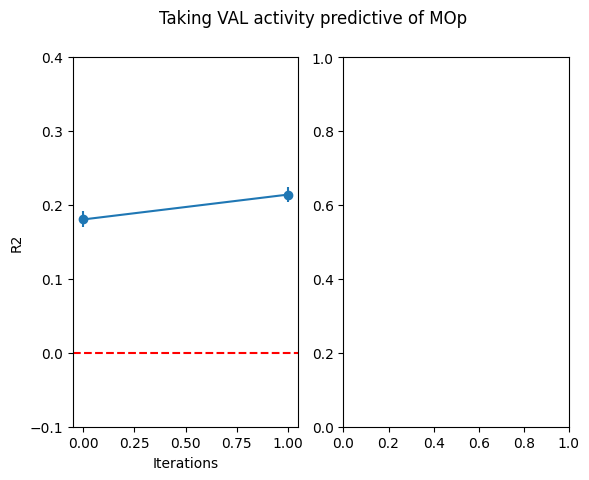

In [143]:
fig, ax = plt.subplots(1, 2)
plt.suptitle('Taking VAL activity predictive of MOp')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()


## Final check - MOp

In [159]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__["val_null_mop"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_mop',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'val_null_mop', 'val_null_mop')
    dim_val = np.stack(perturb_td__.val_null_mop.values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'val_potent_mop')

118
68


{'mop_potent': 4378.909835706939, 'mop_null': 8494.837885893015}

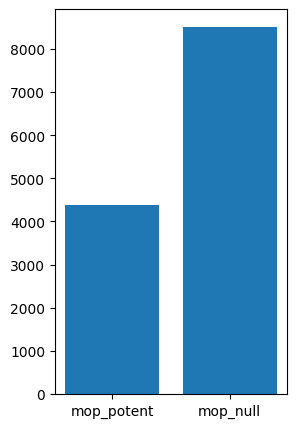

In [160]:
vars_ = {
    'mop_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.val_potent_mop.values),
        np.eye(50)
        ),
    'mop_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.val_null_mop.values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_.keys(), vars_.values())
vars_

In [167]:
perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))



Text(0.5, 1.0, 'Variance in VAL subspaces')

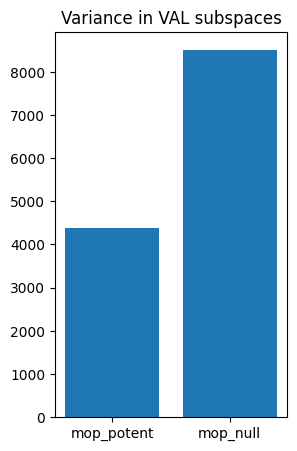

In [175]:
vars_sorted = {
    'mop_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted.val_potent_mop.values),
        np.eye(50)
        ),
    'mop_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted.val_null_mop.values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_.keys(), vars_.values())
ax.set_title('Variance in VAL subspaces')

In [171]:
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_mop'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)
arr_null = np.stack(perturb_td_resorted[f'val_null_mop'])[:, 200:, :]

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

Text(0, 0.5, 'R2')

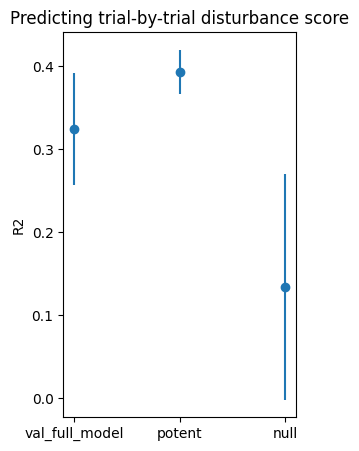

In [174]:
fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')

## Final check - CP

118
68
18
50
118
68


(-0.02, 0.45)

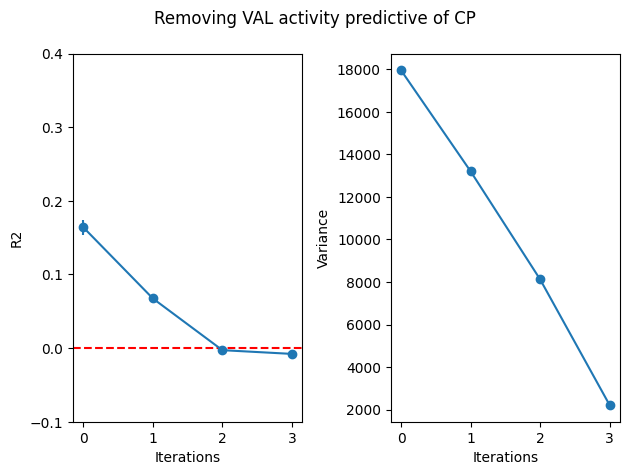

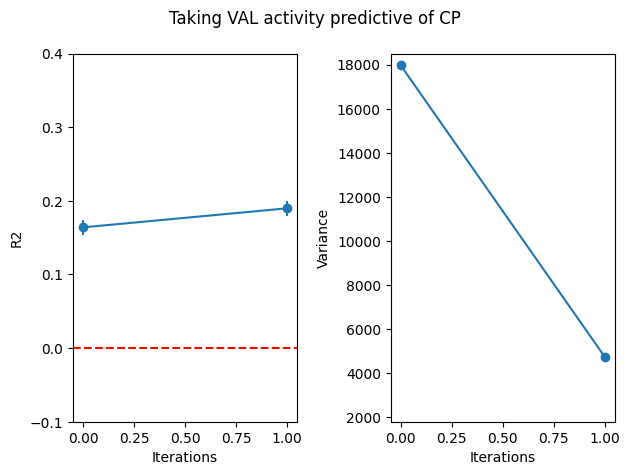

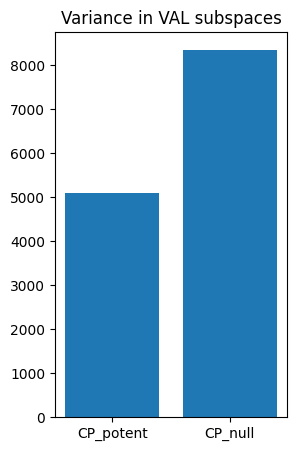

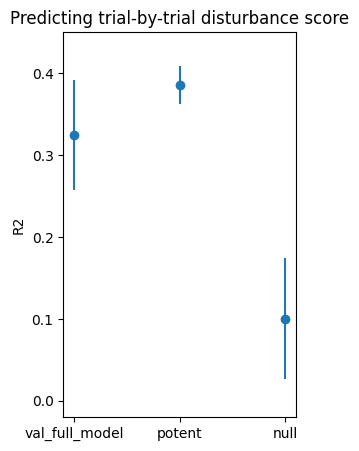

In [202]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'CP'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(50)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in VAL subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.45)


## Final check - SSp

118
68
18
50
118
68


(-0.02, 0.45)

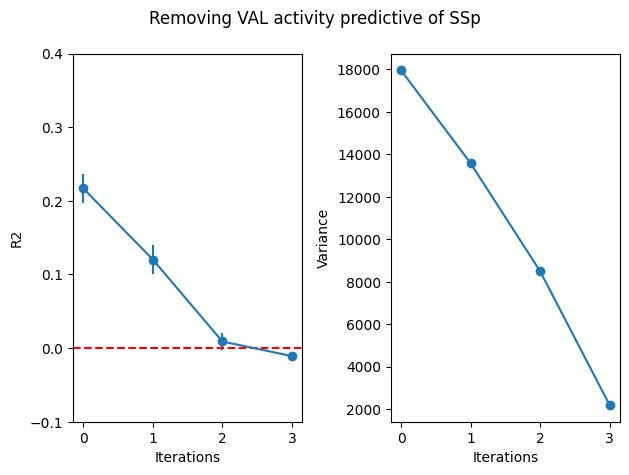

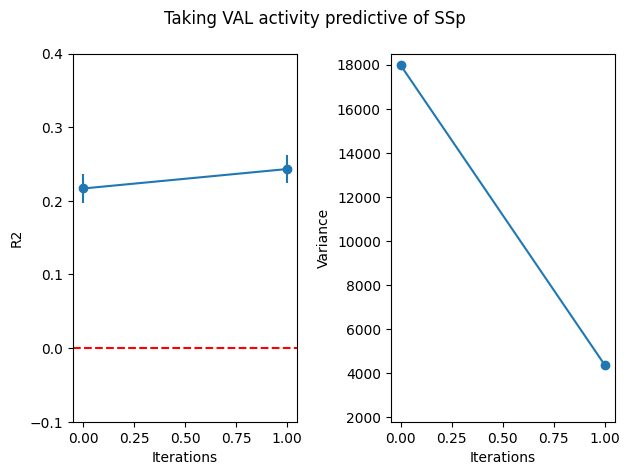

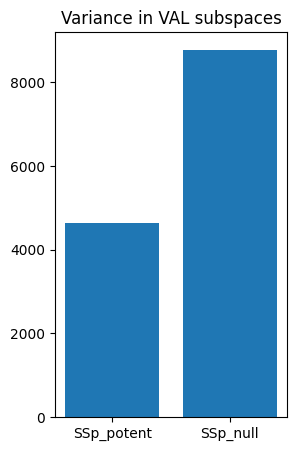

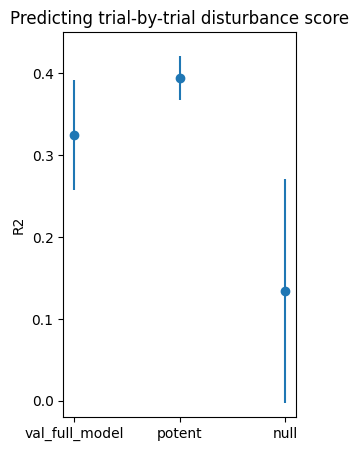

In [200]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'SSp'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(50)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in VAL subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.45)


## Final check - GPe?

118
68
18
50
118
68


(-0.02, 0.45)

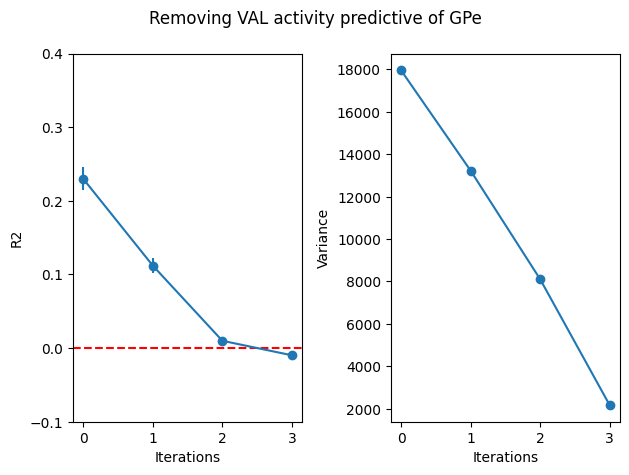

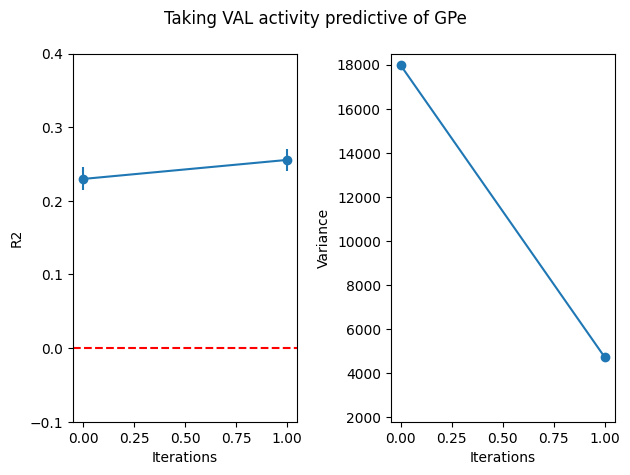

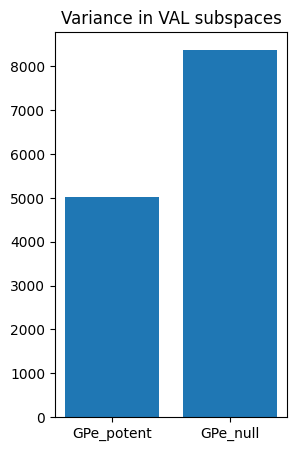

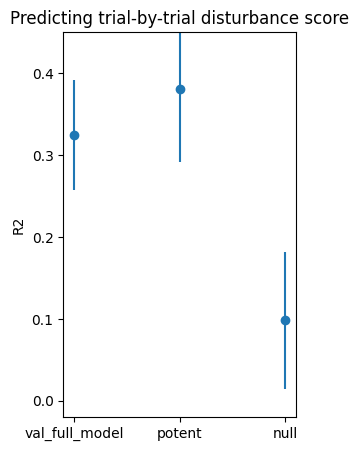

In [11]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
rank = 50
r2s = []
vars_ = []
area = 'GPe'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(50)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in VAL subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.45)


## Final check mop to VAL?

128
78
28
50
128
78
28


(-0.02, 0.6)

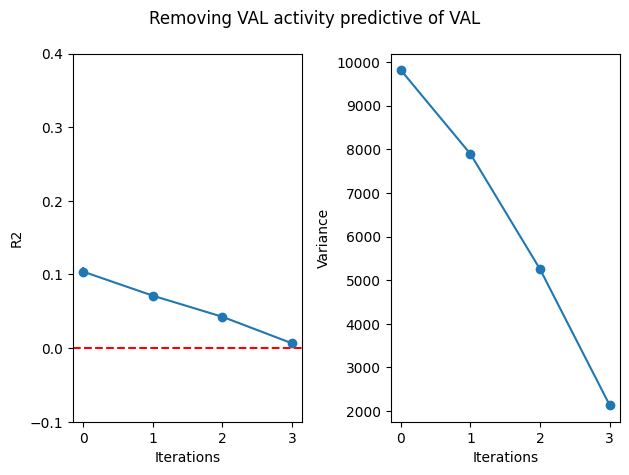

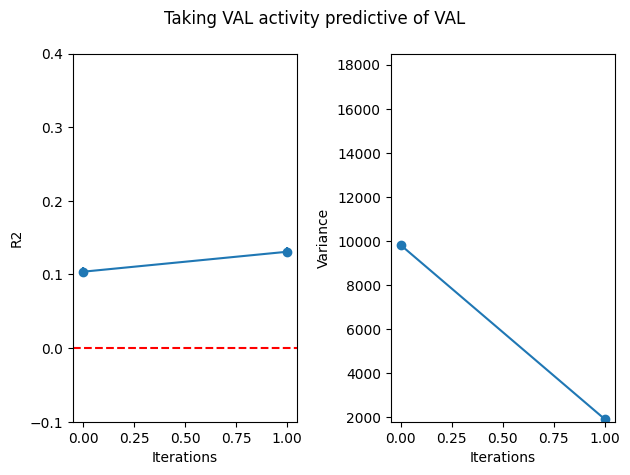

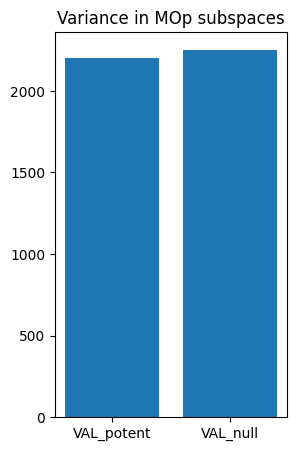

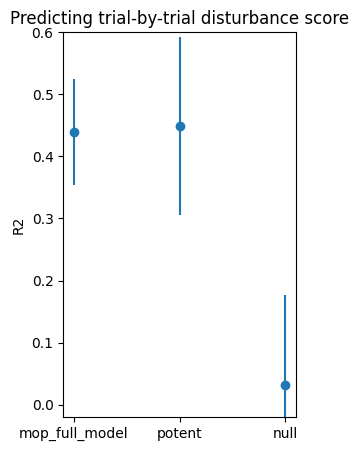

In [17]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'VAL'
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.MOp_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'MOp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'MOp_rates_pca', 'MOp_rates_pca')
    dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.MOp_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.MOp_rates_pca.values),
        np.eye(dim_val)
    ))

rank = 50 
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'MOp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'MOp_rates_pca', 'MOp_rates_pca')
    dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.MOp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.MOp_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.MOp_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["MOp_rates_pca"]
rank = 50 
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'MOp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'MOp_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(50)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in MOp subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'MOp_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['mop_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.6)


## FInal check SSp to MOp?

49
29
9
20
49
29
9


(-0.02, 0.6)

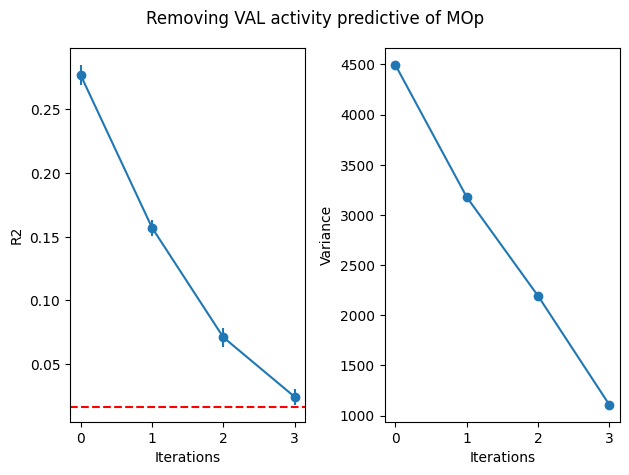

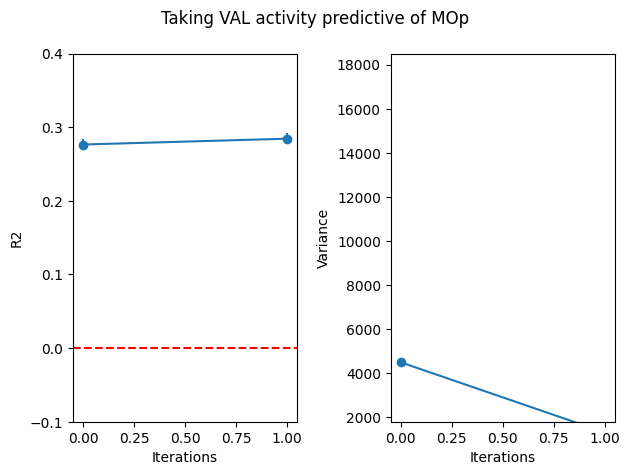

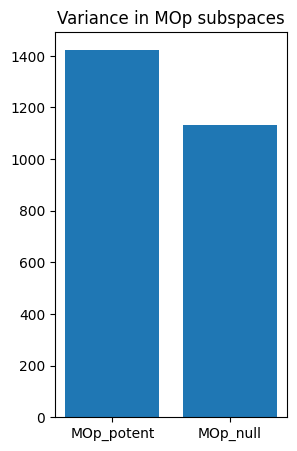

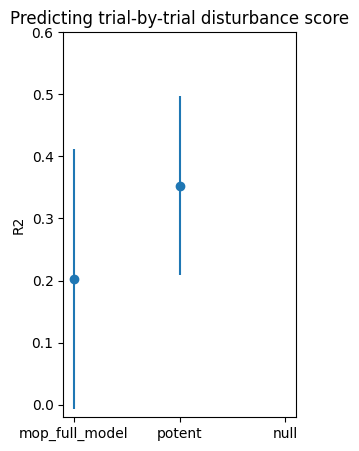

In [32]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)
rank = 20 

dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]

r2s = []
vars_ = []
area = 'MOp'
r2_lowerbound = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td_.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.SSp_rates_pca.values),
        np.eye(dim_val)
    ))

for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'SSp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'SSp_rates_pca', 'SSp_rates_pca')
    dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.SSp_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing VAL activity predictive of {area}')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
# ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(r2_lowerbound.mean(), color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.SSp_rates_pca.values),
        np.eye(dim_val)
    ))

for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'SSp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'SSp_rates_pca', 'SSp_rates_pca')
    dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.SSp_rates_pca.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.SSp_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Taking VAL activity predictive of {area}')
ax[0].errorbar(range(2), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(2), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

ax[1].set_ylim(1800, 18500)
plt.tight_layout()

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.SSp_rates_pca.values).shape[-1]
perturb_td__[f"val_null_{area}"] = perturb_td__["SSp_rates_pca"]
for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_{area}',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, f'val_null_{area}', f'val_null_{area}')
    dim_val = np.stack(perturb_td__[f'val_null_{area}'].values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'SSp_rates_pca',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'SSp_rates_pca', f'val_potent_{area}')

perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

vars_sorted = {
    f'{area}_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_potent_{area}'].values),
        np.eye(rank)
        ),
    f'{area}_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted[f'val_null_{area}'].values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_sorted.keys(), vars_sorted.values())
ax.set_title('Variance in MOp subspaces')
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_{area}'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'SSp_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_{area}'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['mop_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.6)


In [23]:
r2_lowerbound.mean()

-0.664115846157074

## Removing between areas?

In [204]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__["val_null_mop"] = perturb_td__["VAL_rates_pca"]
rank = 50 
area = 'MOp'
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_mop',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'val_null_mop', 'val_null_mop')
    dim_val = np.stack(perturb_td__.val_null_mop.values).shape[-1]
    print(dim_val)


118
68


In [211]:
area = 'CP'
dim_val = np.stack(perturb_td__.val_null_mop.values).shape[-1]
r2s = []
vars_ = []
rank = 10 

r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.val_null_mop.values)[:, :],
        np.concatenate(perturb_td__.CP_rates_pca.values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.val_null_mop.values),
        np.eye(dim_val)
    ))

perturb_td__['val_null_mop_cp'] = perturb_td__['val_null_mop']
for i in range(1):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_mop_cp',
                            f'{area}_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'val_null_mop_cp', 'val_null_mop_cp')
    dim_val = np.stack(perturb_td__.val_null_mop_cp.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.val_null_mop_cp.values)[:, :],
        np.concatenate(perturb_td__[f'{area}_rates_pca'].values)[:, :rank],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.val_null_mop_cp.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

58


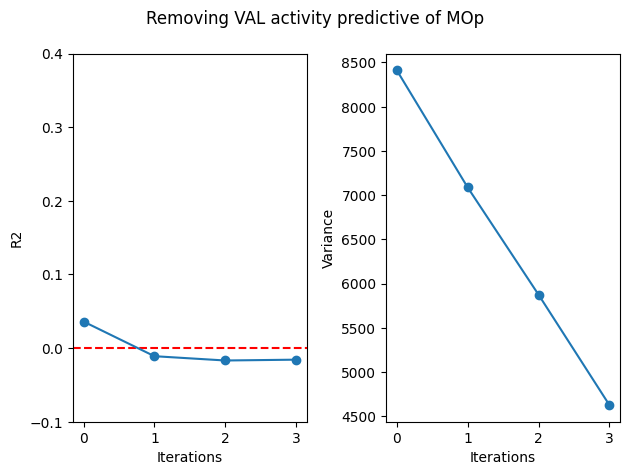

In [210]:
fig, ax = plt.subplots(1, 2)
plt.suptitle('Removing VAL activity predictive of MOp')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()


In [212]:
perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))



(-0.02, 0.45)

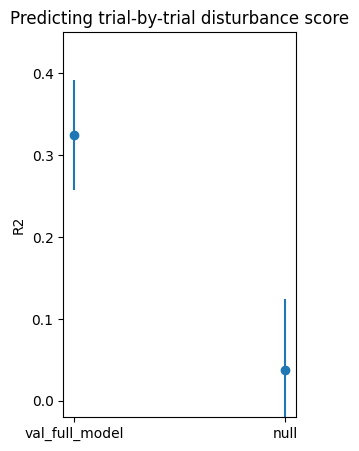

In [217]:
res = {}
# arr_potent = np.stack(perturb_td_resorted[f'val_potent_mop'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_mop_cp'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

# res['potent'] = cross_val_score(
#     Ridge(100),
#     arr_potent.reshape(n_trials, -1),
#     perturb_td_resorted.disturb_sum.values,
#     cv=5,
#     scoring=vw_r2_scorer
# )

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')
ax.set_ylim(-0.02, 0.45)


# Global PCAs??

In [7]:
df__ = dt.add_pca_df(df_, pca_fields = ['VAL_rates'])

In [8]:
df__.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
       'al

In [14]:
df__["all_non_val_rates"] = df__.apply(
    lambda row: np.hstack([row["MOp_rates"], row["CP_rates"], row["SSp_rates"]]),
    axis=1
)

In [17]:
df__ = dt.add_pca_df(df__, pca_fields = ["all_non_val_rates"])

In [20]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


In [21]:
idx = sorted(dstrb_idx[:100])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [41]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
rank = 50 

r2s = []
vars_ = []
r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.all_non_val_rates_pca.values)[:, :rank+100],
        cv=5,
        scoring=vw_r2_scorer
    )
r2s.append(r2)

vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))

for i in range(3):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'all_non_val_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'VAL_rates_pca')
    dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
    print(dim_val)
    r2 = cross_val_score(
        Ridge(100),
        np.concatenate(perturb_td__.VAL_rates_pca.values)[:, :],
        np.concatenate(perturb_td__.all_non_val_rates_pca.values)[:, :rank+100],
        cv=5,
        scoring=vw_r2_scorer
    )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td__.VAL_rates_pca.values),
        np.eye(dim_val)
    ))
r2s = np.array(r2s) 

118
68
18


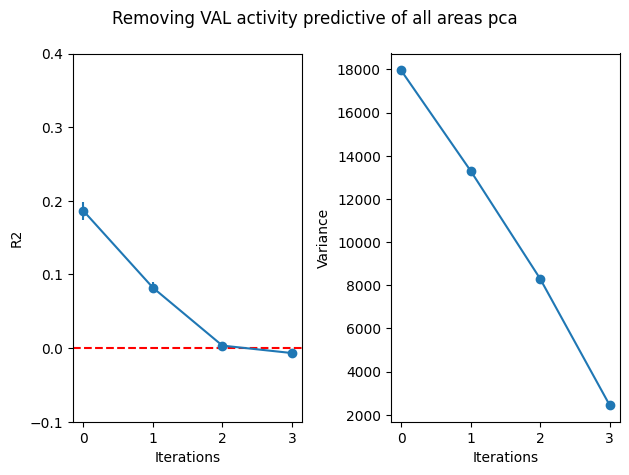

In [42]:
fig, ax = plt.subplots(1, 2)
plt.suptitle('Removing VAL activity predictive of all areas pca')
ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()


In [46]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_ = pyal.restrict_to_interval(df_tr_sliced, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td__ = perturb_td_.sample(frac=1, random_state=42).reset_index(drop=True)

dim_val = np.stack(perturb_td__.VAL_rates_pca.values).shape[-1]
perturb_td__["val_null_all_areas"] = perturb_td__["VAL_rates_pca"]
rank = 50 
for i in range(2):
    emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'val_null_all_areas',
                            f'all_non_val_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=True
                        )
    perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'val_null_all_areas', 'val_null_all_areas')
    dim_val = np.stack(perturb_td__.val_null_all_areas.values).shape[-1]
    print(dim_val)

emb = subspaces.compute_embedding(
                            perturb_td__,
                            f'VAL_rates_pca',
                            f'all_non_val_rates_pca',
                            (0, 500),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
perturb_td__ = subspaces.project_signal(perturb_td__, emb, 'VAL_rates_pca', 'val_potent_all_areas')

118
68


In [51]:
perturb_td_resorted = perturb_td__.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
perturb_td_resorted = perturb_td_resorted.iloc[idx]
perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))



{'all_areas_potent': 4969.859227861303, 'all_areas_null': 8510.88011753312}

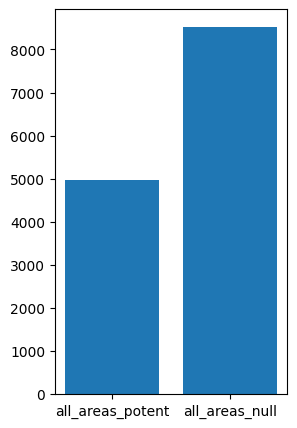

In [52]:
vars_ = {
    'all_areas_potent': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted.val_potent_all_areas.values),
        np.eye(50)
        ),
    'all_areas_null': subspaces.variance_in_subspace(
        np.concatenate(perturb_td_resorted.val_null_all_areas.values),
        np.eye(dim_val)
        ),
}
fig, ax = plt.subplots(figsize=(3, 5))
ax.bar(vars_.keys(), vars_.values())
vars_

In [53]:
res = {}
arr_potent = np.stack(perturb_td_resorted[f'val_potent_all_areas'])[:, 200:, :]
arr_val = np.stack(perturb_td_resorted[f'VAL_rates_pca'])[:, 200:, :]
arr_null = np.stack(perturb_td_resorted[f'val_null_all_areas'])[:, 200:, :]

n_trials, _, _ = arr_potent.shape

res['val_full_model'] = cross_val_score(
    Ridge(100),
    arr_val.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['potent'] = cross_val_score(
    Ridge(100),
    arr_potent.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

res['null'] = cross_val_score(
    Ridge(100),
    arr_null.reshape(n_trials, -1),
    perturb_td_resorted.disturb_sum.values,
    cv=5,
    scoring=vw_r2_scorer
)

Text(0, 0.5, 'R2')

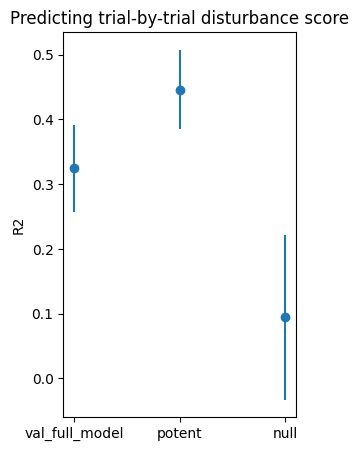

In [54]:
fig, ax = plt.subplots(figsize=(3, 5))
ax.set_title('Predicting trial-by-trial disturbance score')
ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
ax.set_ylabel('R2')

# Refactored version

In [7]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


In [163]:
def compute_potent_vs_null(
        td,
        origin_signal,
        target_signal,
        rank,
        target_variable = None,
        window_dec = None,
        scorer = make_scorer(r2_score, multioutput="variance_weighted"),
        window_emb = (0, 500),
        rel_start = -200,
        rel_end = 300,
        n_iter_explore = 3
):
    ###### Restric to interval and shuffle #########
    perturb_td = pyal.restrict_to_interval(td, 'idx_sol_on', rel_start = rel_start, rel_end = rel_end)
    perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=True)


    #####  Compute r2s and var after privatising  ############
    r2s = []
    vars_ = []
    dim_origin_signal = np.stack(perturb_td[origin_signal].values).shape[-1]

    r2 = cross_val_score(
            Ridge(100),
            np.concatenate(perturb_td[origin_signal].values),
            np.concatenate(perturb_td[target_signal].values)[:, :rank],
            cv=5,
            scoring=scorer
        )
    r2s.append(r2)
    vars_.append(subspaces.variance_in_subspace(
        np.concatenate(perturb_td[origin_signal].values),
        np.eye(dim_origin_signal)
    ))

    for i in range(n_iter_explore):
        emb = subspaces.compute_embedding(
                                perturb_td,
                                origin_signal,
                                target_signal,
                                (window_emb[0], window_emb[-1]),
                                subspaces.ReducedRankCommSubspace(rank=rank),
                                null=True
                            )
        perturb_td = subspaces.project_signal(perturb_td, emb, origin_signal, origin_signal)
        dim_origin_signal = np.stack(perturb_td[origin_signal].values).shape[-1]
        r2 = cross_val_score(
            Ridge(100),
            np.concatenate(perturb_td[origin_signal].values),
            np.concatenate(perturb_td[target_signal].values)[:, :rank],
            cv=5,
            scoring=scorer
        )
        r2s.append(r2)
        vars_.append(subspaces.variance_in_subspace(
            np.concatenate(perturb_td[origin_signal].values),
            np.eye(dim_origin_signal)
        ))
    r2s = np.array(r2s)


    ###### Plot these scores ######
    fig, ax = plt.subplots(1, 2)
    plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
    ax[0].errorbar(range(4), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
    ax[0].set_ylim(-0.1, 0.4)
    ax[0].axhline(0, color= 'r', linestyle='dashed')
    ax[0].set_xlabel('Iterations')
    ax[0].set_ylabel('R2')
    ax[1].errorbar(range(4), np.array(vars_), fmt='o-')
    ax[1].set_xlabel('Iterations')
    ax[1].set_ylabel('Variance')

    # ax[1].set_ylim(-0.1, 0.4)
    plt.tight_layout()
    plt.show()

def privatise_and_decode(
    td,
    n_iter,
    origin_signal,
    target_signal,
    rank,
    idx_disturb_to_keep,
    window_emb = (0, 500),
    scorer = make_scorer(r2_score, multioutput="variance_weighted"),
    rel_start = -200,
    rel_end = 300,
    target_var = 'disturb_sum',
    model = Ridge(100),
    window_dec = (200, 300),
    cv=5
):
    td[f'{origin_signal}_null_{target_signal}'] = td[origin_signal]
    td[f'{origin_signal}_potent_{target_signal}'] = td[origin_signal]

    ###### Restric to interval and shuffle #########
    perturb_td = pyal.restrict_to_interval(td, 'idx_sol_on', rel_start = rel_start, rel_end = rel_end)
    perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=True)

    ##### compute private subspace ######
    for i in range(n_iter):
        emb = subspaces.compute_embedding(
                                perturb_td,
                                f'{origin_signal}_null_{target_signal}',
                                target_signal,
                                (window_emb[0], window_emb[-1]),
                                subspaces.ReducedRankCommSubspace(rank=rank),
                                null=True
                            )
        perturb_td = subspaces.project_signal(perturb_td, emb, 
                                              f'{origin_signal}_null_{target_signal}',
                                              f'{origin_signal}_null_{target_signal}')
        
        dim_null = np.stack(perturb_td[f'{origin_signal}_null_{target_signal}'].values).shape[-1]
    
    ##### compute public subspace ######
    emb = subspaces.compute_embedding(
                            perturb_td,
                            f'{origin_signal}_potent_{target_signal}',
                            target_signal,
                            (window_emb[0], window_emb[-1]),
                            subspaces.ReducedRankCommSubspace(rank=rank),
                            null=False
                        )
    perturb_td = subspaces.project_signal(perturb_td, emb, f'{origin_signal}_potent_{target_signal}', 
                                          f'{origin_signal}_potent_{target_signal}')
    
    ##### Re-sort Compute variances #####
    perturb_td_resorted = perturb_td.sort_values(by="trial_id", ascending=True).reset_index(drop=True)
    perturb_td_resorted = perturb_td_resorted.iloc[idx_disturb_to_keep]
    perturb_td_resorted['disturb_sum'] = perturb_td_resorted['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

    vars_sorted = {
        f'{origin_signal}_potent_{target_signal}': subspaces.variance_in_subspace(
            np.concatenate(perturb_td_resorted[f'{origin_signal}_potent_{target_signal}'].values),
            np.eye(rank)
            ),
        f'{origin_signal}_null_{target_signal}': subspaces.variance_in_subspace(
            np.concatenate(perturb_td_resorted[f'{origin_signal}_null_{target_signal}'].values),
            np.eye(dim_null)
            ),
    }
    
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(vars_sorted.keys(), vars_sorted.values())
    ax.set_title(f'Variance in {origin_signal} subspaces')
    plt.show()


    ########### Decode #####################
    res = {}
    arr_full = np.stack(perturb_td_resorted[origin_signal])[:, window_dec[0]:window_dec[1], :]
    arr_potent = np.stack(perturb_td_resorted[f'{origin_signal}_potent_{target_signal}'])[:, window_dec[0]:window_dec[1], :]
    arr_null = np.stack(perturb_td_resorted[f'{origin_signal}_null_{target_signal}'])[:, window_dec[0]:window_dec[1], :]

    n_trials, _, _ = arr_potent.shape


    res['full_model'] = cross_val_score(
        model,
        arr_full.reshape(n_trials, -1),
        perturb_td_resorted[target_var].values.tolist(),
        cv=cv,
        scoring=scorer
    )

    res['potent'] = cross_val_score(
        model,
        arr_potent.reshape(n_trials, -1),
        perturb_td_resorted[target_var].values.tolist(),
        cv=cv,
        scoring=scorer
    )

    res['null'] = cross_val_score(
        model,
        arr_null.reshape(n_trials, -1),
        perturb_td_resorted[target_var].values.tolist(),
        cv=cv,
        scoring=scorer
    )

    
    # X_filt, y_filt, chance = drop_least_populated_class(arr_full.reshape(n_trials, -1), perturb_td_resorted[target_var].values.tolist())
    # X_filt, y_filt, chance = drop_least_populated_class(X_filt, y_filt)

    # res['full_model'] = cross_val_score(
    #     model,
    #     X_filt,
    #     y_filt,
    #     cv=cv,
    #     scoring=scorer
    # )

    # X_filt, y_filt, chance = drop_least_populated_class(arr_potent.reshape(n_trials, -1), perturb_td_resorted[target_var].values.tolist())
    # X_filt, y_filt, chance = drop_least_populated_class(X_filt, y_filt)

    # res['potent'] = cross_val_score(
    #     model,
    #     X_filt,
    #     y_filt,
    #     cv=cv,
    #     scoring=scorer
    # )

    # X_filt, y_filt, chance = drop_least_populated_class(arr_null.reshape(n_trials, -1), perturb_td_resorted[target_var].values.tolist())
    # X_filt, y_filt, chance = drop_least_populated_class(X_filt, y_filt)

    # res['null'] = cross_val_score(
    #     model,
    #     X_filt,
    #     y_filt,
    #     cv=cv,
    #     scoring=scorer
    # )

    fig, ax = plt.subplots(figsize=(3, 5))
    ax.set_title(f'Predicting trial-by-trial {target_var}')
    ax.errorbar(res.keys(), [val.mean() for val in res.values()], yerr=[val.std() for val in res.values()], fmt='o')
    ax.set_ylabel('R2')
    # ax.axhline(chance, color='r', linestyle='dashed')
    # ax.set_ylim(-0.02, 0.55)
    plt.show()


def drop_least_populated_class(X, y, *, return_mask=False):
    """
    Drop all samples belonging to the least-populated class in y.

    Parameters
    ----------
    X : array-like, shape (n_samples, ...)  (e.g., your arr_full.reshape(n_trials, -1))
    y : array-like, shape (n_samples,)
    return_mask : bool
        If True, also return the boolean mask used to keep samples.

    Returns
    -------
    X_kept, y_kept  (and mask if return_mask=True)
    """
    X = np.asarray(X)
    y = np.asarray(y)

    if X.shape[0] != y.shape[0]:
        raise ValueError(f"X and y must have same number of samples. Got {X.shape[0]} and {y.shape[0]}.")

    classes, counts = np.unique(y, return_counts=True)
    

    if classes.size < 2:
        # Nothing sensible to drop if only one class
        mask = np.ones_like(y, dtype=bool)
        return (X, y, mask) if return_mask else (X, y)

    least_class = classes[np.argmin(counts)]
    print(f'Min class: {least_class}, counts: {np.min(counts)}')
    mask = (y != least_class)

    X_kept = X[mask]
    y_kept = y[mask]

    return (X_kept, y_kept, mask, 1/len(classes)) if return_mask else (X_kept, y_kept, 1/len(classes))


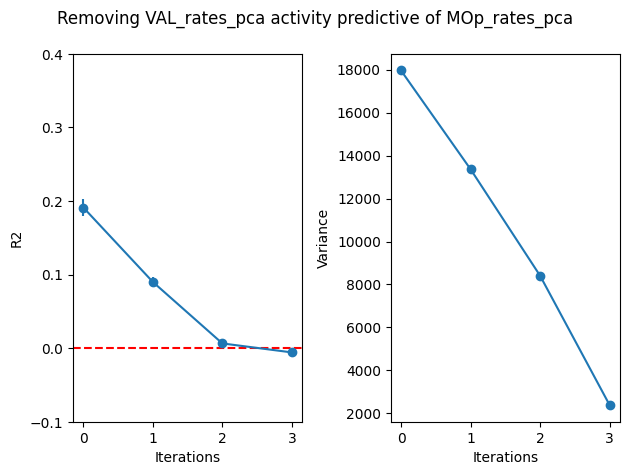

In [15]:
compute_potent_vs_null(
    df_tr_sliced,
    origin_signal='VAL_rates_pca',
    target_signal='MOp_rates_pca',
    rank=50
    )

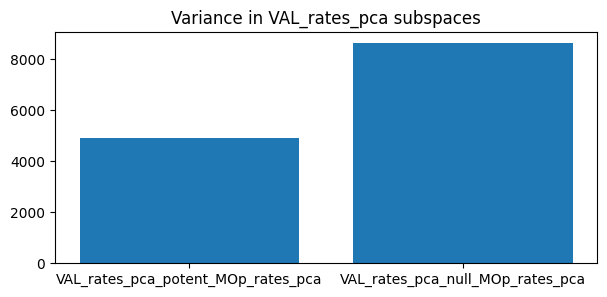

Min class: 0, counts: 2
Min class: 4, counts: 2
Min class: 0, counts: 2
Min class: 4, counts: 2
Min class: 0, counts: 2
Min class: 4, counts: 2


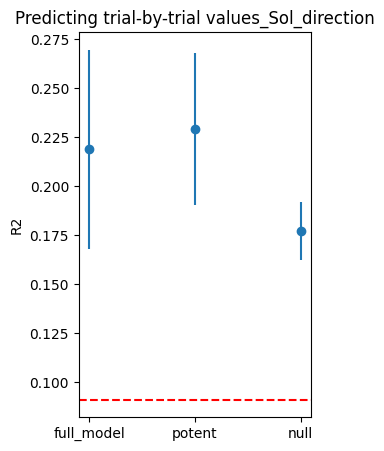

In [126]:
privatise_and_decode(
    df_tr_sliced,
    n_iter = 2,
    origin_signal='VAL_rates_pca',
    target_signal='MOp_rates_pca',
    rank=50,
    idx_disturb_to_keep = sorted(dstrb_idx[:100]),
    target_var = 'values_Sol_direction',
    model = GaussianNB(),
    window_dec=(200, 500),
    scorer='accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=False)
    )

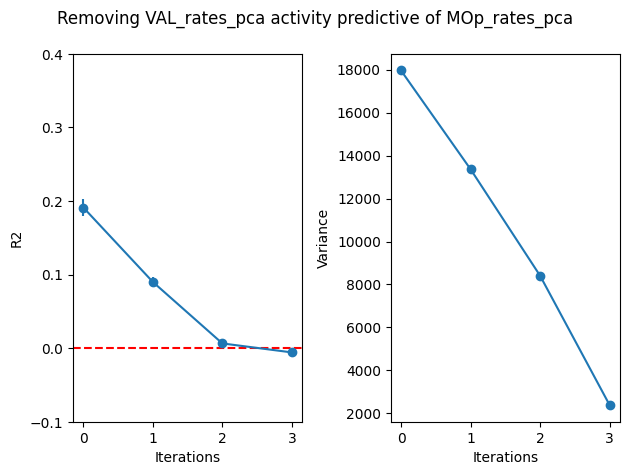

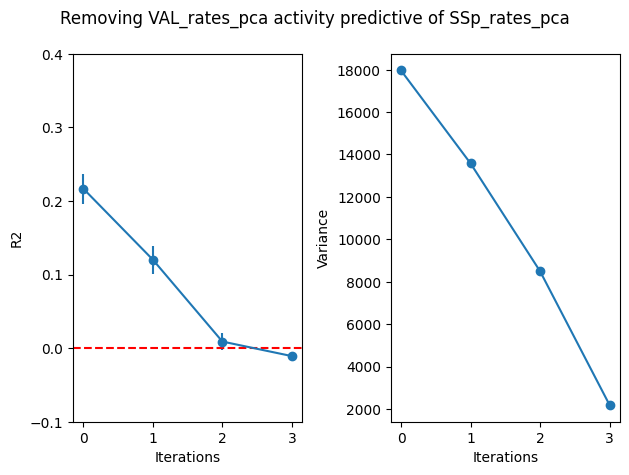

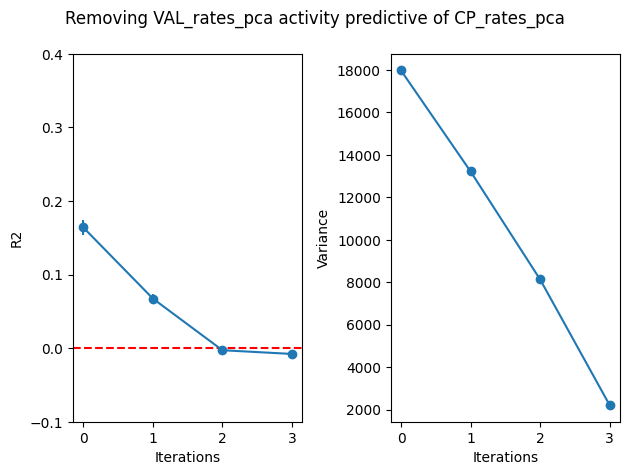

In [127]:
for area in ['MOp', 'SSp', 'CP']:
    compute_potent_vs_null(
        df_tr_sliced,
        origin_signal='VAL_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=50
    )

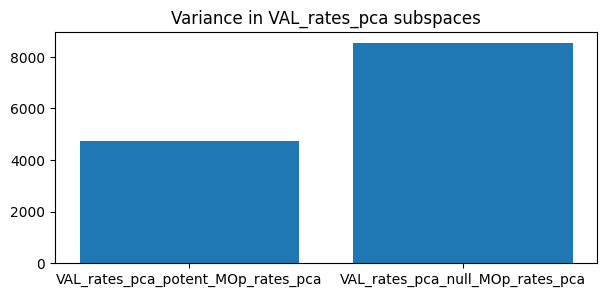

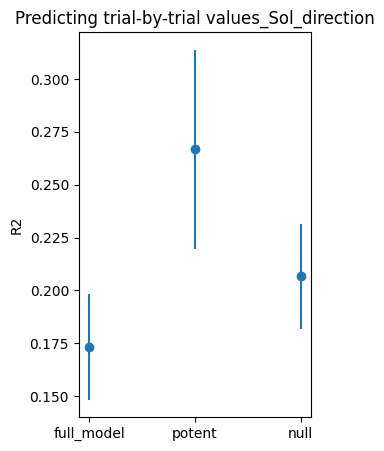

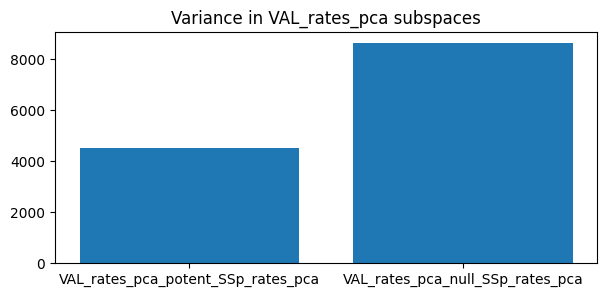

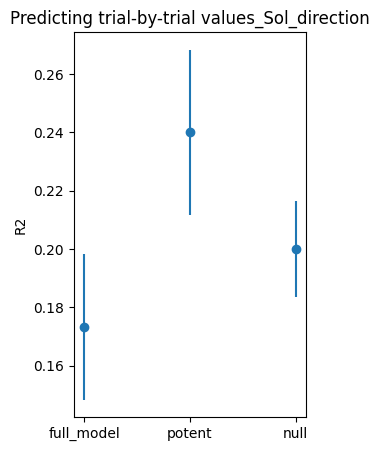

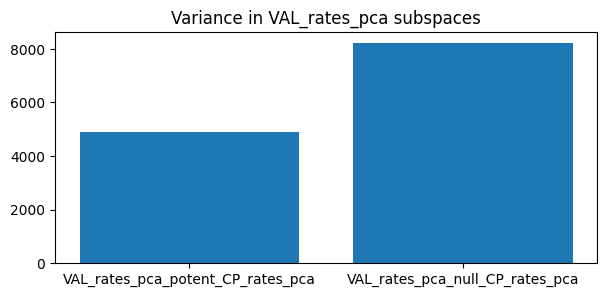

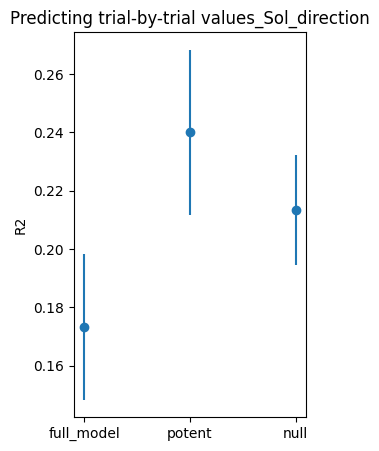

In [165]:
for area in ['MOp', 'SSp', 'CP']:
    privatise_and_decode(
        df_tr_sliced,
        n_iter = 2,
        origin_signal='VAL_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=50,
        idx_disturb_to_keep = sorted(dstrb_idx[:150]),
        target_var = 'values_Sol_direction',
        model = GaussianNB(),
        window_emb=(0, 500),
        window_dec=(200, 500),
        scorer='accuracy',
        cv=StratifiedKFold(n_splits=3, shuffle=False)
    )

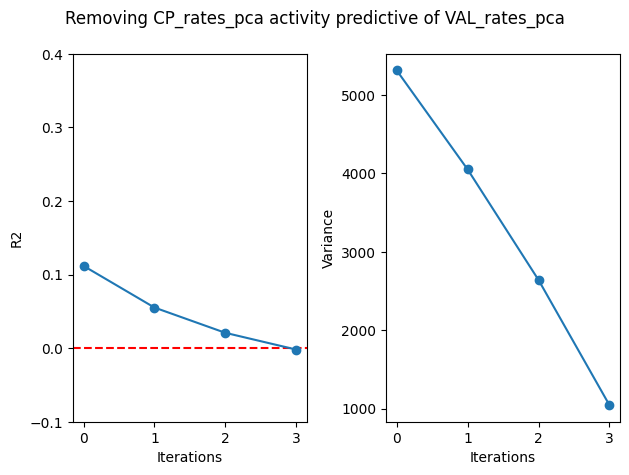

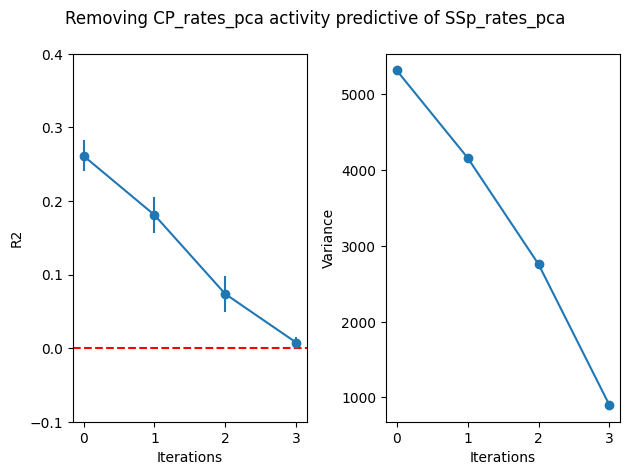

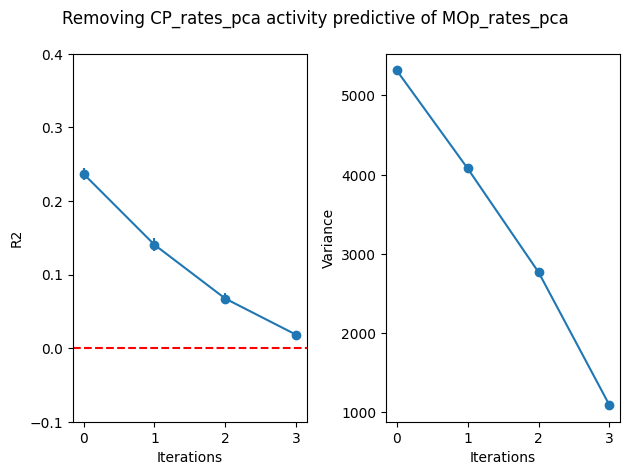

In [151]:
for area in ['VAL', 'SSp', 'MOp']:
    compute_potent_vs_null(
        df_tr_sliced,
        origin_signal='CP_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=50
    )

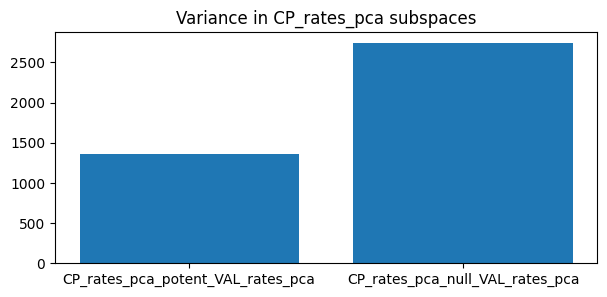

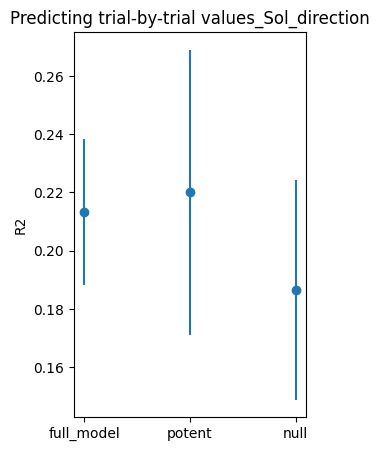

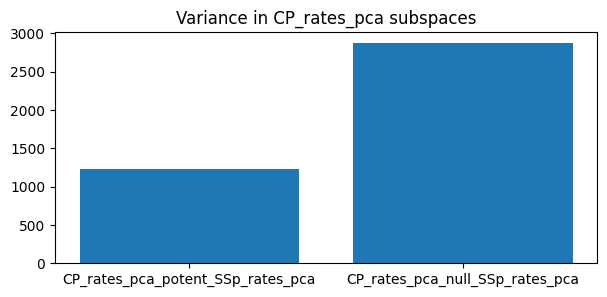

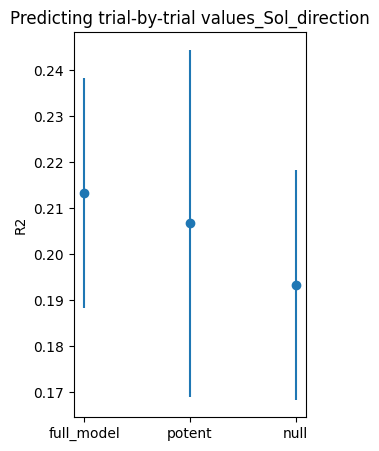

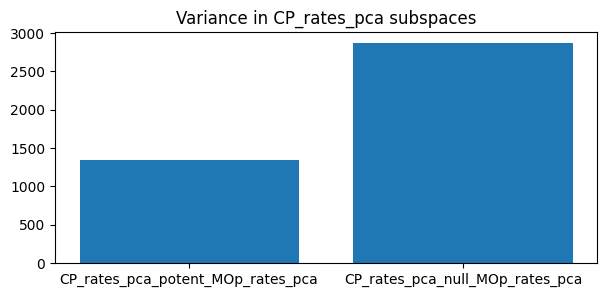

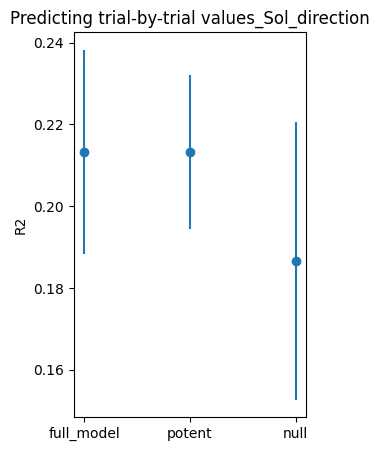

In [166]:
for area in ['VAL', 'SSp', 'MOp']:
    privatise_and_decode(
        df_tr_sliced,
        n_iter = 2,
        origin_signal='CP_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=50,
        idx_disturb_to_keep = sorted(dstrb_idx[:150]),
        target_var = 'values_Sol_direction',
        model = GaussianNB(),
        window_dec=(200, 500),
        scorer='accuracy',
        cv=StratifiedKFold(n_splits=3, shuffle=False)
    )

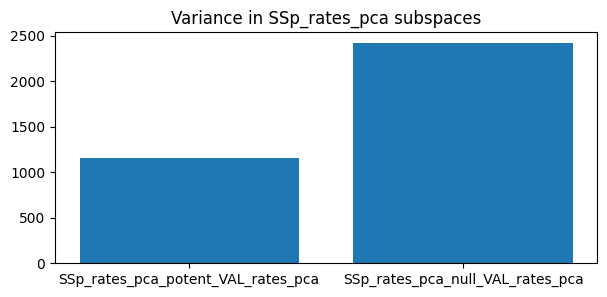

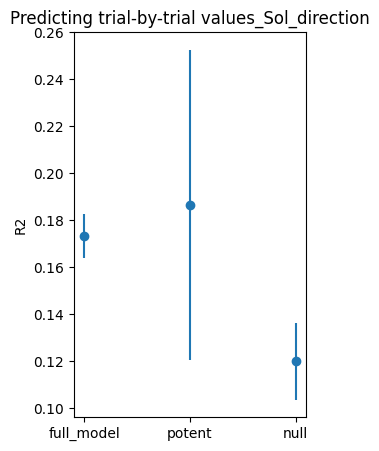

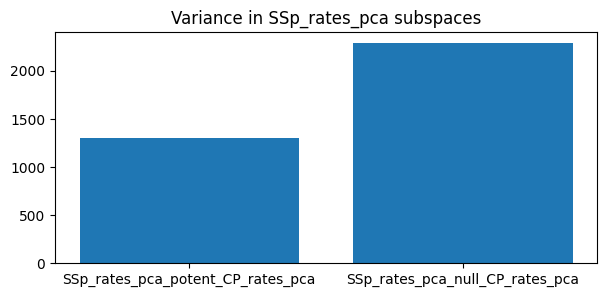

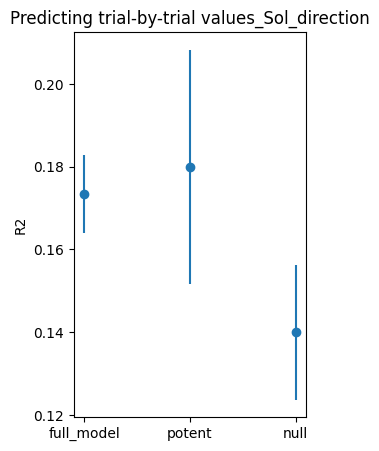

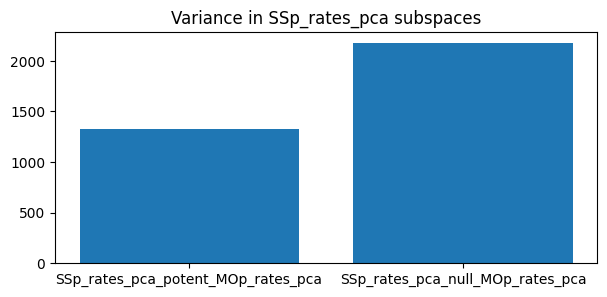

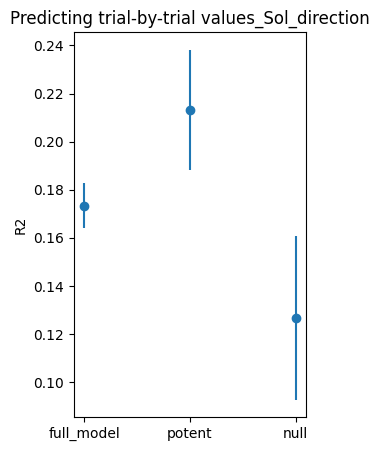

In [168]:
for area in ['VAL', 'CP', 'MOp']:
    privatise_and_decode(
        df_tr_sliced,
        n_iter = 2,
        origin_signal='SSp_rates_pca',
        target_signal=f'{area}_rates_pca',
        rank=20,
        idx_disturb_to_keep = sorted(dstrb_idx[:150]),
        target_var = 'values_Sol_direction',
        model = GaussianNB(),
        window_dec=(200, 500),
        scorer='accuracy',
        cv=StratifiedKFold(n_splits=3, shuffle=False)
    )

# Refactored version v2

In [13]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [14]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [15]:
df__ = dt.add_pca_df(df_)

In [16]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [297]:
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

In [ ]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


### Privatise signals

In [298]:
origin_signal = 'VAL_rates_pca'
target_signal='MOp_rates_pca'
n_iter = 2
perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
    perturb_td_shuff,
    n_iter=n_iter,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=50,
    diagnostics=True
    )

perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
    perturb_td_shuff,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=50,
    )

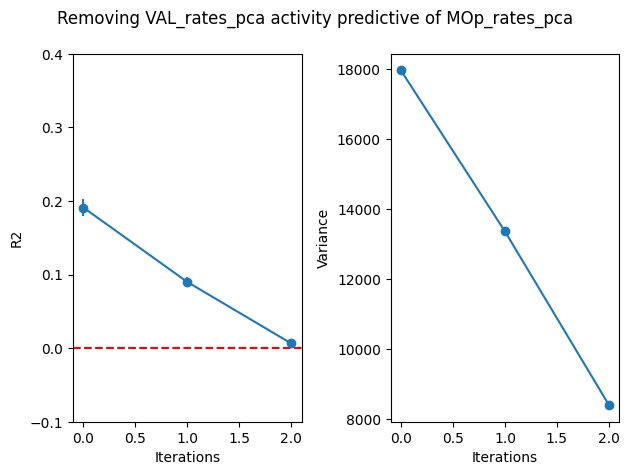

In [103]:
fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
ax[0].errorbar(range(n_iter+1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(n_iter+1), np.array(vars), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()
plt.show()

In [18]:

def majority_class_chance_levels_from_counts(counts):
    """
    counts_dict: {class_label: count, ...}
    Returns:
      N, majority_chance, prior_weighted_chance, uniform_chance
    """
    N = counts.sum()

    majority_chance = counts.max() / N

    return majority_chance


def drop_classes_below_count(X, y, *, min_count=1, return_mask=False):
    """
    Drop all samples belonging to classes in y with count < min_count.

    Parameters
    ----------
    X : array-like, shape (n_samples, ...)
    y : array-like, shape (n_samples,)
    min_count : int
        Classes with fewer than min_count samples are dropped.
    return_mask : bool
        If True, also return the boolean mask used to keep samples.

    Returns
    -------
    X_kept, y_kept, weight  (and mask if return_mask=True)
    """
    X = np.asarray(X)
    y = np.asarray(y)

    if X.shape[0] != y.shape[0]:
        raise ValueError(f"X and y must have same number of samples. Got {X.shape[0]} and {y.shape[0]}.")

    classes, counts = np.unique(y, return_counts=True)



    if classes.size < 2:
        mask = np.ones_like(y, dtype=bool)
        chance = majority_class_chance_levels_from_counts(counts)
        return (X, y, mask, chance) if return_mask else (X, y, chance)

    drop_classes = classes[counts < min_count]

    if drop_classes.size == 0:
        # Nothing to drop
        mask = np.ones_like(y, dtype=bool)
        chance = majority_class_chance_levels_from_counts(counts)
        return (X, y, mask, chance) if return_mask else (X, y, chance)

    print(f"Dropping classes with count < {min_count}: {drop_classes.tolist()}")
    print(f"Counts: {dict(zip(classes.tolist(), counts.tolist()))}")


    mask = ~np.isin(y, drop_classes)

    X_kept = X[mask]
    y_kept = y[mask]
    classes, counts = np.unique(y_kept, return_counts=True)
    chance = majority_class_chance_levels_from_counts(counts)

    return (X_kept, y_kept, mask, chance) if return_mask else (X_kept, y_kept, chance)


In [321]:
idx = sorted(dstrb_idx[:100])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=100,
    step_bin=2
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=100,
    step_bin=2
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=100,
    step_bin=2
)

Dropping classes with count < 3: [0, 4]
Counts: {0: 2, 1: 17, 2: 16, 3: 14, 4: 2, 5: 14, 6: 10, 7: 3, 8: 7, 9: 4, 10: 7, 11: 4}


100%|██████████| 201/201 [00:02<00:00, 78.23it/s]


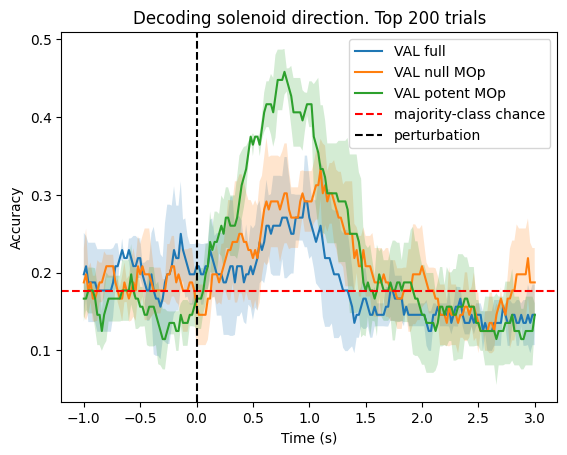

In [322]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label='VAL full')
vizutils.shaded_errorbar(ax, times-2, scores_null, label='VAL null MOp')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='VAL potent MOp')

ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Decoding solenoid direction. Top 200 trials')

ax.legend()

In [317]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

idx = sorted(dstrb_idx[:100])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
y = perturb_td_shuff_filt.disturb_sum.values

# X_filt, y_filt, mask, _ = drop_classes_below_count(X, y, min_count=3, return_mask=True)



n_trials, _, _ = X.shape
scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)

 21%|██        | 42/201 [00:00<00:03, 41.39it/s]

100%|██████████| 201/201 [00:02<00:00, 71.30it/s]


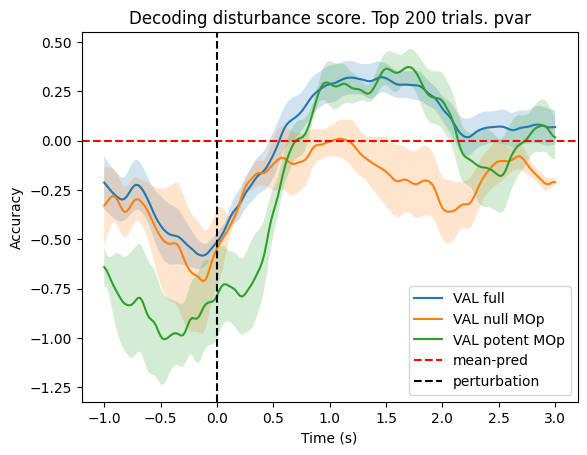

In [318]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label='VAL full')
vizutils.shaded_errorbar(ax, times-2, scores_null, label='VAL null MOp')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='VAL potent MOp')

ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Decoding disturbance score. Top 200 trials. pvar')
# ax.set_ylim(-0.2, 0.5)

ax.legend()

In [313]:
idx = sorted(dstrb_idx[:200])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_duration.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=4),
    window_length_bin=100,
    step_bin=2
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=4),
    window_length_bin=100,
    step_bin=2
)

scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=4),
    window_length_bin=100,
    step_bin=2
)

100%|██████████| 201/201 [00:03<00:00, 51.46it/s]


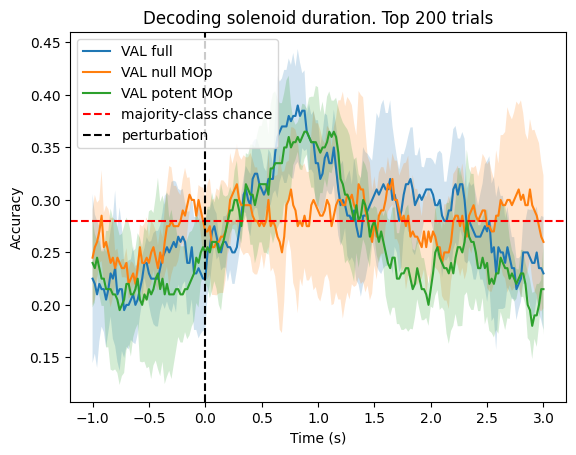

In [314]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label='VAL full')
vizutils.shaded_errorbar(ax, times-2, scores_null, label='VAL null MOp')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='VAL potent MOp')

ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Decoding solenoid duration. Top 200 trials')

ax.legend()

## VAL to all areas

Remaining null space var 8494.837885893015. Potent var 4378.909835706939


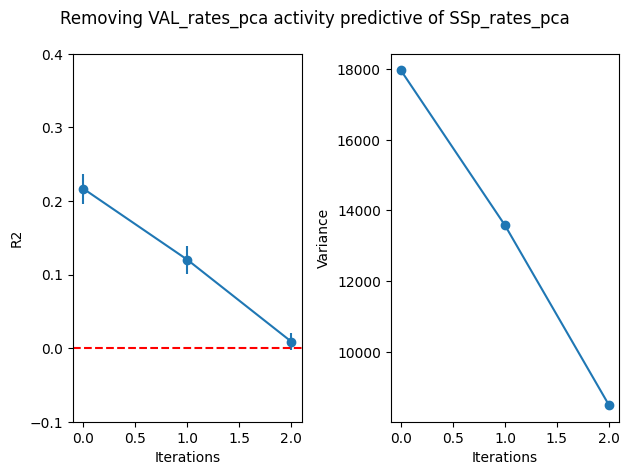

100%|██████████| 201/201 [00:02<00:00, 73.48it/s]


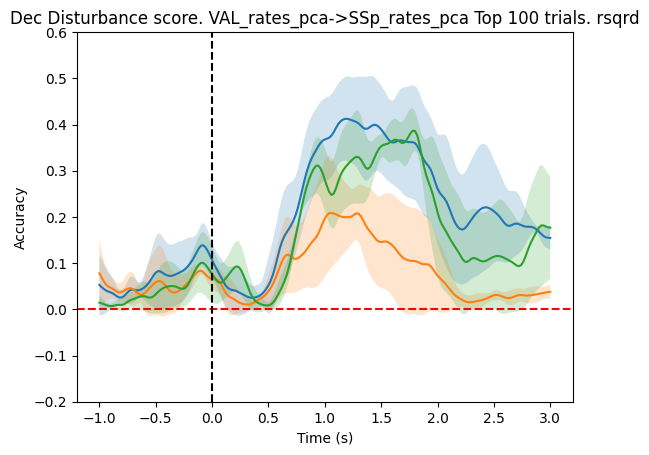

In [334]:
origin_signal = 'VAL_rates_pca'
target_signal='SSp_rates_pca'

idx_to_keep = 100
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

n_iter = 2
perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
    perturb_td_shuff,
    n_iter=n_iter,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=50,
    diagnostics=True
    )

perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
    perturb_td_shuff,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=50,
    )
print(f'Remaining null space var {vars[-1]}. Potent var {var}')
fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
ax[0].errorbar(range(n_iter+1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(n_iter+1), np.array(vars), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')

# ax[1].set_ylim(-0.1, 0.4)
plt.tight_layout()
plt.show()

# idx = sorted(dstrb_idx[:idx_to_keep])
# perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# # perturb_td_shuff_filt = (
# #     perturb_td_shuff_filt
# #     .sort_values(by='trial_id')
# #     .reset_index(drop=True)
# # )
# X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
# y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

# X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

# n_trials, _, _ = X.shape
# scores_null, times = decode.moving_window_decoding(
#     X_filt,
#     y_filt,
#     cv=StratifiedKFold(n_splits=3),
#     window_length_bin=100,
#     step_bin=2
# )
# scores_full, times = decode.moving_window_decoding(
#     np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
#     y_filt,
#     cv=StratifiedKFold(n_splits=3),
#     window_length_bin=100,
#     step_bin=2
# )
# scores_potent, times = decode.moving_window_decoding(
#     np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
#     y_filt,
#     cv=StratifiedKFold(n_splits=3),
#     window_length_bin=100,
#     step_bin=2
# )

# fig, ax = plt.subplots()
# vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
# vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'{origin_signal} null {target_signal}')
# vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'{origin_signal} potent {target_signal}')

# ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
# ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

# ax.set_xlabel('Time (s)')
# ax.set_ylabel('Accuracy')
# ax.set_title('Decoding solenoid direction. Top 200 trials')

# ax.legend()
# plt.show()

# vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
y = perturb_td_shuff_filt.disturb_sum.values



n_trials, _, _ = X.shape
scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    # scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    # scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    # scorer=vw_r2_scorer,
    window_length_bin=100,
    step_bin=2
)

fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'{origin_signal} null {target_signal}')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'{origin_signal} potent {target_signal}')

ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Dec Disturbance score. {origin_signal}->{target_signal} Top {idx_to_keep} trials. rsqrd')
ax.set_ylim(-0.2, 0.6)

# ax.legend()
plt.show()

# idx = sorted(dstrb_idx[:200])
# perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# # perturb_td_shuff_filt = (
# #     perturb_td_shuff_filt
# #     .sort_values(by='trial_id')
# #     .reset_index(drop=True)
# # )
# X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
# y = perturb_td_shuff_filt.values_Sol_duration.values.tolist()

# X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

# n_trials, _, _ = X.shape
# scores_null, times = decode.moving_window_decoding(
#     X_filt,
#     y_filt,
#     cv=StratifiedKFold(n_splits=4),
#     window_length_bin=100,
#     step_bin=2
# )
# scores_full, times = decode.moving_window_decoding(
#     np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
#     y_filt,
#     cv=StratifiedKFold(n_splits=4),
#     window_length_bin=100,
#     step_bin=2
# )

# scores_potent, times = decode.moving_window_decoding(
#     np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
#     y_filt,
#     cv=StratifiedKFold(n_splits=4),
#     window_length_bin=100,
#     step_bin=2
# )

# fig, ax = plt.subplots()
# vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
# vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'{origin_signal} null {target_signal}')
# vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'{origin_signal} potent {target_signal}')

# ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
# ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

# ax.set_xlabel('Time (s)')
# ax.set_ylabel('Accuracy')
# ax.set_title('Decoding solenoid duration. Top 200 trials')

# ax.legend()
# plt.show()

Remaining null space var 1758.6116047641904. Potent var 2271.3663266570807


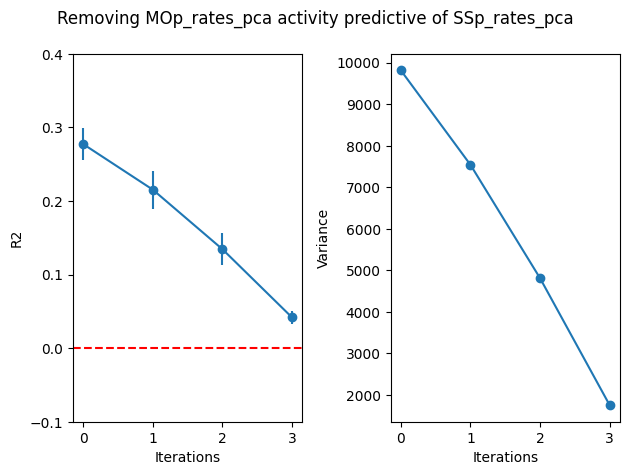

100%|██████████| 226/226 [00:02<00:00, 100.21it/s]


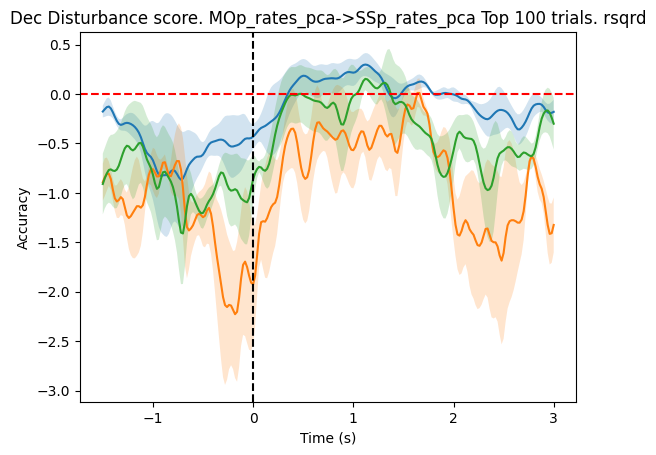

In [ ]:
origin_signal = 'MOp_rates_pca'
idx_to_keep = 100
rank = 50
window = 100
n_iter = 3

for area in ['SSp']:
    target_signal=f'{area}_rates_pca'

    df_design = df_tr.copy()

    perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
    perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

    perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
        perturb_td_shuff,
        n_iter=n_iter,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        diagnostics=True
        )

    perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
        perturb_td_shuff,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        )
    print(f'Remaining null space var {vars[-1]}. Potent var {var}')
    fig, ax = plt.subplots(1, 2)
    plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
    ax[0].errorbar(range(n_iter+1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
    ax[0].set_ylim(-0.1, 0.4)
    ax[0].axhline(0, color= 'r', linestyle='dashed')
    ax[0].set_xlabel('Iterations')
    ax[0].set_ylabel('R2')
    ax[1].errorbar(range(n_iter+1), np.array(vars), fmt='o-')
    ax[1].set_xlabel('Iterations')
    ax[1].set_ylabel('Variance')

    # ax[1].set_ylim(-0.1, 0.4)
    plt.tight_layout()
    plt.show()

    idx = sorted(dstrb_idx[:idx_to_keep])
    perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
    # perturb_td_shuff_filt = (
    #     perturb_td_shuff_filt
    #     .sort_values(by='trial_id')
    #     .reset_index(drop=True)
    # )
    y = perturb_td_shuff_filt.disturb_sum.values



    n_trials, _, _ = X.shape
    scores_null, times = decode.decoding_moving_window_no_time_concat(
        Ridge(1000),
        np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values),
        y,
        cv=KFold(n_splits=4),
        scorer=vw_r2_scorer,
        window_length_bin=window,
        step_bin=2
    )
    scores_full, times = decode.decoding_moving_window_no_time_concat(
        Ridge(1000),
        np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values),
        y,
        cv=KFold(n_splits=4),
        scorer=vw_r2_scorer,
        window_length_bin=window,
        step_bin=2
    )
    scores_potent, times = decode.decoding_moving_window_no_time_concat(
        Ridge(1000),
        np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values),
        y,
        cv=KFold(n_splits=4),
        scorer=vw_r2_scorer,
        window_length_bin=window,
        step_bin=2
    )

    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
    vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'{origin_signal} null {target_signal}')
    vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'{origin_signal} potent {target_signal}')

    ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
    ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Dec Disturbance score. {origin_signal}->{target_signal} Top {idx_to_keep} trials. rsqrd')
    # ax.set_ylim(-0.2, 0.6)

    # ax.legend()
    plt.show()

In [426]:
origin_signal = 'VAL_rates_pca'
idx_to_keep = 90
rank = 50
window = 100
n_iter = 2

tmp_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)

var_rank_spaces = subspaces.variance_in_dims(
    np.concatenate(tmp_td[origin_signal].values)[:, :rank],
    np.eye(rank)
)
print(f'Variance in rank {rank} space : {np.sum(var_rank_spaces)}')
for area in ['CP']:
    target_signal=f'{area}_rates_pca'

    df_design = df_tr.copy()

    perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
    perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

    perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
        perturb_td_shuff,
        n_iter=n_iter,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        diagnostics=True
        )

    perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
        perturb_td_shuff,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        )

    idx = sorted(dstrb_idx[:idx_to_keep])
    perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
    X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
    y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

    X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

    n_trials, _, _ = X.shape
    scores_null, times = decode.moving_window_decoding(
        X_filt,
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )
    scores_full, times = decode.moving_window_decoding(
        np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask, :, :],
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )
    scores_potent, times = decode.moving_window_decoding(
        np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )

    

Variance in rank 50 space : 10847.725932329895
Dropping classes with count < 3: [0, 4, 7]
Counts: {0: 2, 1: 16, 2: 14, 3: 12, 4: 2, 5: 13, 6: 10, 7: 2, 8: 7, 9: 4, 10: 5, 11: 3}


100%|██████████| 201/201 [00:02<00:00, 84.98it/s]


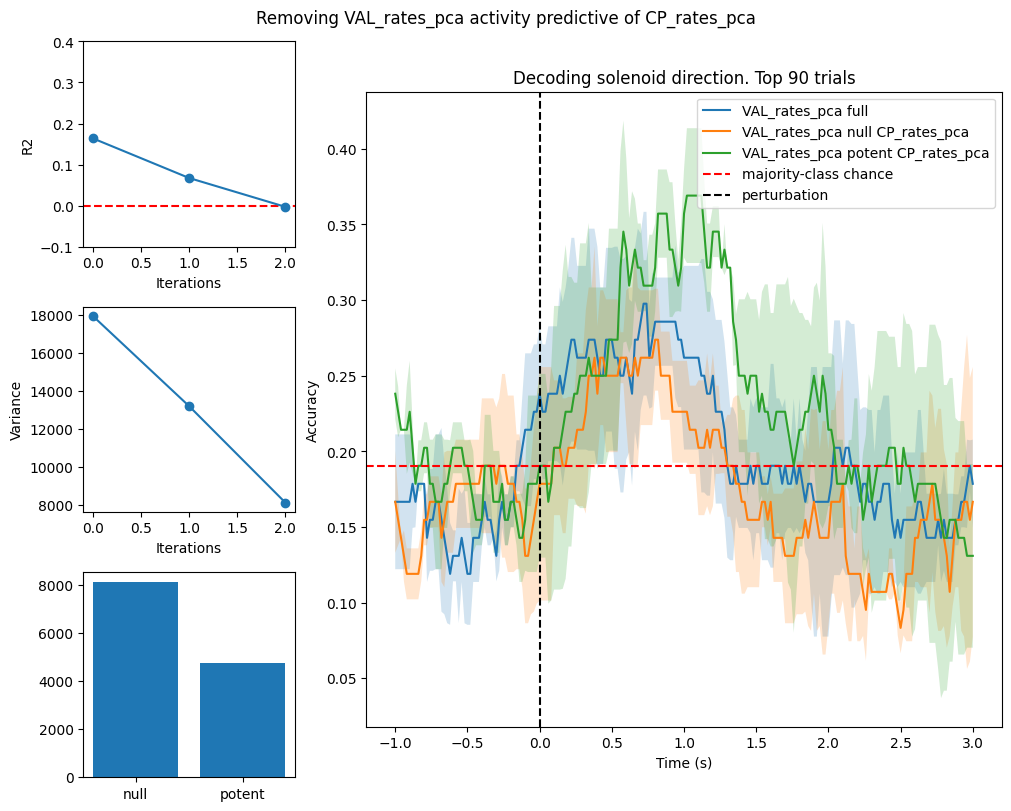

In [427]:
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[0.5, 1.5])

# Left column (3 rows)
ax_r2   = fig.add_subplot(gs[0, 0])
ax_var  = fig.add_subplot(gs[1, 0])
ax_left3 = fig.add_subplot(gs[2, 0])   # optional third left plot

# Right column (one big axis spanning all 3 rows)
ax_big = fig.add_subplot(gs[:, 1])

fig.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')

# --- Left top: R2 ---
ax_r2.errorbar(range(n_iter + 1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax_r2.set_ylim(-0.1, 0.4)
ax_r2.axhline(0, color='r', linestyle='dashed')
ax_r2.set_xlabel('Iterations')
ax_r2.set_ylabel('R2')

# --- Left middle: Variance ---
ax_var.plot(range(n_iter + 1), np.array(vars), 'o-')
ax_var.set_xlabel('Iterations')
ax_var.set_ylabel('Variance')

# --- Left bottom: (optional) ---
# If you don't want anything here, delete ax_left3 or turn it off:
ax_left3.bar(['null', 'potent'], [vars[-1], var])
# Or put something here (e.g., potent/null variance split, histogram, etc.)

# --- Right big: decoding timecourse ---
vizutils.shaded_errorbar(ax_big, times - 2, scores_full,   label=f'{origin_signal} full')
vizutils.shaded_errorbar(ax_big, times - 2, scores_null,   label=f'{origin_signal} null {target_signal}')
vizutils.shaded_errorbar(ax_big, times - 2, scores_potent, label=f'{origin_signal} potent {target_signal}')

ax_big.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax_big.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax_big.set_xlabel('Time (s)')
ax_big.set_ylabel('Accuracy')
ax_big.set_title(f'Decoding solenoid direction. Top {idx_to_keep} trials')
ax_big.legend()

# Make the right panel square-ish (box aspect = 1 makes it visually square)
ax_big.set_box_aspect(1)
# ax_big.set_xlim(-0.5, 1.5)

plt.show()

In [416]:
origin_signal = 'MOp_rates_pca'
idx_to_keep = 100
rank = 30
window = 30
n_iter = 4

tmp_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)

var_rank_spaces = subspaces.variance_in_dims(
    np.concatenate(tmp_td[origin_signal].values)[:, :rank],
    np.eye(rank)
)
print(f'Variance in rank {rank} space : {np.sum(var_rank_spaces)}')
for area in ['SSp']:
    target_signal=f'{area}_rates_pca'

    df_design = df_tr.copy()

    perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
    perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

    perturb_td_shuff, r2s, vars = subspaces.privatise_signal_td(
        perturb_td_shuff,
        n_iter=n_iter,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        diagnostics=True
        )

    perturb_td_shuff, r2, var = subspaces.publicise_signal_td(
        perturb_td_shuff,
        origin_signal=origin_signal,
        target_signal=target_signal,
        rank=rank,
        )

    idx = sorted(dstrb_idx[:idx_to_keep])
    perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
    X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
    y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

    X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

    n_trials, _, _ = X.shape
    scores_null, times = decode.moving_window_decoding(
        X_filt,
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )
    scores_full, times = decode.moving_window_decoding(
        np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask, :, :],
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )
    scores_potent, times = decode.moving_window_decoding(
        np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
        y_filt,
        cv=StratifiedKFold(n_splits=3),
        window_length_bin=window,
        step_bin=2
    )

    

Variance in rank 30 space : 6073.92137418684
Dropping classes with count < 3: [0, 4]
Counts: {0: 2, 1: 17, 2: 16, 3: 14, 4: 2, 5: 14, 6: 10, 7: 3, 8: 7, 9: 4, 10: 7, 11: 4}


100%|██████████| 236/236 [00:01<00:00, 157.16it/s]


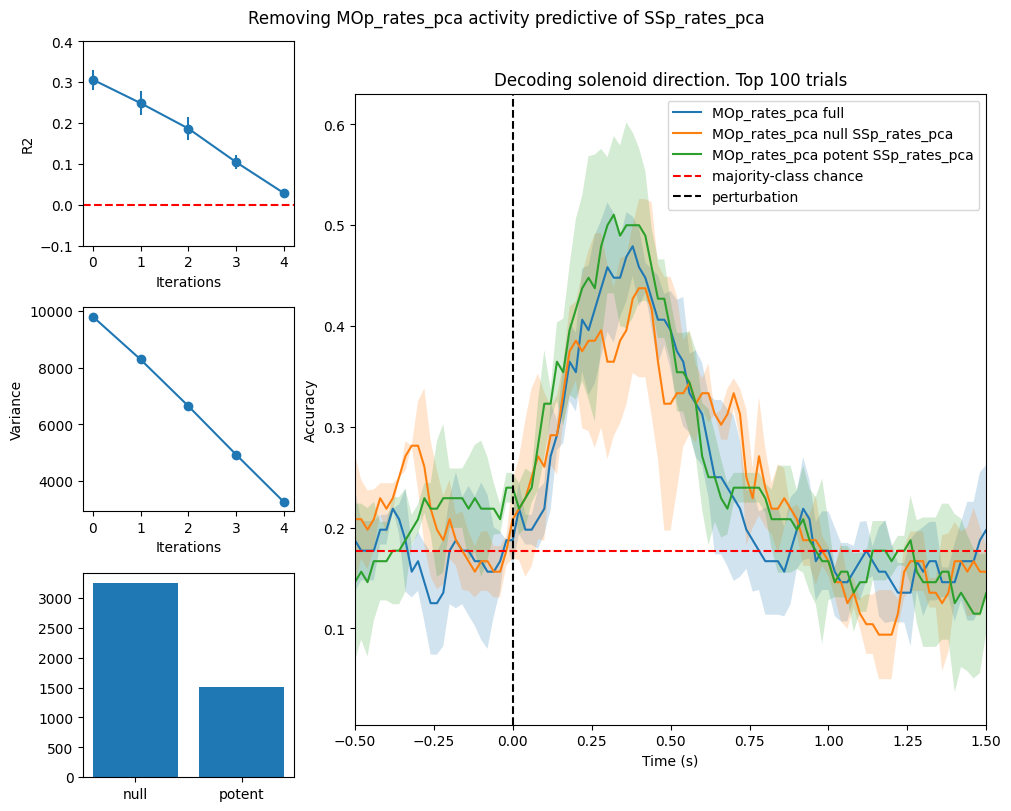

In [417]:
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[0.5, 1.5])

# Left column (3 rows)
ax_r2   = fig.add_subplot(gs[0, 0])
ax_var  = fig.add_subplot(gs[1, 0])
ax_left3 = fig.add_subplot(gs[2, 0])   # optional third left plot

# Right column (one big axis spanning all 3 rows)
ax_big = fig.add_subplot(gs[:, 1])

fig.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')

# --- Left top: R2 ---
ax_r2.errorbar(range(n_iter + 1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax_r2.set_ylim(-0.1, 0.4)
ax_r2.axhline(0, color='r', linestyle='dashed')
ax_r2.set_xlabel('Iterations')
ax_r2.set_ylabel('R2')

# --- Left middle: Variance ---
ax_var.plot(range(n_iter + 1), np.array(vars), 'o-')
ax_var.set_xlabel('Iterations')
ax_var.set_ylabel('Variance')

# --- Left bottom: (optional) ---
# If you don't want anything here, delete ax_left3 or turn it off:
ax_left3.bar(['null', 'potent'], [vars[-1], var])
# Or put something here (e.g., potent/null variance split, histogram, etc.)

# --- Right big: decoding timecourse ---
vizutils.shaded_errorbar(ax_big, times - 2, scores_full,   label=f'{origin_signal} full')
vizutils.shaded_errorbar(ax_big, times - 2, scores_null,   label=f'{origin_signal} null {target_signal}')
vizutils.shaded_errorbar(ax_big, times - 2, scores_potent, label=f'{origin_signal} potent {target_signal}')

ax_big.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax_big.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax_big.set_xlabel('Time (s)')
ax_big.set_ylabel('Accuracy')
ax_big.set_title(f'Decoding solenoid direction. Top {idx_to_keep} trials')
ax_big.legend()
ax_big.set_xlim(-0.5, 1.5)

# Make the right panel square-ish (box aspect = 1 makes it visually square)
ax_big.set_box_aspect(1)

plt.show()

## VAL private to m1 and cp?

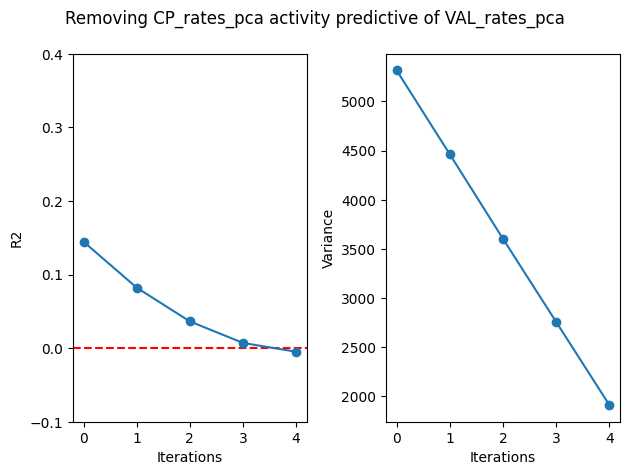

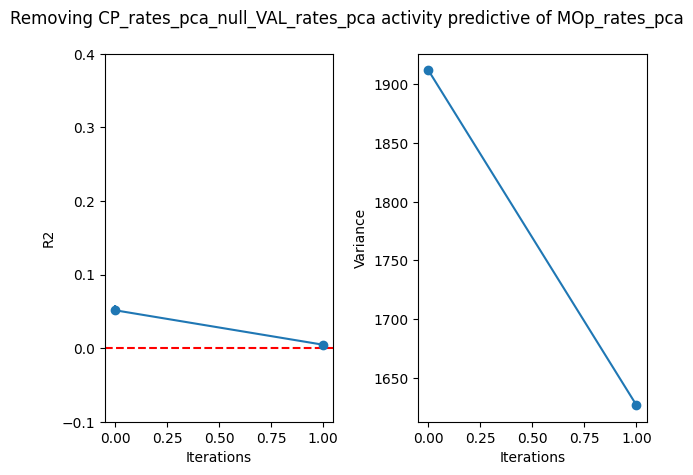

In [106]:
origin_signal = 'CP_rates_pca'
target_signal='VAL_rates_pca'

idx_to_keep = 100
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

perturb_td_shuff = subspaces.publicise_signal_td(
    perturb_td_shuff,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=30,
    )

n_iter = 4
perturb_td_shuff = subspaces.privatise_signal_td(
    perturb_td_shuff,
    n_iter=n_iter,
    origin_signal=origin_signal,
    target_signal=target_signal,
    rank=30,
    diagnostics=True
    )
n_iter = 1
perturb_td_shuff = subspaces.privatise_signal_td(
    perturb_td_shuff,
    n_iter=n_iter,
    origin_signal='CP_rates_pca_null_VAL_rates_pca',
    target_signal='MOp_rates_pca',
    rank=10,
    diagnostics=True
    )


In [648]:
vars_potent

2735.9480047017137

In [519]:
perturb_td_shuff.CP_rates_pca_potent_MOp_rates_pca.values[0].shape

(501, 30)

In [520]:
perturb_td_shuff.CP_rates_pca_null_MOp_rates_pca_null_VAL_rates_pca.values[0].shape

(501, 52)

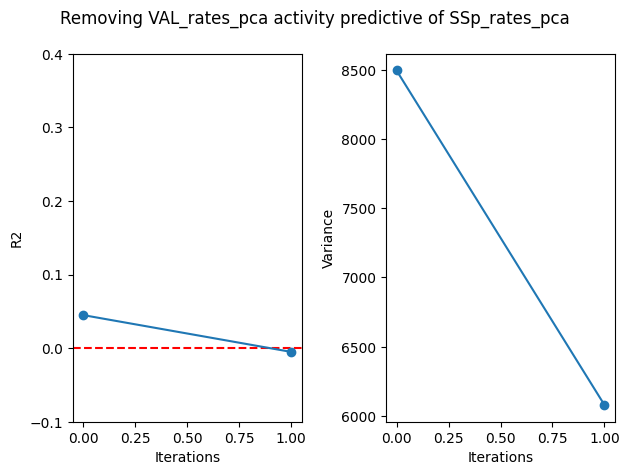

In [662]:
fig, ax = plt.subplots(1, 2)
plt.suptitle(f'Removing {origin_signal} activity predictive of {target_signal}')
ax[0].errorbar(range(n_iter+1), r2s.mean(-1), yerr=r2s.std(-1), fmt='o-')
ax[0].set_ylim(-0.1, 0.4)
ax[0].axhline(0, color= 'r', linestyle='dashed')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('R2')
ax[1].errorbar(range(n_iter+1), np.array(vars), fmt='o-')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Variance')
plt.tight_layout()

### Decode perturbation score

In [663]:
idx_to_keep = 100
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
y = np.concatenate(perturb_td_shuff_filt.disturb_score.values)
window = 100


scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=window,
    step_bin=2
)
scores_null_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}_null_MOp_rates_pca'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=window,
    step_bin=2
)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=window,
    step_bin=2
)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(1000),
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values),
    y,
    cv=KFold(n_splits=4),
    scorer=vw_r2_scorer,
    window_length_bin=window,
    step_bin=2
)



  0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 201/201 [00:03<00:00, 66.31it/s]


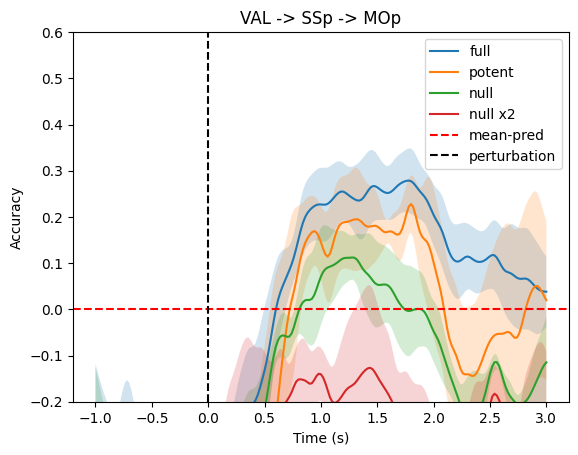

In [665]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'full')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'potent')

vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'null')
vizutils.shaded_errorbar(ax, times-2, scores_null_null, label=f'null x2')


ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'VAL -> SSp -> MOp')
ax.set_ylim(-0.2, 0.6)

ax.legend()
plt.show()

### Decode solenoid direction

In [107]:
idx_to_keep = 150
window = 100
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
X = np.stack(perturb_td_shuff_filt['CP_rates_pca_null_VAL_rates_pca'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=2
)
scores_null_null, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt['CP_rates_pca_null_VAL_rates_pca_null_MOp_rates_pca'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=2
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask, :, :],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=2
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=2
)

  0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 201/201 [00:02<00:00, 73.88it/s]


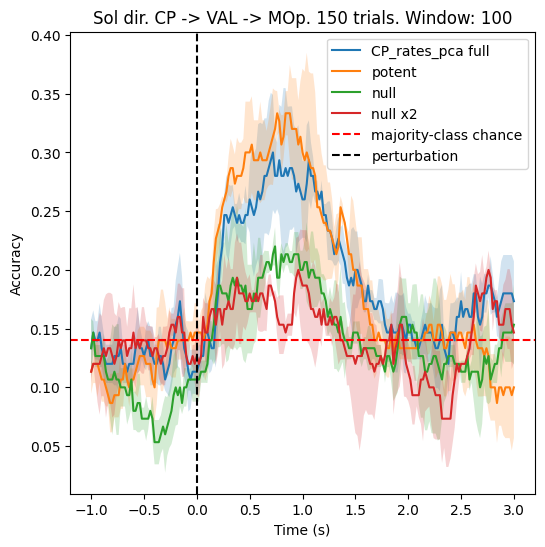

In [109]:
fig, ax = plt.subplots(figsize=(6, 6))
vizutils.shaded_errorbar(ax, times-2, scores_full, label=f'{origin_signal} full')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label=f'potent')

vizutils.shaded_errorbar(ax, times-2, scores_null, label=f'null')
vizutils.shaded_errorbar(ax, times-2, scores_null_null, label=f'null x2')


ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Sol dir. CP -> VAL -> MOp. {idx_to_keep} trials. Window: {window}')
# ax.set_xlim(-1, 2)
ax.legend()
# ax.set_ylim(0, 0.37)
plt.show()



# VAL var during perturb pre-perturb embedding

In [137]:
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

In [138]:
areas = ['MOp', 'CP', 'SSp', 'VAL']
window_emb = (0, 200)
vars = {}
rank = 30
for area_a in areas:
    vars[area_a] = {}
    for area_b in areas:
        if area_b == area_a:
            continue
        emb = subspaces.compute_embedding(
            perturb_td_shuff,
            f"{area_a}_rates_pca",
            f"{area_b}_rates_pca",
            (window_emb[0], window_emb[-1]),
            subspaces.ReducedRankCommSubspace(rank=rank),
        )
        perturb_td_shuff = subspaces.project_signal(
            perturb_td_shuff,
            emb,
            f'{area_a}_rates_pca',
            f'{area_a}_potent_{area_b}'
        )
        vars[area_a][area_b] = subspaces.variance_in_subspace_df(
            perturb_td_shuff,
            f'{area_a}_rates_pca',
            emb
        )


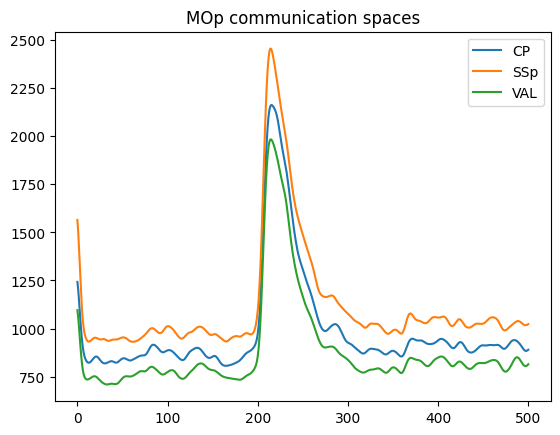

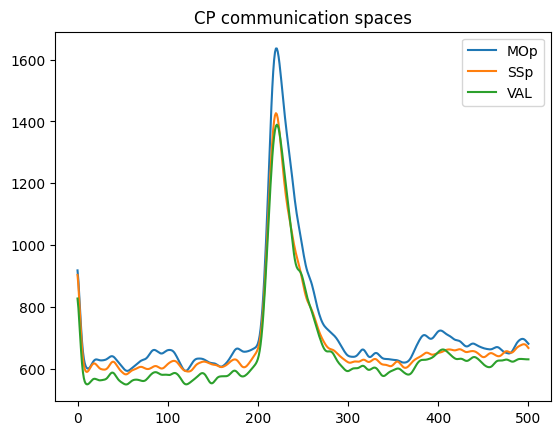

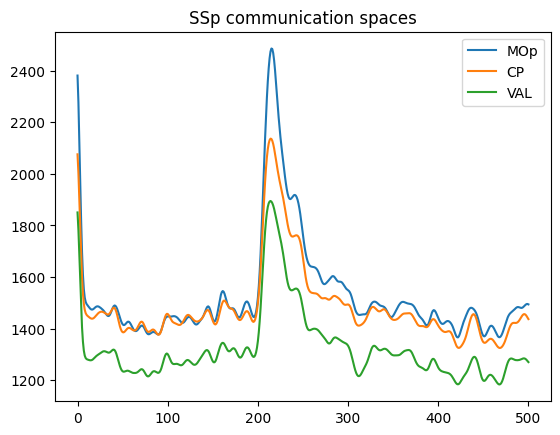

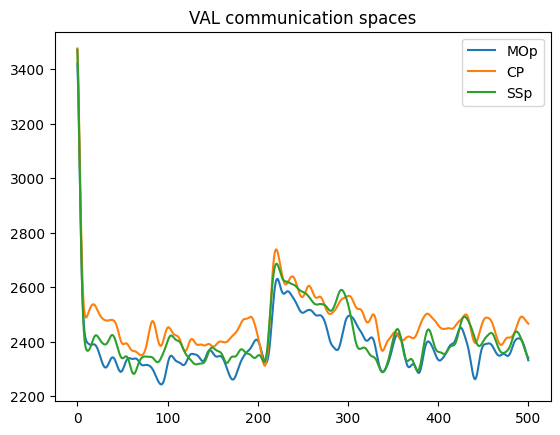

In [42]:
for area_a in vars.keys():
    fig, ax = plt.subplots()
    for area_b in vars[area_a].keys():
        ax.plot(vars[area_a][area_b], label=area_b)
        ax.set_title(f'{area_a} communication spaces')
        ax.legend()
    

In [12]:
perturb_td_shuff.columns

Index(['index', 'animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
 

In [26]:
df_design = df_tr.copy()

perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

Private var: 1840653.5631130878. Public var: 583616.5779498902
Private var: 4176316.7526402343. Public var: 2193113.286100284


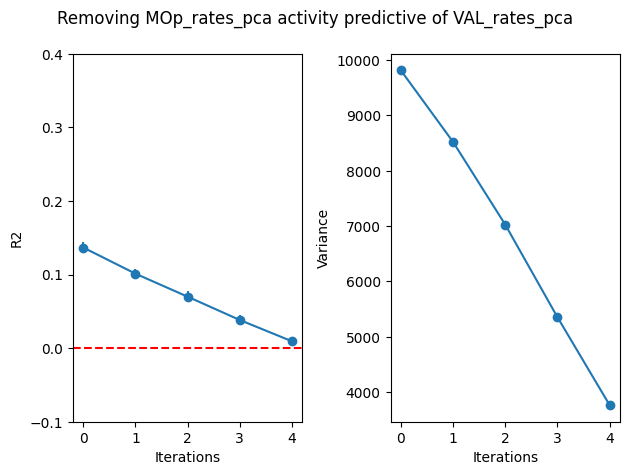

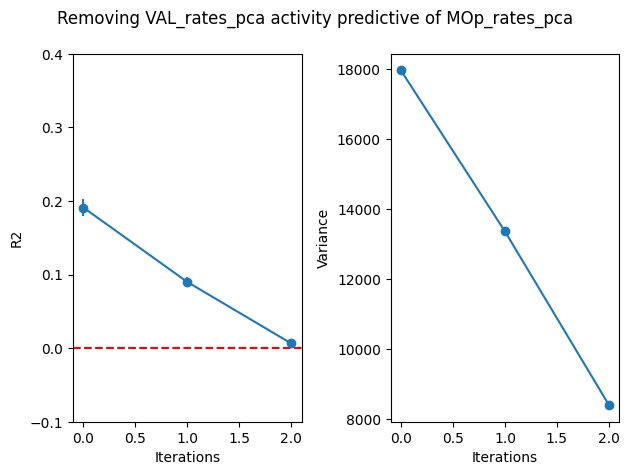

In [169]:
df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

areas = ['MOp', 'VAL', 'CP', 'SSp']
iter_dict = {
    'MOp': 4,
    'CP': 4,
    'VAL': 2,
    'SSp': 3
}
window_emb = (0, 500)
vars = {}
rank_dict = {
    'MOp': 30,
    'CP': 30,
    'VAL': 50,
    'SSp': 10
}
for area_a in areas[:2]:
    vars[area_a] = {}
    for area_b in areas[:2]:
        if area_b == area_a:
            # n_pcs = np.stack(
            #     perturb_td_shuff[f'{area_a}_rates_pca'].values[0]
            # ).shape[-1]
            # vars[area_a][area_b] = subspaces.variance_in_subspace_df(
            #     perturb_td_shuff,
            #     f'{area_a}_rates_pca',
            #     np.eye(n_pcs)
            # )
            continue
        perturb_td_shuff = subspaces.publicise_signal_td(
            perturb_td_shuff,
            origin_signal=f"{area_a}_rates_pca",
            target_signal=f"{area_b}_rates_pca",
            rank=rank_dict[area_a],
            window_emb=window_emb,
        )
        perturb_td_shuff = subspaces.privatise_signal_td(
            perturb_td_shuff,
            n_iter=iter_dict[area_a],
            origin_signal=f"{area_a}_rates_pca",
            target_signal=f"{area_b}_rates_pca",
            rank=rank_dict[area_a],
            window_emb=window_emb,
            diagnostics=True
        )
        dim_null = np.stack(
            perturb_td_shuff[f'{area_a}_rates_pca_null_{area_b}_rates_pca'].values[0]
        ).shape[-1]
        vars[area_a][area_b] = subspaces.variance_in_subspace_df(
            perturb_td_shuff,
            f'{area_a}_rates_pca_null_{area_b}_rates_pca',
            np.eye(dim_null)
        )
        public_var = subspaces.variance_in_subspace_df(
            perturb_td_shuff,
            f'{area_a}_rates_pca_potent_{area_b}_rates_pca',
            np.eye(rank_dict[area_a])
        )
        print(f'Private var: {np.sum(vars[area_a][area_b])}. Public var: {np.sum(public_var)}')


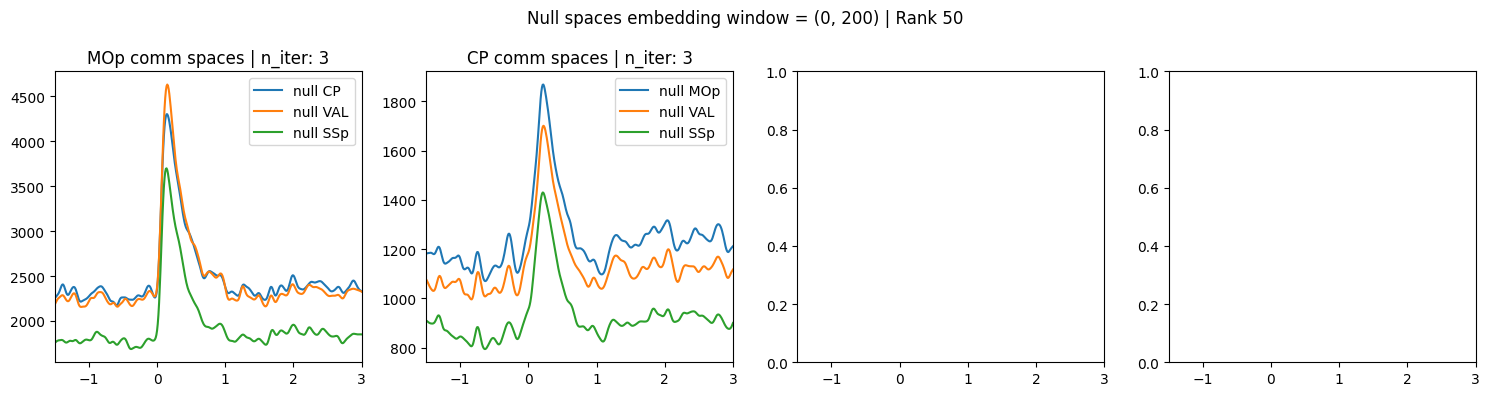

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharex='all')
times = (np.arange(0, 501) / 100) - 2
for area_a, ax in zip(vars.keys(), axs):
    for area_b in vars[area_a].keys():
        if area_a == area_b:
            label = 'full'
        else:
            label = f"null {area_b}"
        ax.plot(times, vars[area_a][area_b], label=label)
        ax.set_title(f'{area_a} comm spaces | n_iter: {iter_dict[area_a]}')
        ax.legend()
        ax.set_xlim(-1.5, 3)
plt.suptitle(f'Null spaces embedding window = {window_emb} | Rank {50}')
plt.tight_layout()

## MOp null comm subspaces

In [176]:
idx_to_keep = 100
window = 100
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
origin_signal = 'MOp_rates_pca'
target_signal = 'VAL_rates_pca'

X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)

Dropping classes with count < 3: [0, 4]
Counts: {0: 2, 1: 17, 2: 16, 3: 14, 4: 2, 5: 14, 6: 10, 7: 3, 8: 7, 9: 4, 10: 7, 11: 4}


  0%|          | 0/402 [00:00<?, ?it/s]

100%|██████████| 402/402 [00:04<00:00, 94.94it/s]


(0.0, 0.5)

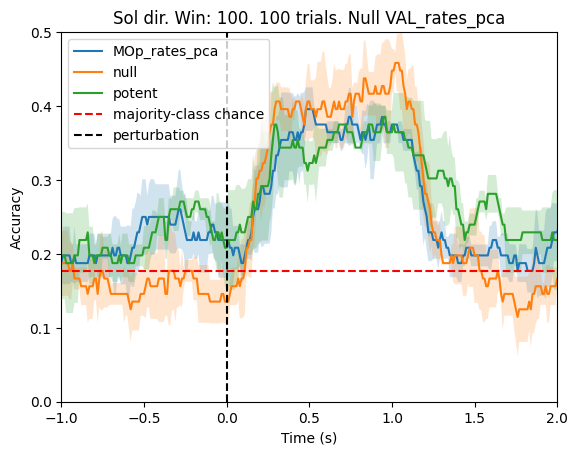

In [177]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Sol dir. Win: {window}. {idx_to_keep} trials. Null {target_signal}')

ax.legend()
ax.set_xlim(-1, 2)
ax.set_ylim(0, 0.5)

In [155]:
origin_signal ='MOp_rates_pca'
target_signal = 'VAL_rates_pca'
scorer = make_scorer(r2_score)

idx_to_keep=(0, 200)
window = 50
idx = sorted(dstrb_idx[idx_to_keep[0]:idx_to_keep[1]])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
y = perturb_td_shuff_filt.disturb_sum.values
# y = np.concatenate(perturb_td_shuff_filt.disturb_score.values)


def opt_ridge_alpha(x_cv, y_cv):
    alphas = np.logspace(-10, 4, 50)
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(x_cv, y_cv)
    return ridge_cv.alpha_

X_null = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
alpha = opt_ridge_alpha(
        X_null.reshape(X_null.shape[0], -1), 
        y
    )
print(alpha)
scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='lsqr'),
    X_null,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

X_full = np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)
alpha = opt_ridge_alpha(
        X_full.reshape(X_full.shape[0], -1), 
        y
    )
print(alpha)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(solver='lsqr'),
    X_full,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

X_potent = np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)
alpha = opt_ridge_alpha(
        X_potent.reshape(X_potent.shape[0], -1), 
        y
    )
print(alpha)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='lsqr'),
    X_potent,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

10000.0


100%|██████████| 226/226 [00:04<00:00, 48.72it/s]


1e-10


100%|██████████| 226/226 [00:07<00:00, 30.90it/s]


10000.0


100%|██████████| 226/226 [00:02<00:00, 91.17it/s]


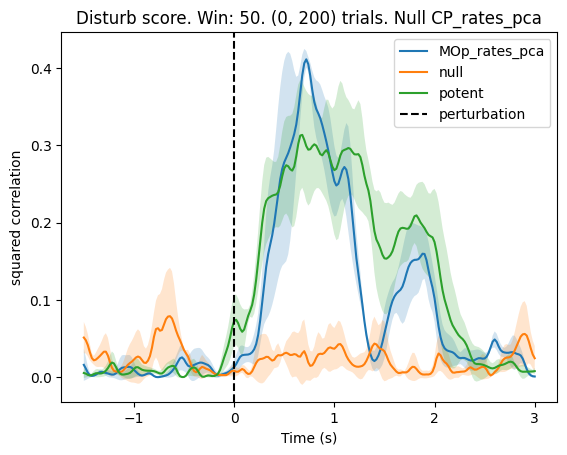

In [21]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


# ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('squared correlation')
ax.set_title(f'Disturb score. Win: {window}. {idx_to_keep} trials. Null {target_signal}')
# ax.set_ylim(-0.1, 0.1)
ax.legend()

ax.legend()

## VAL null comm subspaces

In [178]:
idx_to_keep = 100
window = 50
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
origin_signal = 'VAL_rates_pca'
target_signal = 'MOp_rates_pca'

X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)

Dropping classes with count < 3: [0, 4]
Counts: {0: 2, 1: 17, 2: 16, 3: 14, 4: 2, 5: 14, 6: 10, 7: 3, 8: 7, 9: 4, 10: 7, 11: 4}


  0%|          | 0/452 [00:00<?, ?it/s]

100%|██████████| 452/452 [00:04<00:00, 105.98it/s]


(-1.0, 2.0)

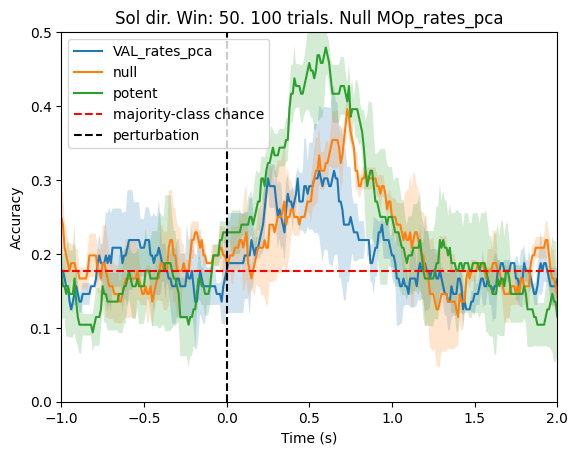

In [182]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Sol dir. Win: {window}. {idx_to_keep} trials. Null {target_signal}')

ax.legend()
ax.set_ylim(0, 0.5)
ax.set_xlim(-1, 2)


## CP null comm subspaces

In [ ]:
idx_to_keep = 100
window = 50
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = (
#     perturb_td_shuff_filt
#     .sort_values(by='trial_id')
#     .reset_index(drop=True)
# )
origin_signal = 'VAL_rates_pca'
target_signal = '_rates_pca'

X = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
y = perturb_td_shuff_filt.values_Sol_direction.values.tolist()

X_filt, y_filt, mask, chance = drop_classes_below_count(X, y, min_count=3, return_mask=True)

n_trials, _, _ = X.shape
scores_null, times = decode.moving_window_decoding(
    X_filt,
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_full, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)
scores_potent, times = decode.moving_window_decoding(
    np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)[mask],
    y_filt,
    cv=StratifiedKFold(n_splits=3),
    window_length_bin=window,
    step_bin=1
)

KeyError: 'VAL_rates_pca_null_MOp_rates_pca'

(-1.0, 2.0)

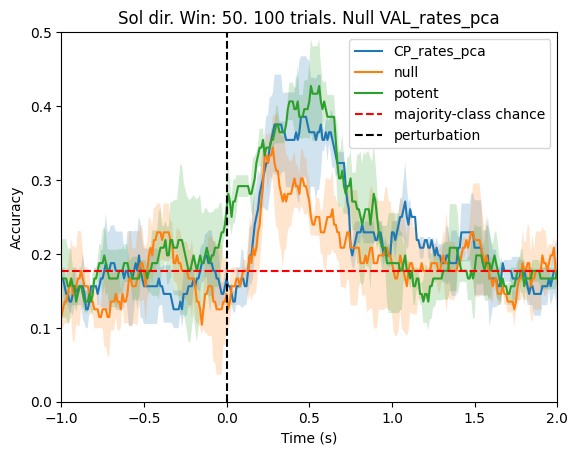

In [159]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


ax.axhline(chance, color='red', linestyle='dashed', label='majority-class chance')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Sol dir. Win: {window}. {idx_to_keep} trials. Null {target_signal}')

ax.legend()
ax.set_ylim(0, 0.5)
ax.set_xlim(-1, 2)


In [53]:
origin_signal ='CP_rates_pca'
target_signal = 'MOp_rates_pca'
scorer = make_scorer(r2_score)

idx_to_keep=(0, 200)
window = 50
idx = sorted(dstrb_idx[idx_to_keep[0]:idx_to_keep[1]])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
y = perturb_td_shuff_filt.disturb_sum.values
# y = np.concatenate(perturb_td_shuff_filt.disturb_score.values)


def opt_ridge_alpha(x_cv, y_cv):
    alphas = np.logspace(-6, 6, 50)
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(x_cv, y_cv)
    return ridge_cv.alpha_

X_null = np.stack(perturb_td_shuff_filt[f'{origin_signal}_null_{target_signal}'].values)
alpha = opt_ridge_alpha(
        X_null.reshape(X_null.shape[0], -1), 
        y
    )
print(alpha)
scores_null, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='auto'),
    X_null,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

X_full = np.stack(perturb_td_shuff_filt[f'{origin_signal}'].values)
alpha = opt_ridge_alpha(
        X_full.reshape(X_null.shape[0], -1), 
        y
    )
print(alpha)
scores_full, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='auto'),
    X_full,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

X_potent = np.stack(perturb_td_shuff_filt[f'{origin_signal}_potent_{target_signal}'].values)
alpha = opt_ridge_alpha(
        X_potent.reshape(X_null.shape[0], -1), 
        y
    )
print(alpha)
scores_potent, times = decode.decoding_moving_window_no_time_concat(
    Ridge(alpha, solver='auto'),
    X_potent,
    y,
    cv=KFold(n_splits=3),
    # scorer=scorer,
    window_length_bin=window,
    step_bin=2
)

568986.6029018281


100%|██████████| 226/226 [00:02<00:00, 85.11it/s] 


59636.23316594637


100%|██████████| 226/226 [00:04<00:00, 53.54it/s]


184206.99693267164


100%|██████████| 226/226 [00:02<00:00, 78.99it/s]


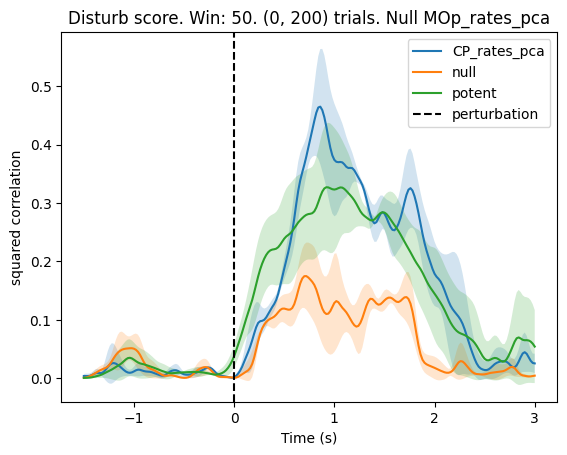

In [54]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-2, scores_full, label=origin_signal)
vizutils.shaded_errorbar(ax, times-2, scores_null, label='null')
vizutils.shaded_errorbar(ax, times-2, scores_potent, label='potent')


# ax.axhline(0, color='red', linestyle='dashed', label='mean-pred')
ax.axvline(0, color='k', linestyle='dashed', label='perturbation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('squared correlation')
ax.set_title(f'Disturb score. Win: {window}. {idx_to_keep} trials. Null {target_signal}')
# ax.set_ylim(0, 0.5)
ax.legend()

ax.legend()

# Refactoring v3

## Preprocessing

In [3]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [4]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [5]:
df__ = dt.add_pca_df(df_)


In [6]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [7]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10, event_onset=(100, 500))
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 41 of 333 rows (12.31%).


In [8]:
df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

# make private and shared

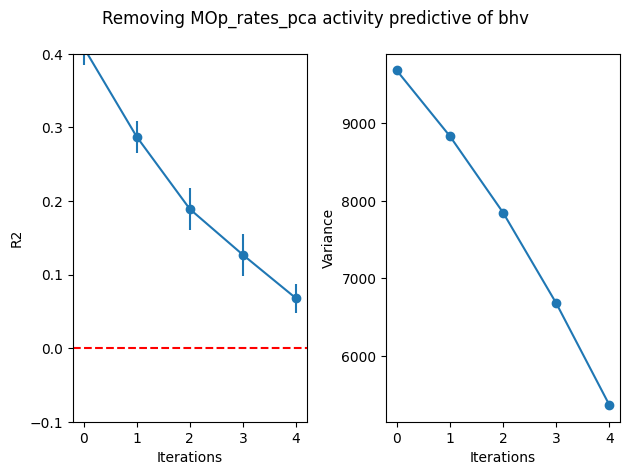

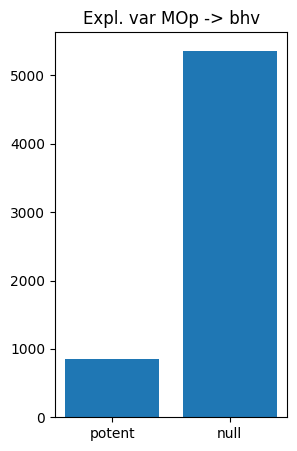

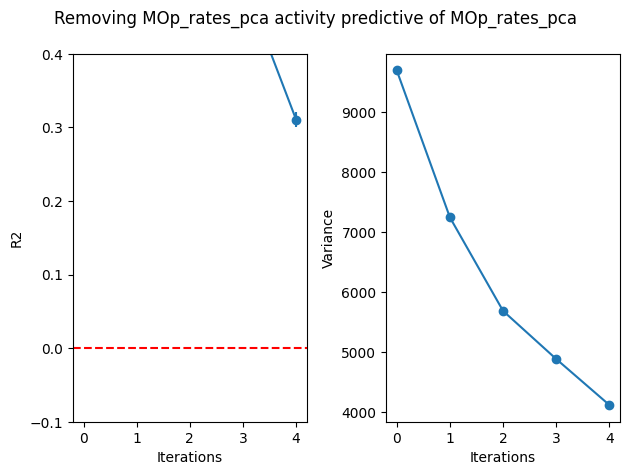

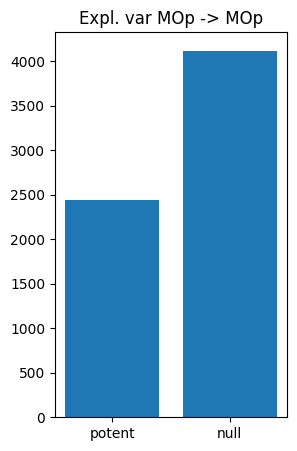

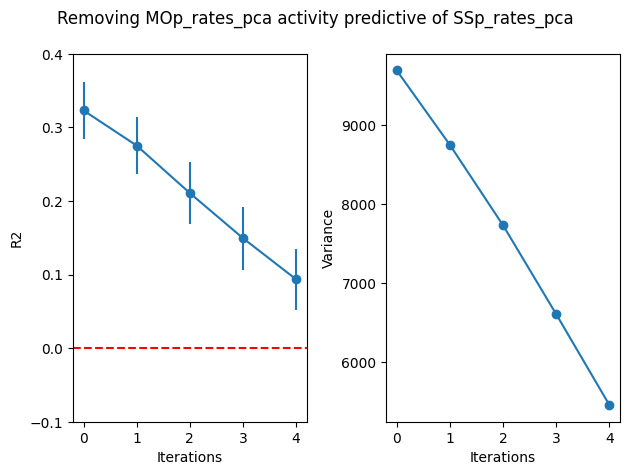

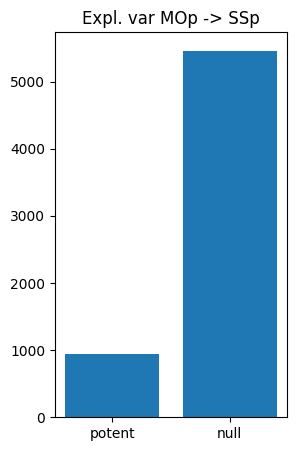

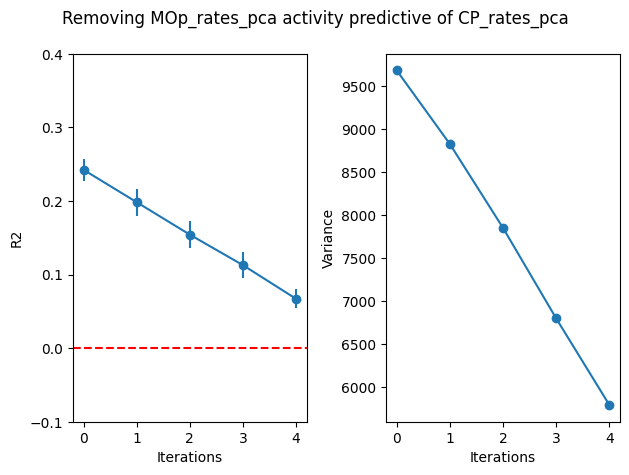

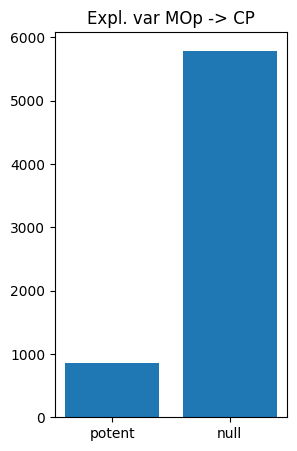

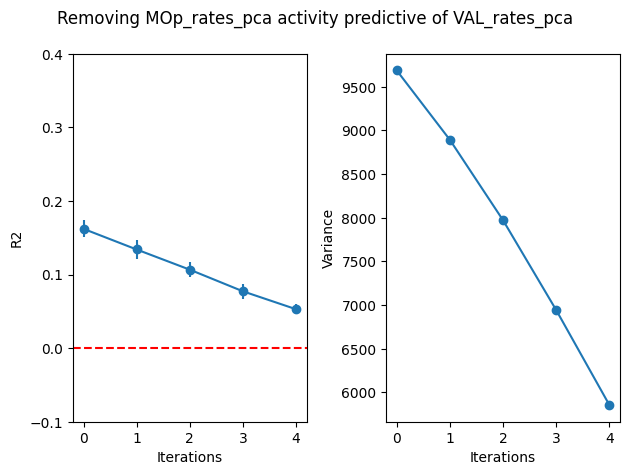

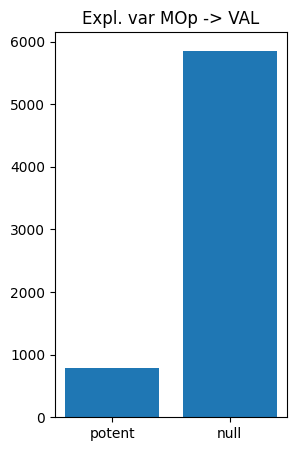

In [ ]:
df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

areas = ['MOp', 'SSp', 'CP', 'VAL']
iter_dict = {
    'MOp': 4,
    'CP': 4,
    'VAL': 2,
    'SSp':3
}
window_emb = (200, 450)
vars = {}
rank_dict = {
    'MOp': 30,
    'CP': 30,
    'VAL': 50,
    'SSp': 20
}
target_lag_dict = {
    'MOp': {
        'bhv': 1,
        'MOp': None,
        'SSp': -1,
        'CP': -2,
        'VAL': -4
    },
    'SSp': {
        'bhv': None,
        'MOp': 1,
        'SSp': None,
        'CP': -1,
        'VAL': -4
    },
    'CP': {
        'bhv': None,
        'MOp': 2,
        'SSp': 1,
        'CP': None,
        'VAL': -1
    },
    'VAL': {
        'bhv': None,
        'MOp': 4,
        'SSp': 2,
        'CP': 1,
        'VAL': None
    }
}
for area_a in areas[:1]:
    vars[area_a] = {}
    for area_b in ['bhv'] + areas:
        if area_b != 'bhv':
            label = f"{area_b}_rates_pca"
        else:
            label = area_b
        perturb_td_shuff, var_potent = subspaces.publicise_signal_td(
            perturb_td_shuff,
            origin_signal=f"{area_a}_rates_pca",
            target_signal=label,
            rank=rank_dict[area_a],
            window_emb=window_emb,
            target_lag=target_lag_dict[area_a][area_b]
        )
        perturb_td_shuff, var_null = subspaces.privatise_signal_td(
            perturb_td_shuff,
            n_iter=iter_dict[area_a],
            origin_signal=f"{area_a}_rates_pca",
            target_signal=label,
            rank=rank_dict[area_a],
            window_emb=window_emb,
            diagnostics=True,
            target_lag=target_lag_dict[area_a][area_b]
        )
        fig, ax = plt.subplots(figsize=(3, 5))
        ax.bar(['potent', 'null'], [var_potent, var_null])
        ax.set_title(f'Expl. var {area_a} -> {area_b}')


## decoding perturb strength and sol dir

In [168]:
def opt_ridge_alpha_(x_cv, y_cv, cv):
    alphas = np.logspace(-5, 5, 50)
    ridge_cv = RidgeCV(alphas=alphas, scoring=decode.get_custom_scorer(), cv=cv)
    ridge_cv.fit(x_cv, y_cv)
    return ridge_cv.alpha_

def naive_opt_alpha(alpha_range, cv_scores):
    """
    Select the alpha value with the highest cross-validated test score

    Parameters
    ----------
    alpha_range : array-like
        candidate alpha values
    cv_scores : array-like
        cross-validated test scores corresponding
        to the values in alpha_range

    Returns
    -------
    optimal alpha : float
    """
    means = [np.mean(sc) for sc in cv_scores]

    return alpha_range[np.argmax(means)]

def opt_ridge_alpha(X, y, n_alpha=50, cv=KFold(5), scorer=decode.get_custom_scorer()):
    candidate_alphas = np.logspace(-5, 6, n_alpha)
    cv_scores = [
        cross_val_score(Ridge(alpha, solver='lsqr'), X, y, cv=cv, scoring=scorer)
        for alpha in tqdm(candidate_alphas)
    ]

    return naive_opt_alpha(candidate_alphas, cv_scores)

In [178]:
def decode_perturb_score_potent_null(td, area_origin, area_target, k=3, window=100, shuffle=False, rnd=None,
                                     opt_alpha=True, scorer=decode.get_custom_scorer()):
    if shuffle:
        rnd = 42
    y = td.disturb_sum.values
    if area_b == 'bhv':
        labels = [
            f'{area_origin}_rates_pca',
            f'{area_origin}_rates_pca_null_{area_target}',
            f'{area_origin}_rates_pca_potent_{area_target}',
            'lower_bound'
        ]
    else:
        labels = [
            f'{area_origin}_rates_pca',
            f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
            f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
            # 'lower_bound'
        ]
    scores_list, y_preds_list = [], []
    for label in labels:
        if label == 'lower_bound':
            rng = np.random.default_rng(seed=42)
            perm = rng.permutation(y.shape[0])
            y = y[perm]
            label = labels[2]
        X = np.stack(td[label].values)
        if opt_alpha:
            alpha=opt_ridge_alpha(X.reshape(X.shape[0], -1), y, cv=KFold(shuffle=shuffle, random_state=rnd, n_splits=k))
            print(f'Alpha param {alpha:.3f}')
        else:
            alpha=0
        scores, times, y_preds = decode.decoding_moving_window_no_time_concat(
            Ridge(alpha, solver='lsqr'),
            X,
            y,
            cv=KFold(shuffle=shuffle, random_state=rnd, n_splits=k),
            scorer=scorer,
            window_length_bin=window,
            step_bin=2
        )
        scores_list.append(scores)
        y_preds_list.append(y_preds)

    
    return scores_list, times, y_preds_list

def decode_kinematics_potent_null(td, area_origin, area_target, keypoint, 
                                  k=3, window=100, rnd=None,
                                  opt_alpha=True, step_bin=2, scorer=decode.get_custom_scorer()):

    y = np.stack(td[keypoint].values)
    labels = [
        # f'{area_origin}_rates_pca',
        f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
    ]
    scores_list = []
    for label in labels:
        X = np.stack(td[label].values)
        if opt_alpha:
            alpha=opt_ridge_alpha(X.reshape(-1, X.shape[-1]), y.reshape(-1, y.shape[-1]), 
                                  cv=KFold(n_splits=k), scorer=scorer)
            print(f'Alpha param {alpha:.3f}')
        else:
            alpha=1
        scores, times = decode.regression_moving_window(
            X,
            y,
            alpha=alpha,
            cv=KFold(shuffle=False, n_splits=k),
            scorer=scorer,
            window_length_bin=window,
            step_bin=step_bin
        )
        scores_list.append(scores)

    return scores_list, times

def decode_sol_dir_potent_null(td, area_origin, area_target, k=3, window=100, shuffle=False, rnd=None):
    if shuffle:
        rnd = 42
    y = np.array(td.values_Sol_direction.values.tolist())
    classes, counts = np.unique(y, return_counts=True)
    chance = majority_class_chance_levels_from_counts(counts)
    if area_b == 'bhv':
        labels = [
            f'{area_origin}_rates_pca',
            f'{area_origin}_rates_pca_null_{area_target}',
            f'{area_origin}_rates_pca_potent_{area_target}',
            # 'lower_bound'
        ]
    else:
        labels = [
            f'{area_origin}_rates_pca',
            f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
            f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
            # 'lower_bound'
        ]
    scores_list = []
    for label in labels:
        if label == 'lower_bound':
            rng = np.random.default_rng(seed=42)
            perm = rng.permutation(y.shape[0])
            y = y[perm]
            label = labels[2]
        X = np.stack(td[label].values)
        scores, times = decode.moving_window_decoding(
            X,
            y,
            cv=StratifiedKFold(n_splits=k, shuffle=shuffle, random_state=rnd),
            window_length_bin=window,
            step_bin=2,
        )
        scores_list.append(scores)

    
    return scores_list, times, chance


In [50]:
area_a ='MOp'
area_b = 'CP'
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

idx_to_keep = 200
window = 50
shuffle = True
opt_alpha = True
step_bin = 2
keypoint = 'bhv'


idx = sorted(dstrb_idx[2:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
# perturb_td_shuff_filt = dt.add_bhv(
#     perturb_td_shuff_filt, bhv_fields=get_limb(False, 'left')+get_limb(False, 'right')
# )
perturb_td_shuff_filt_ord = (
    perturb_td_shuff_filt
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)


# scores_perturb, times, _ = decode_perturb_score_potent_null(perturb_td_shuff_filt_ord, area_a, area_b, 
#                                                      window=window,
#                                                      k=5,
#                                                      shuffle=shuffle,
#                                                      opt_alpha=opt_alpha,
#                                                     #  scorer=vw_r2_scorer,
#                                                     # rnd=40
#                                                      )
# scores_kin, times_kin = decode_kinematics_potent_null(perturb_td_shuff_filt, area_a, area_b,
#                                                      keypoint=keypoint, 
#                                                      window=20,
#                                                      k=5,
#                                                      opt_alpha=opt_alpha,
#                                                      step_bin=step_bin,
#                                                      scorer=vw_r2_scorer
#                                                      )                                                     
scores_dir, times, chance = decode_sol_dir_potent_null(perturb_td_shuff_filt_ord, area_a, area_b, 
                                                    window=window,
                                                     k=5,
                                                     shuffle=shuffle,
                                                     )

100%|██████████| 226/226 [00:04<00:00, 56.01it/s]


Text(0.5, 0.98, '200 trials. 0.5 s. Shuffle: True. Opt-alpha: True')

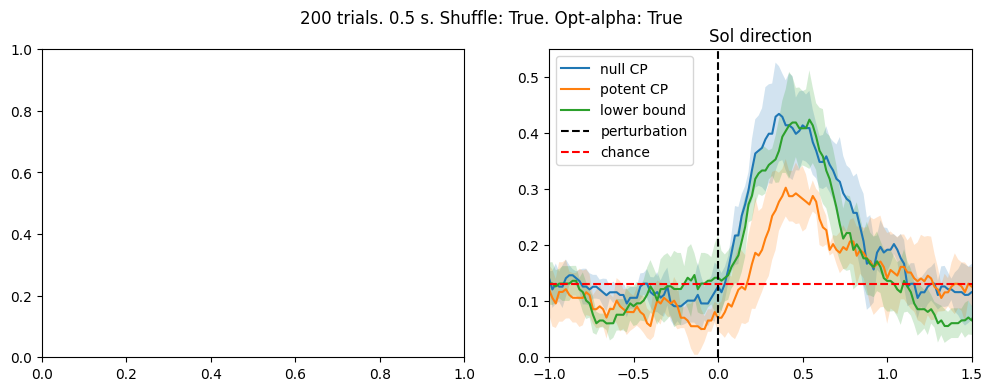

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey='none')
# vizutils.shaded_errorbar(ax[0], times-2, scores_perturb[0], label=f'full {area_a}')
# vizutils.shaded_errorbar(ax[0], times-2, scores_perturb[1], label=f'null {area_b}')
# vizutils.shaded_errorbar(ax[0], times-2, scores_perturb[2], label=f'potent {area_b}')
# # vizutils.shaded_errorbar(ax[0], times-2, scores_perturb[3], label=f'lower bound')

# ax[0].axvline(0, color='k', linestyle='dashed', label='perturbation')
# ax[0].set_xlabel('Time (s)')
# ax[0].set_ylabel('squared correlation')
# ax[0].set_title(f'Disturb score')
# ax[0].legend()
# ax[0].set_ylim(-0.1, 0.6)



vizutils.shaded_errorbar(ax[1], times-2, scores_dir[0], label=f'null {area_b}')
vizutils.shaded_errorbar(ax[1], times-2, scores_dir[1], label=f'potent {area_b}')
vizutils.shaded_errorbar(ax[1], times-2, scores_dir[2], label=f'lower bound')


ax[1].set_title(f'Sol direction')
ax[1].axvline(0, color='k', linestyle='dashed', label='perturbation')
ax[1].axhline(chance, color='r', linestyle='dashed', label='chance')

ax[1].legend()
ax[1].set_xlim(-1, 1.5)
ax[1].set_ylim(0, 0.55)

plt.suptitle(f'{idx_to_keep} trials. {window * 0.01} s. ' 
             f'Shuffle: {shuffle}. Opt-alpha: {opt_alpha}')

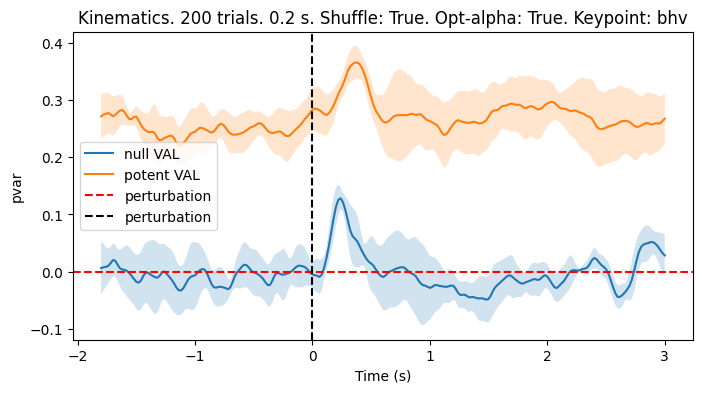

In [206]:
fig, ax = plt.subplots(figsize=(8, 4))
# vizutils.shaded_errorbar(ax, times-2, scores_kin[0], label=f'full {area_a}')
vizutils.shaded_errorbar(ax, times_kin-2, scores_kin[0], label=f'null {area_b}')
vizutils.shaded_errorbar(ax, times_kin-2, scores_kin[1], label=f'potent {area_b}')

ax.axhline(0, color='r', linestyle='dashed', label='perturbation')

ax.axvline(0, color='k', linestyle='dashed', label='perturbation')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pvar')
ax.set_title(f'Kinematics. {idx_to_keep} trials. {20 * 0.01} s. ' 
             f'Shuffle: {shuffle}. Opt-alpha: {opt_alpha}. Keypoint: {keypoint}')
ax.legend()
# ax.set_ylim(-0.1, 0.55)
# ax.set_xlim(-1, 1.25)

100%|██████████| 50/50 [00:21<00:00,  2.34it/s]


Alpha param 4714866.363


100%|██████████| 50/50 [00:08<00:00,  6.25it/s]


Alpha param 1389495.494


100%|██████████| 50/50 [00:05<00:00,  9.50it/s]


...

100%|██████████| 50/50 [00:01<00:00, 32.07it/s]


Alpha param 100000000.000


100%|██████████| 50/50 [00:03<00:00, 15.97it/s]


Alpha param 409491.506


100%|██████████| 226/226 [00:02<00:00, 77.35it/s]
/tmp/ipykernel_2160534/1930104695.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


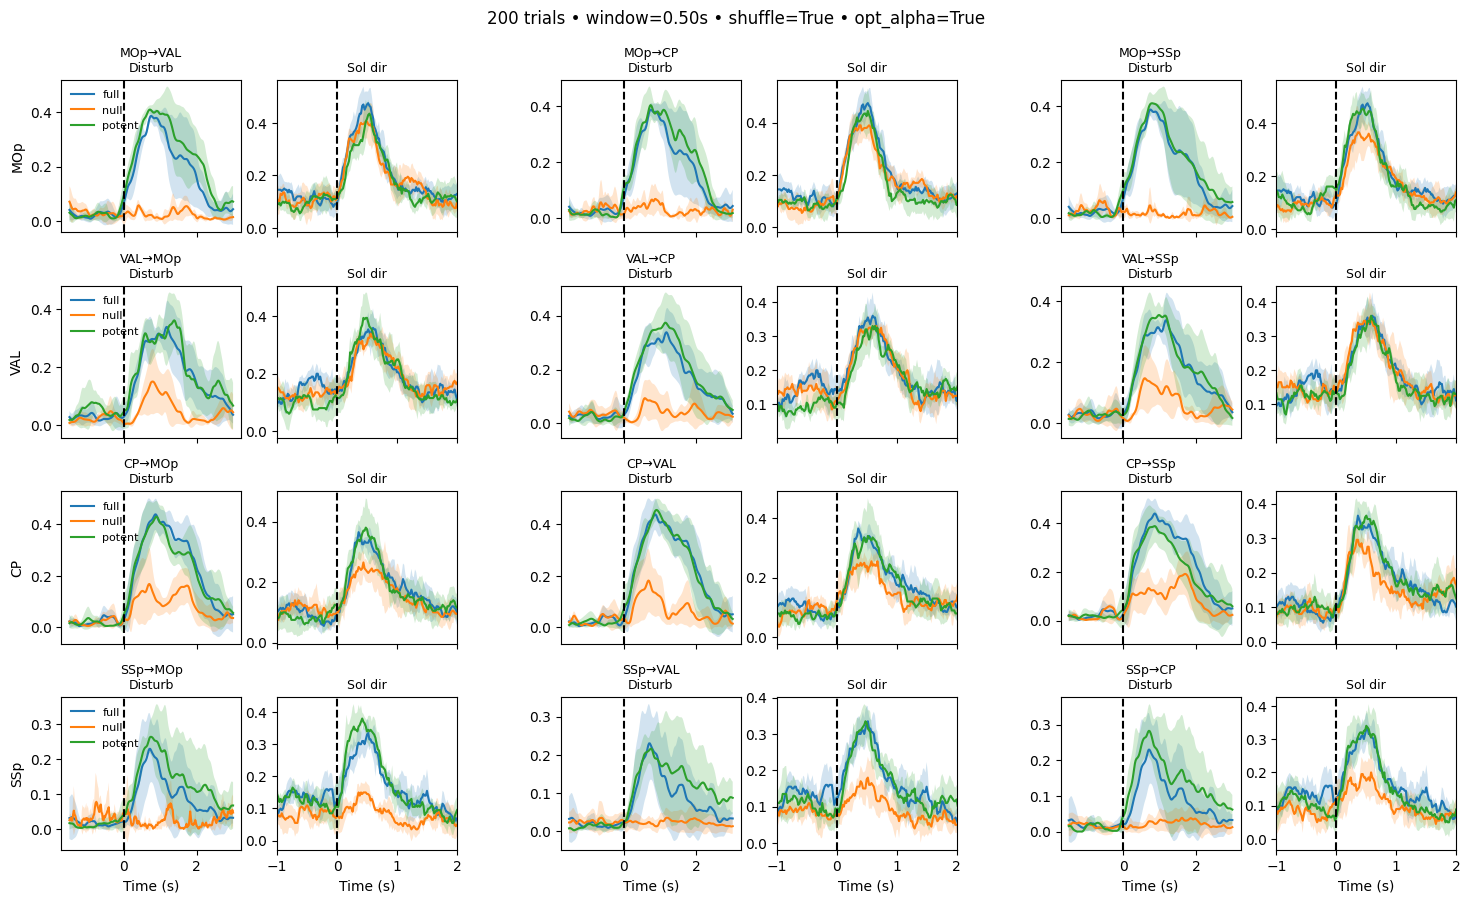

In [192]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

########## PARAMS ############
idx_to_keep = 200
window = 50
shuffle = True
opt_alpha = True

########## DATA ##########
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
perturb_td_shuff_filt = (
    perturb_td_shuff_filt
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)

########## LAYOUT ##########
n_rows = len(areas)
# per row we have (n_targets = len(areas)-1) pairs, each pair is 2 cols + 1 spacer col
n_targets = len(areas) - 1
n_cols = n_targets * 3 - 1  # no spacer after last pair

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    # [Disturb, SolDir, Spacer] repeated; make spacer narrow
    width_ratios=([1.0, 1.0, 0.18] * (n_targets - 1)) + [1.0, 1.0],
    wspace=0.25,  # space between columns inside a pair
    hspace=0.35   # space between rows
)

########## MAIN LOOP ##########
for r, area_a in enumerate(areas):
    targets = [b for b in areas if b != area_a]

    for j, area_b in enumerate(targets):
        col0 = j * 3  # disturb column for this pair
        ax_dist = fig.add_subplot(gs[r, col0])
        ax_dir  = fig.add_subplot(gs[r, col0 + 1])

        # --- compute (uncomment your calls) ---
        scores_perturb, times, _ = decode_perturb_score_potent_null(
            perturb_td_shuff_filt, area_a, area_b,
            window=window, k=5, shuffle=shuffle, opt_alpha=opt_alpha
        )
        scores_dir, times, chance = decode_sol_dir_potent_null(
            perturb_td_shuff_filt, area_a, area_b,
            window=window, k=5, shuffle=shuffle
        )

        # --- plotting: Disturb (left of pair) ---
        vizutils.shaded_errorbar(ax_dist, times - 2, scores_perturb[0], label='full')
        vizutils.shaded_errorbar(ax_dist, times - 2, scores_perturb[1], label='null')
        vizutils.shaded_errorbar(ax_dist, times - 2, scores_perturb[2], label='potent')
        ax_dist.axvline(0, color='k', linestyle='dashed')
        ax_dist.set_title(f"{area_a}→{area_b}\nDisturb", fontsize=9)

        # --- plotting: Sol direction (right of pair) ---
        vizutils.shaded_errorbar(ax_dir, times - 2, scores_dir[0], label='full')
        vizutils.shaded_errorbar(ax_dir, times - 2, scores_dir[1], label='null')
        vizutils.shaded_errorbar(ax_dir, times - 2, scores_dir[2], label='potent')
        ax_dir.axvline(0, color='k', linestyle='dashed')
        ax_dir.set_title("Sol dir", fontsize=9)
        ax_dir.set_xlim(-1, 2)


        # --- labels only on outer edges to reduce clutter ---
        if j == 0:
            ax_dist.set_ylabel(area_a)
        else:
            ax_dist.set_ylabel("")
            ax_dir.set_ylabel("")

        if r == n_rows - 1:
            ax_dist.set_xlabel("Time (s)")
            ax_dir.set_xlabel("Time (s)")
        else:
            ax_dist.set_xlabel("")
            ax_dir.set_xlabel("")
            ax_dist.tick_params(labelbottom=False)
            ax_dir.tick_params(labelbottom=False)

        # Optional: one legend per row (first pair only)
        if j == 0:
            ax_dist.legend(frameon=False, fontsize=8)

plt.suptitle(
    f"{idx_to_keep} trials • window={window*0.01:.2f}s • shuffle={shuffle} • opt_alpha={opt_alpha}",
    y=0.95
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

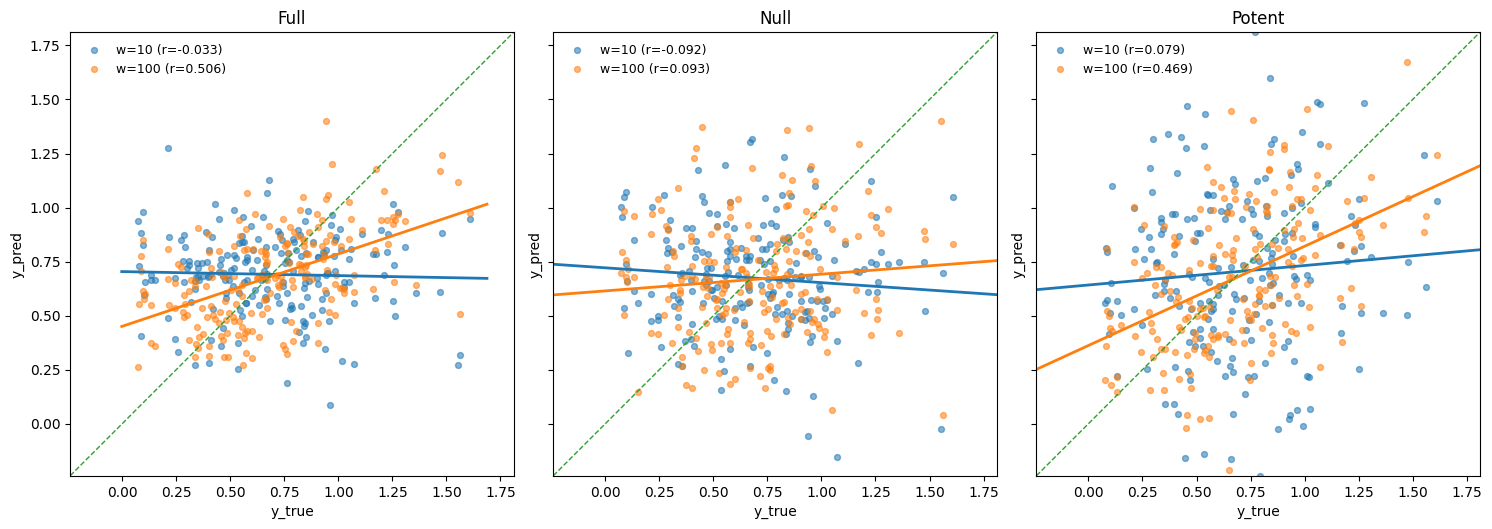

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_true = perturb_td_shuff_filt.disturb_sum.values

window_idxs = [1, 75]
window_names = {75: "w=100", 1: "w=10"}  # edit labels if you prefer
labels = ["Full", "Null", "Potent"]

# Global limits across both windows and all three models
all_preds = []
for wi in window_idxs:
    all_preds += [y_preds[i][wi, :] for i in range(3)]

min_val = min(np.min(y_true), *(np.min(p) for p in all_preds))
max_val = max(np.max(y_true), *(np.max(p) for p in all_preds))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    # Plot both windows on the same panel
    for wi in window_idxs:
        y_pred = y_preds[i][wi, :]
        r = np.corrcoef(y_true, y_pred)[0, 1]

        sns.regplot(
            x=y_true,
            y=y_pred,
            ax=ax,
            ci=None,          # keep clean; set to 95 if you want CI bands
            truncate=False,
            scatter_kws=dict(s=18, alpha=0.55),
            line_kws=dict(linewidth=2),
            label=f"{window_names[wi]} (r={r:.3f})"
        )

    # Identity line
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

    ax.set_title(labels[i])
    ax.set_xlabel("y_true")
    ax.set_ylabel("y_pred")
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# Overlap of motor potent and com subspaces

In [123]:
idx = sorted(dstrb_idx[2:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
area_a = 'MOp'
area_b = 'CP'
for area_b in ['SSp', 'CP', 'VAL']:
    _, _, emb = subspaces.publicise_signal_td(
                perturb_td_shuff,
                origin_signal=f"{area_a}_rates_pca",
                target_signal=f"{area_b}_rates_pca",
                rank=rank_dict[area_a],
                window_emb=window_emb,
                target_lag=target_lag_dict[area_a][area_b],
                return_emb=True
            )
    _, _, motor_emb = subspaces.publicise_signal_td(
                perturb_td_shuff,
                origin_signal=f"{area_a}_rates_pca",
                target_signal=f"bhv",
                rank=rank_dict[area_a],
                window_emb=window_emb,
                target_lag=None,
                return_emb=True
            )
    overlap = subspaces.compute_overlap_between_subspaces(emb, motor_emb)
    print(f'Motor overlap {area_a}->{area_b} comm subspace: {overlap:.3f}')

Motor overlap MOp->SSp comm subspace: 0.315
Motor overlap MOp->CP comm subspace: 0.344
Motor overlap MOp->VAL comm subspace: 0.326


In [177]:
def permute_bhv_across_trials(td, bhv_col="bhv", rng=None):
    rng = np.random.default_rng(rng)
    td_perm = td.copy()
    bhv_list = list(td_perm[bhv_col].values)
    rng.shuffle(bhv_list)
    td_perm.loc[:, bhv_col] = bhv_list
    return td_perm

def overlap_null(td, area_a, area_b, n_perm=200, rng=0, rank=rank_dict[area_a],
                 window_emb=(200, 480)):
    # observed
    _, _, emb = subspaces.publicise_signal_td(
        td, f"{area_a}_rates_pca", f"{area_b}_rates_pca",
        rank=rank_dict[area_a], window_emb=window_emb,
        target_lag=target_lag_dict[area_a][area_b], return_emb=True
    )
    _, _, motor_emb = subspaces.publicise_signal_td(
        td, f"{area_a}_rates_pca", "bhv",
        rank=rank, window_emb=window_emb,
        target_lag=None, return_emb=True
    )
    obs = subspaces.compute_overlap_between_subspaces(emb, motor_emb)

    # null
    null = np.empty(n_perm)
    for i in tqdm(range(n_perm)):
        td_perm = permute_bhv_across_trials(td, "bhv", rng=rng+i)
        _, _, motor_emb_p = subspaces.publicise_signal_td(
            td_perm, f"{area_a}_rates_pca", "bhv",
            rank=rank, window_emb=window_emb,
            target_lag=None, return_emb=True
        )
        null[i] = subspaces.compute_overlap_between_subspaces(emb, motor_emb_p)

    p = (1 + (null >= obs).sum()) / (n_perm + 1)
    z = (obs - null.mean()) / (null.std(ddof=1) + 1e-12)
    return obs, null, p, z

In [217]:
perturb_td_shuff_bhv.bhv.values[0].shape

(501, 36)

In [228]:
areas_b = ['SSp', 'CP', 'VAL']
n_perm = 50
rng = 1
area_a = 'MOp'
window_emb_pre = (5, 185)
window_emb_post = (200, 390)

rows = []
null_by_area = {}


idx_to_keep = 200
idx = sorted(dstrb_idx[2:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]

# perturb_td_shuff_bhv = dt.add_bhv(perturb_td_shuff_filt, bhv_fields=get_limb(False, 'left') + get_limb(False, 'right'))
perturb_td_shuff_bhv = perturb_td_shuff_filt.copy()

for area_b in areas_b:
    obs, null, p, z = overlap_null(perturb_td_shuff_bhv, area_a, area_b, 
                                   n_perm=n_perm, rng=rng, window_emb=window_emb_post,
                                   rank=36)

    null = np.asarray(null)
    null_by_area[area_b] = null

    rows.append({
        "origin": area_a,
        "target": area_b,
        "obs_overlap": float(obs),
        "null_mean": float(null.mean()),
        "null_sd": float(null.std(ddof=0)),
        "z": float(z),
        "p": float(p),
        "n_perm": int(n_perm),
    })

results_df = pd.DataFrame(rows).set_index("target")
print(results_df)

100%|██████████| 50/50 [00:57<00:00,  1.15s/it]

       origin  obs_overlap  null_mean   null_sd         z         p  n_perm
target                                                                     
SSp       MOp     0.372035   0.299024  0.008265  8.744874  0.019608      50
CP        MOp     0.362889   0.323960  0.008143  4.732400  0.019608      50
VAL       MOp     0.353866   0.330639  0.009726  2.364128  0.019608      50


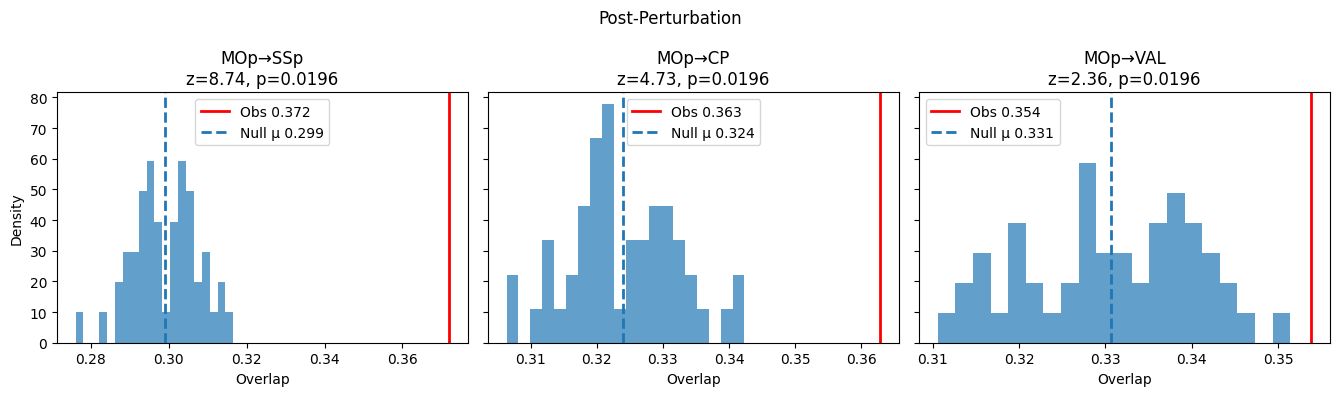

In [230]:
n = len(areas_b)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, area_b in zip(axes, areas_b):
    null = np.asarray(null_by_area[area_b])
    obs = float(results_df.loc[area_b, "obs_overlap"])
    p = float(results_df.loc[area_b, "p"])
    z = float(results_df.loc[area_b, "z"])

    ax.hist(null, bins=20, density=True, alpha=0.7)
    ax.axvline(obs, linewidth=2, label=f"Obs {obs:.3f}", color='red')
    ax.axvline(null.mean(), linestyle="--", linewidth=2, label=f"Null μ {null.mean():.3f}")

    ax.set_title(f"{area_a}→{area_b}\nz={z:.2f}, p={p:.4f}")
    ax.set_xlabel("Overlap")
    ax.legend()

axes[0].set_ylabel("Density")
plt.suptitle('Post-Perturbation')
plt.tight_layout()
plt.show()

In [207]:
areas_b = ['VAL']
n_perm = 20
rng = 1
area_a = 'MOp'

# 4 conditions: (time window) × (limb set)
conditions = [
    {"cond": "pre_forelimb",  "window_emb": (5, 185),   "bhv_fields": get_limb(True,  'left') + get_limb(True,  'right')},
    {"cond": "pre_hindlimb",  "window_emb": (5, 185),   "bhv_fields": get_limb(False, 'left') + get_limb(False, 'right')},
    {"cond": "pert_forelimb", "window_emb": (200, 390), "bhv_fields": get_limb(True,  'left') + get_limb(True,  'right')},
    {"cond": "pert_hindlimb", "window_emb": (200, 390), "bhv_fields": get_limb(False, 'left') + get_limb(False, 'right')},
]

rows = []
null_by_cond = {}  # key: (cond, area_b) -> null array

idx = sorted(dstrb_idx[2:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]

for c in conditions:
    # add bhv for this limb-set
    td_bhv = dt.add_bhv(perturb_td_shuff_filt, bhv_fields=c["bhv_fields"])

    for area_b in areas_b:
        obs, null, p, z = overlap_null(
            td_bhv, area_a, area_b,
            n_perm=n_perm, rng=rng,
            window_emb=c["window_emb"],
            rank=18
        )

        null = np.asarray(null)
        null_by_cond[(c["cond"], area_b)] = null

        rows.append({
            "condition": c["cond"],
            "window_emb": c["window_emb"],
            "limbs": "forelimb" if "forelimb" in c["cond"] else "hindlimb",
            "epoch": "pre" if c["cond"].startswith("pre_") else "pert",
            "origin": area_a,
            "target": area_b,
            "obs_overlap": float(obs),
            "null_mean": float(null.mean()),
            "null_sd": float(null.std(ddof=0)),
            "z": float(z),
            "p": float(p),
            "n_perm": int(n_perm),
        })

results_df = pd.DataFrame(rows)
print(results_df)

100%|██████████| 20/20 [00:20<00:00,  1.00s/it]

       condition  window_emb     limbs epoch origin target  obs_overlap  \
0   pre_forelimb    (5, 185)  forelimb   pre    MOp    VAL     0.339158   
1   pre_hindlimb    (5, 185)  hindlimb   pre    MOp    VAL     0.336316   
2  pert_forelimb  (200, 390)  forelimb  pert    MOp    VAL     0.316512   
3  pert_hindlimb  (200, 390)  hindlimb  pert    MOp    VAL     0.348025   

   null_mean   null_sd         z         p  n_perm  
0   0.321231  0.011768  1.484841  0.095238      20  
1   0.321617  0.013813  1.037194  0.238095      20  
2   0.299046  0.012464  1.365824  0.142857      20  
3   0.302132  0.010465  4.274251  0.047619      20  


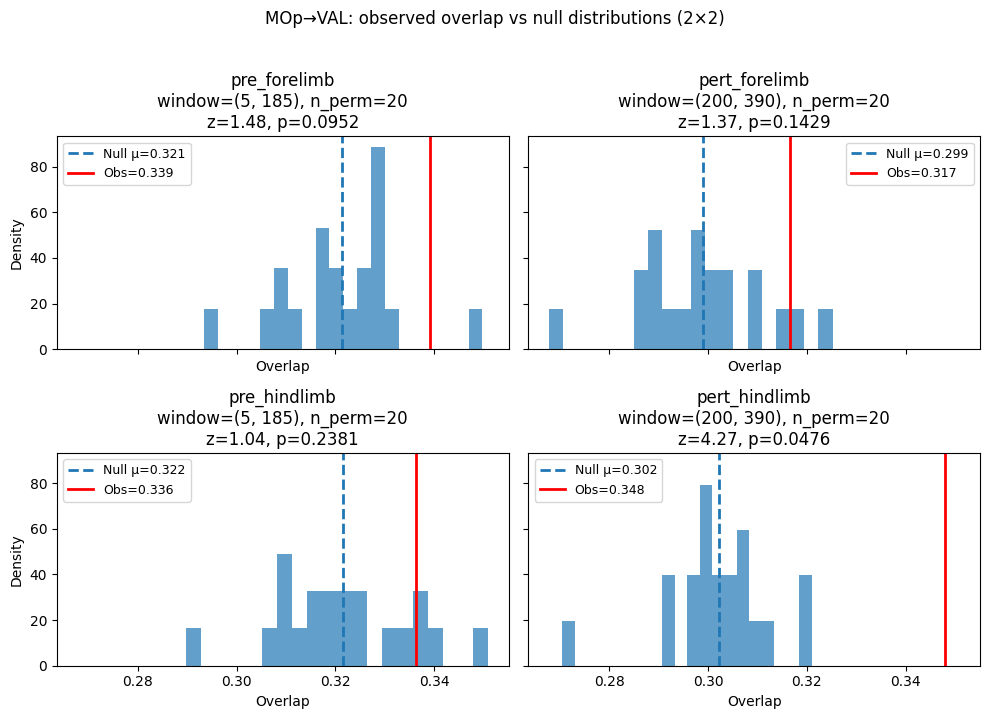

In [208]:
area_b = "VAL"

# Define subplot layout order
cond_grid = [
    ["pre_forelimb",  "pert_forelimb"],
    ["pre_hindlimb", "pert_hindlimb"],
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

for r in range(2):
    for c in range(2):
        cond = cond_grid[r][c]
        ax = axes[r, c]

        null = np.asarray(null_by_cond[(cond, area_b)])
        row = results_df[(results_df["condition"] == cond) & (results_df["target"] == area_b)].iloc[0]
        obs = float(row["obs_overlap"])
        mu = float(row["null_mean"])
        z = float(row["z"])
        p = float(row["p"])
        n_perm = int(row["n_perm"])
        window_emb = row["window_emb"]

        ax.hist(null, bins=20, density=True, alpha=0.7)
        ax.axvline(mu, linestyle="--", linewidth=2, label=f"Null μ={mu:.3f}")
        ax.axvline(obs, linewidth=2, label=f"Obs={obs:.3f}", color='red')

        ax.set_title(f"{cond}\nwindow={window_emb}, n_perm={n_perm}\nz={z:.2f}, p={p:.4f}")
        ax.set_xlabel("Overlap")
        if c == 0:
            ax.set_ylabel("Density")
        ax.legend(fontsize=9)

plt.suptitle(f"{area_a}→{area_b}: observed overlap vs null distributions (2×2)", y=1.02)
plt.tight_layout()

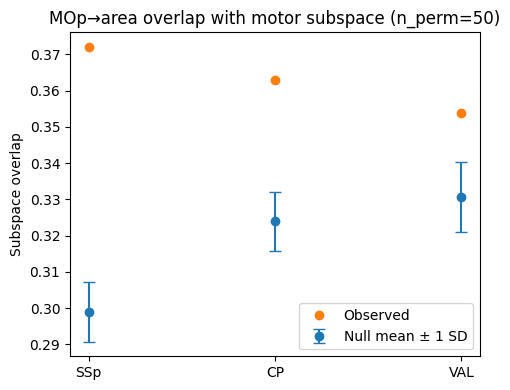

/tmp/ipykernel_435160/3590360758.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(null_list, labels=areas_b, showfliers=False)


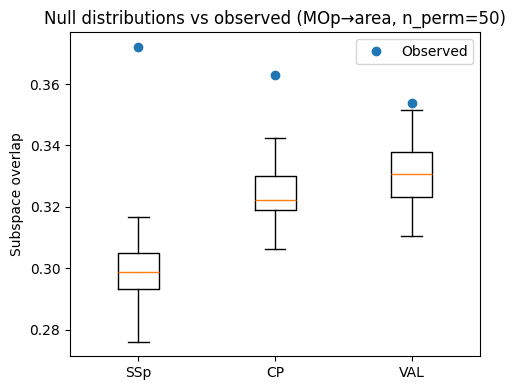

In [231]:
# --- Plot 1: observed vs null mean ± 1 SD across areas ---
x = np.arange(len(areas_b))
obs_vals = results_df.loc[areas_b, "obs_overlap"].values
null_means = results_df.loc[areas_b, "null_mean"].values
null_sds = results_df.loc[areas_b, "null_sd"].values

plt.figure(figsize=(5, 4))
plt.errorbar(x, null_means, yerr=null_sds, fmt='o', capsize=4, label="Null mean ± 1 SD")
plt.plot(x, obs_vals, marker='o', linestyle='None', label="Observed")
plt.xticks(x, areas_b)
plt.ylabel("Subspace overlap")
plt.title(f"{area_a}→area overlap with motor subspace (n_perm={n_perm})")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: null distributions (boxplot) with observed overlaid ---
plt.figure(figsize=(5, 4))
null_list = [null_by_area[a] for a in areas_b]
plt.boxplot(null_list, labels=areas_b, showfliers=False)
plt.plot(np.arange(1, len(areas_b) + 1), obs_vals, marker='o', linestyle='None', label="Observed")
plt.ylabel("Subspace overlap")
plt.title(f"Null distributions vs observed ({area_a}→area, n_perm={n_perm})")
plt.legend()
plt.tight_layout()
plt.show()

# Projections

In [163]:
idx_to_keep = 100
window = 20
shuffle = True
opt_alpha = True
step_bin = 2
keypoint = 'left_elbow'


idx = sorted(dstrb_idx[2:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]


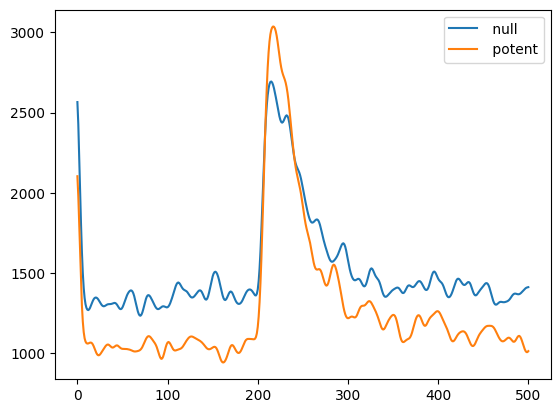

In [167]:
fig, ax = plt.subplots()
arr = subspaces.variance_across_arrays(
    np.stack(perturb_td_shuff_filt.MOp_rates_pca_null_bhv.values)[:, :, :],
)
arr_ = subspaces.variance_across_arrays(
    np.stack(perturb_td_shuff_filt.MOp_rates_pca_potent_bhv.values)[:, :, :],
)
# arr__ = subspaces.variance_across_arrays(
#     np.stack(perturb_td_shuff_filt.MOp_rates_pca.values)[:, :, :10],
# )

# vizutils.shaded_errorbar(ax, np.sum(np.stack(perturb_td_shuff_filt.MOp_rates_pca_null_bhv.values), axis=-1).T, label=' null')
# vizutils.shaded_errorbar(ax, np.sum(np.stack(perturb_td_shuff_filt.MOp_rates_pca_potent_bhv.values), axis=-1).T, label=' potent')

ax.plot(arr, label=' null')
ax.plot(arr_, label=' potent')

# ax.set_xlim(150, 350)
ax.legend()

In [11]:
def frac_var_arr(arr, times, times_total, axis=0, eps=0.0):
    """
    Fraction of total variability (sum of squares around the *total* mean)
    that lies within a sub-interval.

    Parameters
    ----------
    arr : array-like
        Time series data. Time is assumed to be along `axis`.
    times : (start, stop)
        Sub-interval slice [start:stop] in samples (Python slicing, stop exclusive).
    times_total : (start, stop)
        Total interval slice [start:stop] in samples (stop exclusive).
    axis : int
        Time axis.
    eps : float
        Small constant to avoid divide-by-zero if total variability is 0.

    Returns
    -------
    float
    """
    arr = np.asarray(arr)

    # Extract total interval
    sl_total = [slice(None)] * arr.ndim
    sl_total[axis] = slice(times_total[0], times_total[1])
    x_tot = arr[tuple(sl_total)]

    # Global mean over time within total interval
    mu = np.mean(x_tot, axis=axis, keepdims=True)

    # Total sum of squares around global mean
    ss_tot = np.sum((x_tot - mu) ** 2)

    # Extract window interval
    sl_win = [slice(None)] * arr.ndim
    sl_win[axis] = slice(times[0], times[1])
    x_win = arr[tuple(sl_win)]

    # Window sum of squares around the *same* global mean
    ss_win = np.sum((x_win - mu) ** 2)

    return ss_win / (ss_tot + eps)

In [12]:
arr_full = np.stack(perturb_td_shuff_filt.MOp_rates_pca.values)
arr_null = np.stack(perturb_td_shuff_filt.MOp_rates_pca_null_CP_rates_pca.values)
arr_potent = np.stack(perturb_td_shuff_filt.MOp_rates_pca_potent_CP_rates_pca.values)

trials_pre_full = np.array([frac_var_arr(arr_, times=(0, 200), times_total=(0, 400)) for arr_ in arr_full])
trials_post_full = np.array([frac_var_arr(arr_, times=(200, 400), times_total=(0, 400)) for arr_ in arr_full])

trials_pre_null = np.array([frac_var_arr(arr_, times=(0, 200), times_total=(0, 400)) for arr_ in arr_null])
trials_post_null = np.array([frac_var_arr(arr_, times=(200, 400), times_total=(0, 400)) for arr_ in arr_null])

trials_pre_potent = np.array([frac_var_arr(arr_, times=(0, 200), times_total=(0, 400)) for arr_ in arr_potent])
trials_post_potent = np.array([frac_var_arr(arr_, times=(200, 400), times_total=(0, 400)) for arr_ in arr_potent])


Text(0.5, 0.98, 'Fraction of variance within trial pre (-2s -> 0s) and post (0s -> 2s)')

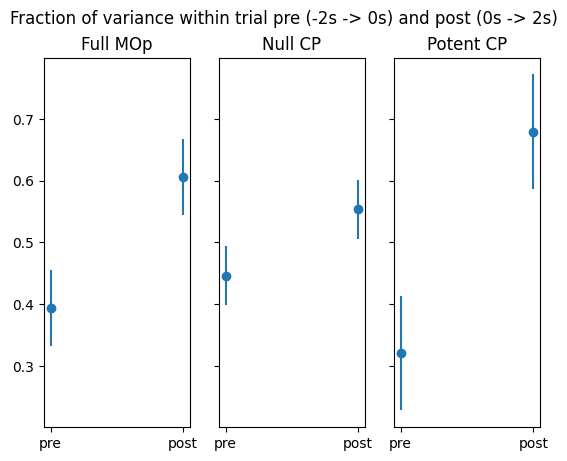

In [20]:
fig, ax = plt.subplots(1, 3, sharey='all')
ax[0].errorbar(['pre', 'post'], [trials_pre_full.mean(), trials_post_full.mean()], yerr=[trials_pre_full.std(), trials_post_full.std()], fmt='o')
ax[0].set_title('Full MOp')
ax[1].errorbar(['pre', 'post'], [trials_pre_null.mean(), trials_post_null.mean()], yerr=[trials_pre_null.std(), trials_post_null.std()], fmt='o')
ax[1].set_title('Null CP')

ax[2].errorbar(['pre', 'post'], [trials_pre_potent.mean(), trials_post_potent.mean()], yerr=[trials_pre_potent.std(), trials_post_potent.std()], fmt='o')
ax[2].set_title('Potent CP')
plt.suptitle('Fraction of variance within trial pre (-2s -> 0s) and post (0s -> 2s)')


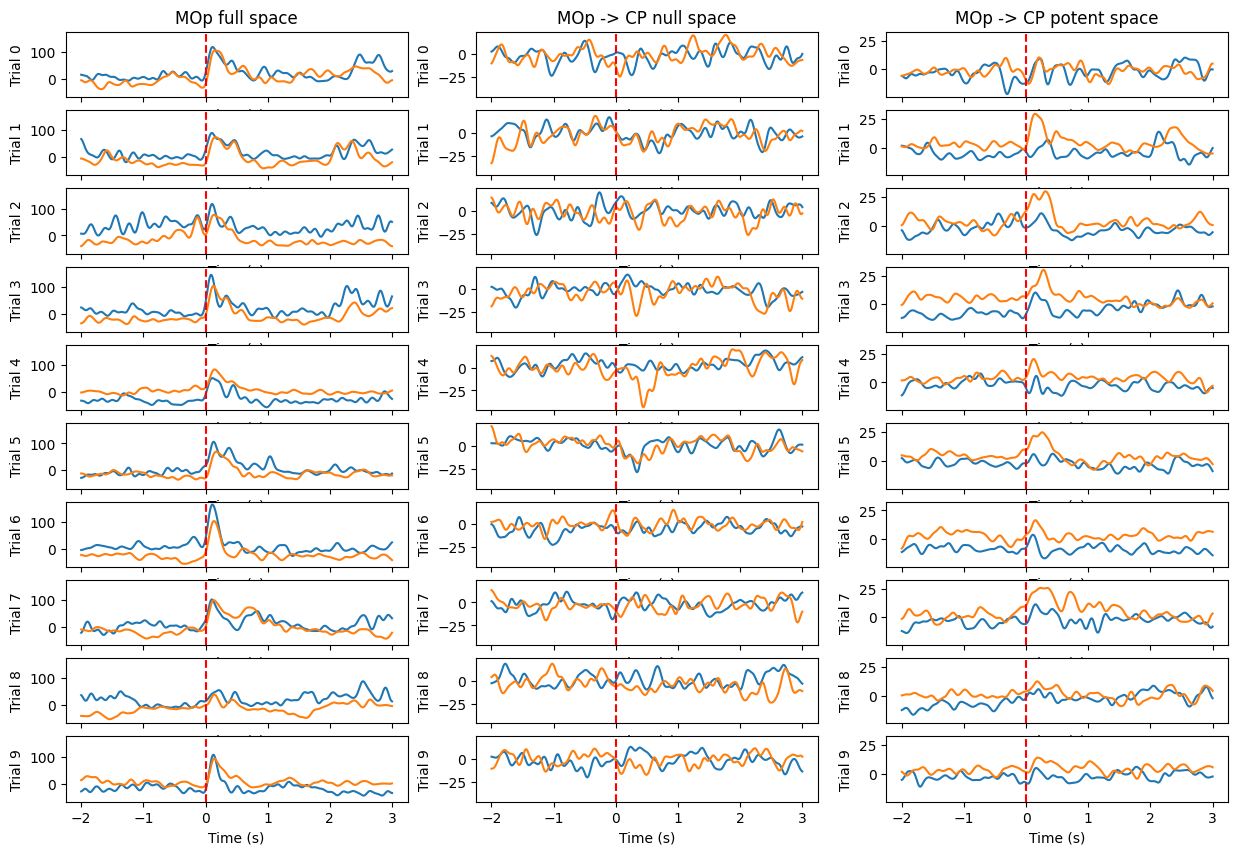

In [245]:
def plot_potent_null_full_example_trials(td, area_a, area_b, n_comp=10, n_trials=10, figsize=(4, 10)):
    fig, axs = plt.subplots(n_trials, 3, figsize=figsize, sharex='all', sharey='col')
    times = np.arange(-2, 3.01, 0.01)
    signal = f'{area_a}_rates_pca'
    for idx, ax in enumerate(axs[:, 0]):
        if idx == 0:
            ax.set_title(f'{area_a} full space')
        ax.plot(times, td[signal].values[idx][:, :n_comp])
        ax.set_ylabel(f'Trial {idx}')
        ax.set_xlabel(f'Time (s)')
        ax.axvline(0, color='red', linestyle='dashed')

    signal = f'{area_a}_rates_pca_null_{area_b}_rates_pca'
    for idx, ax in enumerate(axs[:, 1]):
        if idx == 0:
            ax.set_title(f'{area_a} -> {area_b} null space')
        ax.plot(times, td[signal].values[idx][:, :n_comp])
        ax.set_ylabel(f'Trial {idx}')
        ax.set_xlabel(f'Time (s)')
        ax.axvline(0, color='red', linestyle='dashed')

    signal = f'{area_a}_rates_pca_potent_{area_b}_rates_pca'
    for idx, ax in enumerate(axs[:, 2]):
        if idx == 0:
            ax.set_title(f'{area_a} -> {area_b} potent space')
        ax.plot(times, td[signal].values[idx][:, :n_comp])
        ax.set_ylabel(f'Trial {idx}')
        ax.set_xlabel(f'Time (s)')
        ax.axvline(0, color='red', linestyle='dashed')


    return fig, axs

idx_to_keep = 200
idx = sorted(dstrb_idx[2:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]

fig, axs = plot_potent_null_full_example_trials(perturb_td_shuff_filt,
                                                 'MOp', 'CP', figsize=(15, 10), n_comp=2)
# fig, axs = plot_example_trials(perturb_td_shuff_filt, 'MOp_rates_pca_potent_CP_rates_pca', figsize=(6, 10))

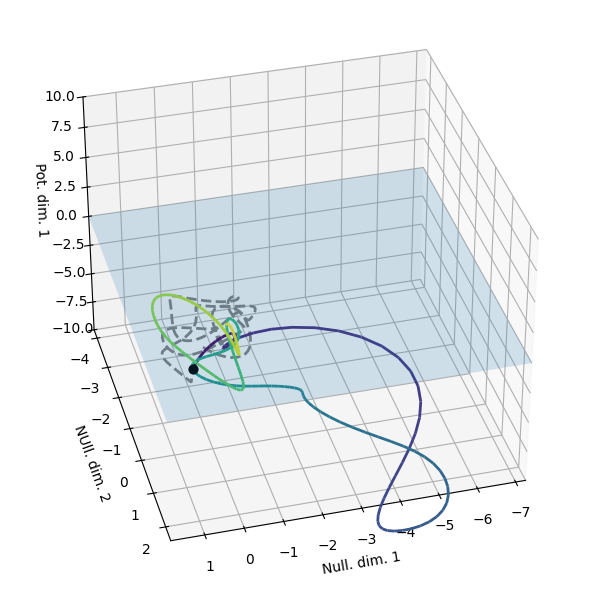

In [198]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import Normalize
# from mpl_toolkits.mplot3d.art3d import Line3DCollection
# from matplotlib.cm import get_cmap


def plot_split_time_trajectory_3d(ax, x, y, z, sol_on, cmap='viridis', lw=2):
    # ---- PRE (gray dashed) ----
    ax.plot(x[:sol_on], y[:sol_on], z[:sol_on],
            linestyle='--', color='gray', linewidth=lw)

    # ---- POST (colour gradient) ----
    x_post = x[sol_on:350]
    y_post = y[sol_on:350]
    z_post = z[sol_on:350]
    T_post = len(x_post)

    pts = np.vstack([x_post, y_post, z_post]).T  # (T_post, 3)
    segs = np.stack([pts[:-1], pts[1:]], axis=1)  # (T_post-1, 2, 3)

    norm = Normalize(0, max(T_post - 2, 1))
    lc = Line3DCollection(segs, cmap=cmap, norm=norm)
    lc.set_array(np.arange(max(T_post - 1, 1)))
    lc.set_linewidth(lw)
    ax.add_collection3d(lc)

    # transition marker
    ax.scatter(x[sol_on], y[sol_on], z[sol_on], color='k', s=40, zorder=10)

    # set limits (3D doesn't autoscale collections reliably)
    ax.set_xlim(np.min(x), np.max(x))
    ax.set_ylim(np.min(y), np.max(y))
    ax.set_zlim(np.min(z), np.max(z))


def add_move_plane(ax, xlim, ylim, z0=0.0, alpha=0.15):
    xx, yy = np.meshgrid(
        np.linspace(xlim[0], xlim[1], 2),
        np.linspace(ylim[0], ylim[1], 2)
    )
    zz = np.full_like(xx, z0)
    ax.plot_surface(xx, yy, zz, alpha=alpha, linewidth=0, shade=False)


# -------------------------
idx_to_keep = 100
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]

sol_on = 180

# Mean across trials
pots  = np.stack(perturb_td_shuff_filt.MOp_rates_pca_potent_VAL_rates_pca.values) # (n_trials, T, n_pot)
nulls = np.stack(perturb_td_shuff_filt.MOp_rates_pca_null_VAL_rates_pca.values)  # (n_trials, T, n_null)

pot_mean  = pots.mean(axis=0)    # (T, n_pot)
null_mean = nulls.mean(axis=0)   # (T, n_null)

# Map to "move plane" + "prep axis"
pot = pot_mean[:, 0]
null1 = null_mean[:, 0]
null2  = null_mean[:, 1]  # NULL on prep axis (vertical)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

plot_split_time_trajectory_3d(ax, null1, null2, pot, sol_on, cmap='viridis', lw=2)

# Add the move plane at z=0 (optional; adjust z0 if your baseline prep is not 0)
add_move_plane(ax, ax.get_xlim(), ax.get_ylim(), z0=0.0, alpha=0.18)

# Labels to match the example
ax.set_xlabel("Null. dim. 1")
ax.set_ylabel("NUll. dim. 2")
ax.set_zlabel("Pot. dim. 1")
ax.set_zlim(-10, 10)
# Camera/view like the example (tweak if needed)
ax.view_init(elev=35, azim=75)

# Cleaner look like the figure
ax.grid(True)
ax.set_box_aspect((1, 1, 0.8))  # aspect ratio; tweak z if too tall/flat

plt.tight_layout()
plt.show()

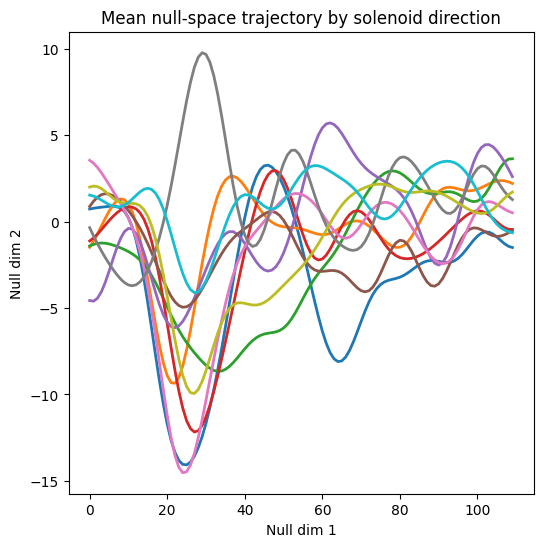

In [176]:
field_null = "MOp_rates_pca_potent_CP_rates_pca"
# field_null = "MOp_rates_pca"
field_null = "MOp_rates_pca_null_CP_rates_pca"

dir_field = "values_Sol_direction"

dirs_to_plot = range(10)  # first 5 directions: 0..4
t_start = 190              # optionally crop
t_stop = 300            # e.g. 350

fig, ax = plt.subplots(figsize=(6, 6))

for d in dirs_to_plot:
    df_d = perturb_td_shuff_filt[perturb_td_shuff_filt[dir_field] == d]
    if len(df_d) == 0:
        continue

    baseline = slice(0, 180)  # e.g. pre-perturb window

    x = x - np.mean(null_mean[baseline, 0])
    y = y - np.mean(null_mean[baseline, 1])

    # (n_trials, T, n_null)
    nulls = np.stack(df_d[field_null].values)

    # mean over trials -> (T, n_null)
    null_mean = nulls.mean(axis=0)

    x = null_mean[t_start:t_stop, 0]  # null dim 1
    y = null_mean[t_start:t_stop, 1]  # null dim 2

    ax.plot(y, label=f"dir {d}", linewidth=2)
    # ax.plot(x label=f"dir {d}", linewidth=2)


ax.set_xlabel("Null dim 1")
ax.set_ylabel("Null dim 2")
ax.set_title("Mean null-space trajectory by solenoid direction")
# ax.set_aspect("equal")
# ax.legend()
# plt.tight_layout()
plt.show()

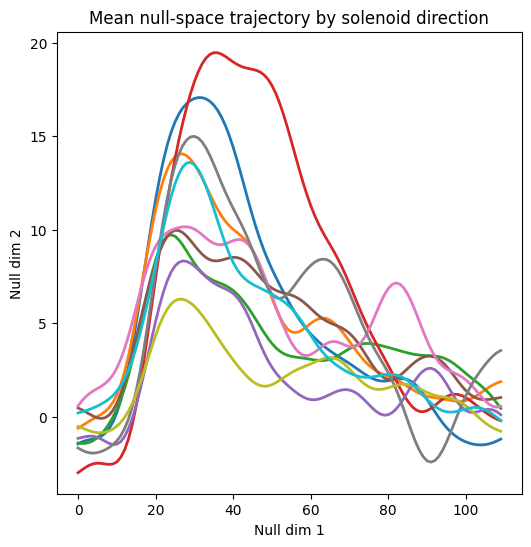

In [178]:
field_null = "MOp_rates_pca_potent_CP_rates_pca"
# field_null = "MOp_rates_pca"
# field_null = "MOp_rates_pca_null_CP_rates_pca"

dir_field = "values_Sol_direction"

dirs_to_plot = range(10)  # first 5 directions: 0..4
t_start = 190              # optionally crop
t_stop = 300            # e.g. 350

fig, ax = plt.subplots(figsize=(6, 6))

for d in dirs_to_plot:
    df_d = perturb_td_shuff_filt[perturb_td_shuff_filt[dir_field] == d]
    if len(df_d) == 0:
        continue

    baseline = slice(0, 180)  # e.g. pre-perturb window

    x = x - np.mean(null_mean[baseline, 0])
    y = y - np.mean(null_mean[baseline, 1])

    # (n_trials, T, n_null)
    nulls = np.stack(df_d[field_null].values)

    # mean over trials -> (T, n_null)
    null_mean = nulls.mean(axis=0)

    x = null_mean[t_start:t_stop, 0]  # null dim 1
    y = null_mean[t_start:t_stop, 1]  # null dim 2

    ax.plot(x, label=f"dir {d}", linewidth=2)
    # ax.plot(x label=f"dir {d}", linewidth=2)


ax.set_xlabel("Null dim 1")
ax.set_ylabel("Null dim 2")
ax.set_title("Mean null-space trajectory by solenoid direction")
# ax.set_aspect("equal")
# ax.legend()
# plt.tight_layout()
plt.show()

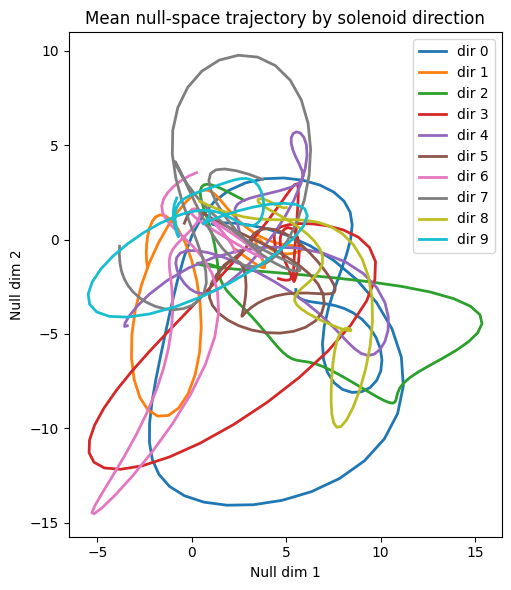

In [164]:
field_null = "MOp_rates_pca_potent_CP_rates_pca"
field_null = "MOp_rates_pca"
field_null = "MOp_rates_pca_null_CP_rates_pca"

dir_field = "values_Sol_direction"

dirs_to_plot = range(10)  # first 5 directions: 0..4
t_start = 190              # optionally crop
t_stop = 275            # e.g. 350

fig, ax = plt.subplots(figsize=(6, 6))

for d in dirs_to_plot:
    df_d = perturb_td_shuff_filt[perturb_td_shuff_filt[dir_field] == d]
    if len(df_d) == 0:
        continue

    baseline = slice(0, 180)  # e.g. pre-perturb window

    x = x - np.mean(null_mean[baseline, 0])
    y = y - np.mean(null_mean[baseline, 1])

    # (n_trials, T, n_null)
    nulls = np.stack(df_d[field_null].values)

    # mean over trials -> (T, n_null)
    null_mean = nulls.mean(axis=0)

    x = null_mean[t_start:t_stop, 0]  # null dim 1
    y = null_mean[t_start:t_stop, 1]  # null dim 2

    ax.plot(x, y, label=f"dir {d}", linewidth=2)

ax.set_xlabel("Null dim 1")
ax.set_ylabel("Null dim 2")
ax.set_title("Mean null-space trajectory by solenoid direction")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

In [150]:
# Mean across trials
pots  = np.stack(tmp_df.MOp_rates_pca_potent_CP_rates_pca.values) # (n_trials, T, n_pot)
nulls = np.stack(tmp_df.MOp_rates_pca_null_CP_rates_pca.values)  # (n_trials, T, n_null)

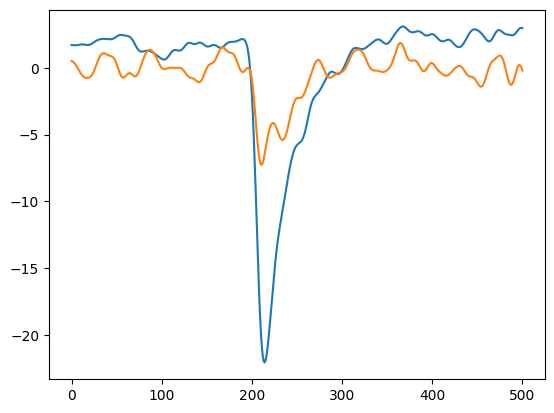

In [199]:
plt.plot(pot_mean[:, 0])
plt.plot(null_mean[:, 0])
# plt.plot(nulls[5, :, 4])

## Inspect trials

In [192]:
len(df_tr)

268

In [246]:
idx_to_keep = 200
idx = sorted(dstrb_idx[:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]

col = 'disturb_score'
tmp_df = perturb_td_shuff_filt.assign(
    _row_sum=perturb_td_shuff_filt[col].apply(lambda x: np.nansum(x))
).sort_values(
    by="_row_sum", ascending=True
).drop(
    columns="_row_sum"
)

In [247]:
tmp_df['power'] = tmp_df.apply(
        lambda row: row['power'][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
        axis=1
    )

tmp_df['bhv_concat'] = tmp_df.apply(
        lambda row: row['bhv_concat'][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
        axis=1
    )

(10, 700)
(10, 700, 3)


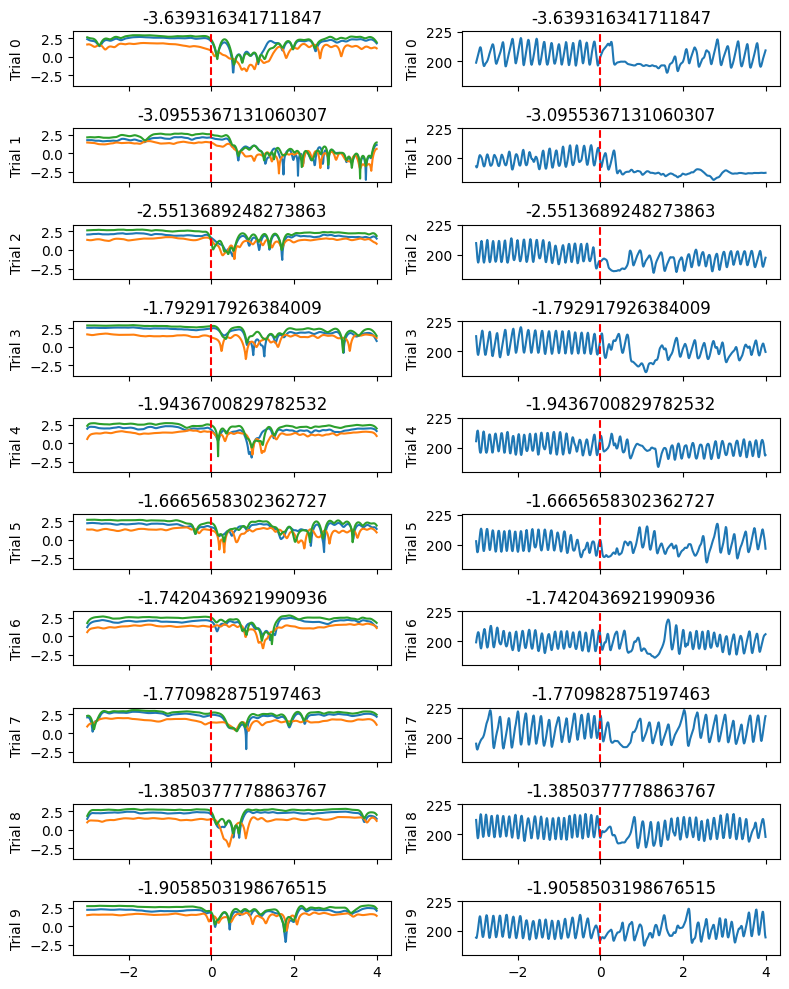

In [248]:
def plot_signal_example_trials(td, signal, n_comp=3, trials=np.arange(10), figsize=(8, 10)):
    fig, axs = plt.subplots(trials.shape[0], 2, figsize=figsize, sharex='all', sharey='col')
    times = np.arange(-3, 4.0, 0.01)
    X = np.stack(td[signal].values)[trials, :, :n_comp]
    kin = np.stack(td['bhv_concat'].values)[trials, :, 2]
    print(kin.shape)
    scores = np.stack(td['disturb_score'].values)[trials, 2]
    print(X.shape)
    for idx, ax in enumerate(axs[:, 0]):
        axs[idx, 0].set_title(scores[idx].mean())
        axs[idx, 0].plot(times, X[idx])
        axs[idx, 0].set_ylabel(f'Trial {idx}')
        # ax.set_xlabel(f'Time (s)')
        axs[idx, 0].axvline(0, color='red', linestyle='dashed')

        axs[idx, 1].set_title(scores[idx].mean())
        axs[idx, 1].plot(times, kin[idx])
        axs[idx, 1].set_ylabel(f'Trial {idx}')
        # ax.set_xlabel(f'Time (s)')
        axs[idx, 1].axvline(0, color='red', linestyle='dashed')

    return fig, axs

plot_signal_example_trials(tmp_df, 'power', trials=np.arange(0, 10))
plt.tight_layout()
plt.show()

## Fraction of motor potent in cp-potent

In [130]:
df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
# perturb_td_shuff = dt.add_bhv(perturb_td_shuff)

In [131]:
origin_signal = 'MOp_rates_pca'
target_signal = 'bhv'
# rank = 178

window_emb = (0, 500)
motor_emb = subspaces.compute_embedding(
        perturb_td_shuff,
        origin_signal,
        target_signal,
        (window_emb[0], window_emb[-1]),
        LinearRegression(),
        null=False,
    )

cp_emb = subspaces.compute_embedding(
    perturb_td_shuff,
    origin_signal,
    'CP_rates_pca',
    (window_emb[0], window_emb[-1]),
    subspaces.ReducedRankCommSubspace(rank=30),
    null=False,
)

In [143]:
P = motor_emb @ motor_emb.T
# idx_to_keep = 
idx = sorted(dstrb_idx[30:100])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]


perturb_td_shuff_filt = subspaces.project_signal(perturb_td_shuff_filt, P, 'MOp_rates_pca', 'MOp_rates_pca_potent_bhv')

In [144]:
perturb_td_shuff_filt[f'MOp_rates_pca_potent_bhv_frac_in_CP_potent'] = perturb_td_shuff_filt['MOp_rates_pca_potent_bhv'].apply(
    lambda X: subspaces.frac_in_subspace(np.asarray(X), cp_emb)
)

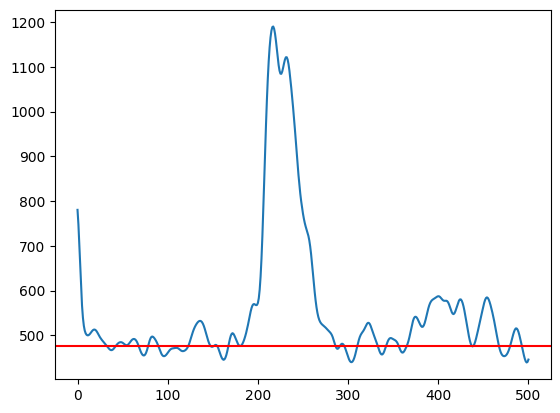

In [145]:
# var_arr = subspaces.variance_in_subspace_df(perturb_td_shuff_filt,
#                                             'MOp_rates_pca', cp_emb)
# plt.plot(var_arr)

var_arr = subspaces.variance_in_subspace_df(perturb_td_shuff_filt,
                                            'MOp_rates_pca_potent_bhv', cp_emb)
fig, ax = plt.subplots()
ax.plot(var_arr)
ax.axhline(475, color='r')


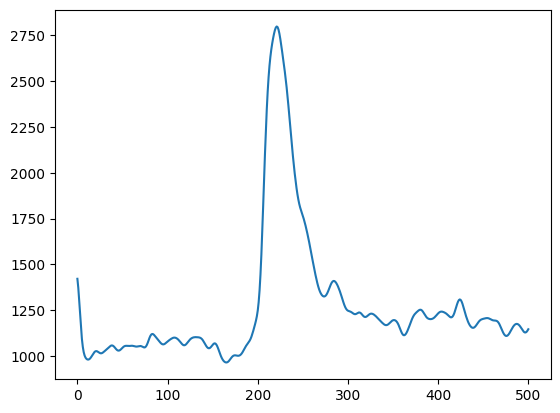

In [36]:
frac_arr = np.stack(perturb_td_shuff_filt.MOp_rates_pca_potent_bhv_frac_in_CP_potent.values)

# Refactored Semedo ridge

In [ ]:
df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

arrs = np.stack(perturb_td_shuff['MOp_rates_pca'].values)[:, :, :30]
perturb_td_shuff['MOp_rates_pca'] = [arr for arr in arrs]

signal_x = 'MOp_rates_pca'
signal_y = 'VAL_rates_pca'
target_rank = 50
fit_rank=True
rank = 5

arr_original = perturb_td_shuff[signal_y]

arrs = dt.shift_time_no_wrap(np.stack(perturb_td_shuff[signal_y].values), shift=-1)
perturb_td_shuff[signal_y] = [arr for arr in arrs]

r2, opt_rank = subspaces.cross_val_semedo_rrr_td(perturb_td_shuff, signal_x, signal_y, target_rank, rank=rank, fit_rank=fit_rank)
comm_model = subspaces.ReducedRankCommSubspace(rank=opt_rank)
# comm_model = decode.ReducedRankRegressorBence(rank=opt_rank)
emb_null, var_null_init = subspaces.compute_embedding_on_td(perturb_td_shuff, signal_x, signal_y, comm_model, null=True)
emb_potent, var_potent = subspaces.compute_embedding_on_td(perturb_td_shuff, signal_x, signal_y, comm_model, null=False)
perturb_td_shuff = subspaces.project_signal(perturb_td_shuff, emb_null, signal_x, f'{signal_x}_null_{signal_y}')  # potent
perturb_td_shuff = subspaces.project_signal(perturb_td_shuff, emb_potent, signal_x, f'{signal_x}_potent_{signal_y}')  # null
print(r2.mean(), opt_rank)

# Remove from null
n_iter = 1
signal_x = f'{signal_x}_null_{signal_y}'
for i in range(n_iter):
    r2, opt_rank = subspaces.cross_val_semedo_rrr_td(perturb_td_shuff, signal_x, signal_y, target_rank, rank=opt_rank, fit_rank=False)
    print(r2.mean(), opt_rank)
    if (r2.mean() - r2.std()) > 0:
        pass
    else:
        print(f'Iteration number: {i+1}. R2 below 0, breaking')
        break
    comm_model = subspaces.ReducedRankCommSubspace(rank=opt_rank)
    emb_null, var_null = subspaces.compute_embedding_on_td(perturb_td_shuff, signal_x, signal_y, comm_model, null=True)
    perturb_td_shuff = subspaces.project_signal(perturb_td_shuff, emb_null, signal_x, signal_x)  # potent




100%|██████████| 14/14 [00:01<00:00,  8.63it/s]


0.18997525656658848 8
0.06837499255492673 8


In [160]:
subspaces.variance_in_subspace(
    np.concatenate(perturb_td_shuff.MOp_rates_pca.values),
    np.eye(30)
)

5984.282577825661

In [161]:
var_null_init

4862.288366856136

In [162]:
var_null

2963.12712480953

In [163]:
var_potent

1121.994210969526

In [76]:
var_potent + var_null_init

5984.282577825661

In [52]:
mempool = cp.get_default_memory_pool()
pinned_mempool = cp.get_default_pinned_memory_pool()

# Clear the memory pool.
mempool.free_all_blocks()
pinned_mempool.free_all_blocks()

In [33]:
var_potent

421.19696692788995

In [181]:
area_a ='MOp'
area_b = 'CP'
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

idx_to_keep = 200
window = 20
shuffle = True
opt_alpha = True
step_bin = 2
keypoint = 'bhv'

idx = sorted(dstrb_idx[2:idx_to_keep])
perturb_td_shuff_filt = perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
perturb_td_shuff_filt_ord = (
    perturb_td_shuff_filt
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)


scores_perturb, times, _ = decode_perturb_score_potent_null(perturb_td_shuff_filt_ord, area_a, area_b, 
                                                     window=window,
                                                     k=5,
                                                     shuffle=shuffle,
                                                     opt_alpha=opt_alpha,
                                                    #  scorer=vw_r2_scorer,
                                                    # rnd=40
                                                     )
# scores_kin, times_kin = decode_kinematics_potent_null(perturb_td_shuff_filt, area_a, area_b,
#                                                      keypoint=keypoint, 
#                                                      window=20,
#                                                      k=5,
#                                                      opt_alpha=opt_alpha,
#                                                      step_bin=step_bin,
#                                                      scorer=vw_r2_scorer
#                                                      )                                                     
scores_dir, times, chance = decode_sol_dir_potent_null(perturb_td_shuff_filt_ord, area_a, area_b, 
                                                    window=window,
                                                     k=5,
                                                     shuffle=shuffle,
                                                     )

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:03<00:00, 13.49it/s]


Alpha param 1000000.000


100%|██████████| 50/50 [00:02<00:00, 19.69it/s]


Alpha param 596362.332


100%|██████████| 50/50 [00:01<00:00, 25.05it/s]


Alpha param 1000000.000


100%|██████████| 241/241 [00:01<00:00, 124.37it/s]


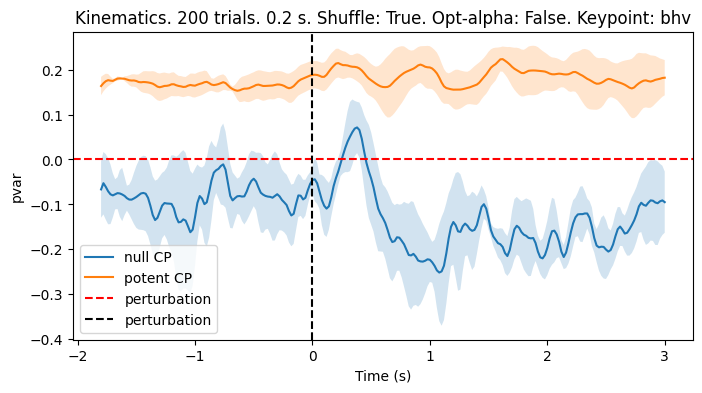

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
# vizutils.shaded_errorbar(ax, times-2, scores_kin[0], label=f'full {area_a}')
vizutils.shaded_errorbar(ax, times_kin-2, scores_kin[0], label=f'null {area_b}')
vizutils.shaded_errorbar(ax, times_kin-2, scores_kin[1], label=f'potent {area_b}')

ax.axhline(0, color='r', linestyle='dashed', label='perturbation')

ax.axvline(0, color='k', linestyle='dashed', label='perturbation')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pvar')
ax.set_title(f'Kinematics. {idx_to_keep} trials. {20 * 0.01} s. ' 
             f'Shuffle: {shuffle}. Opt-alpha: {opt_alpha}. Keypoint: {keypoint}')
ax.legend()
# ax.set_ylim(-0.1, 0.55)
# ax.set_xlim(-1, 1.25)

Text(0.5, 0.98, '200 trials. 0.2 s. Shuffle: True. Opt-alpha: True')

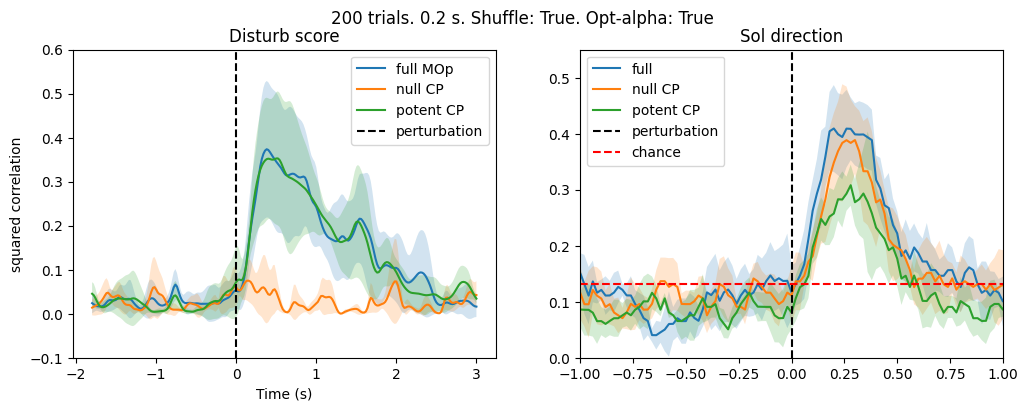

In [182]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey='none')
vizutils.shaded_errorbar(ax[0], times-2, scores_perturb[0], label=f'full {area_a}')
vizutils.shaded_errorbar(ax[0], times-2, scores_perturb[1], label=f'null {area_b}')
vizutils.shaded_errorbar(ax[0], times-2, scores_perturb[2], label=f'potent {area_b}')
# vizutils.shaded_errorbar(ax[0], times-2, scores_perturb[3], label=f'lower bound')

ax[0].axvline(0, color='k', linestyle='dashed', label='perturbation')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('squared correlation')
ax[0].set_title(f'Disturb score')
ax[0].legend()
ax[0].set_ylim(-0.1, 0.6)


vizutils.shaded_errorbar(ax[1], times-2, scores_dir[0], label=f'full')

vizutils.shaded_errorbar(ax[1], times-2, scores_dir[1], label=f'null {area_b}')
vizutils.shaded_errorbar(ax[1], times-2, scores_dir[2], label=f'potent {area_b}')


ax[1].set_title(f'Sol direction')
ax[1].axvline(0, color='k', linestyle='dashed', label='perturbation')
ax[1].axhline(chance, color='r', linestyle='dashed', label='chance')

ax[1].legend()
ax[1].set_xlim(-1, 1)
ax[1].set_ylim(0, 0.55)

plt.suptitle(f'{idx_to_keep} trials. {window * 0.01} s. ' 
             f'Shuffle: {shuffle}. Opt-alpha: {opt_alpha}')

# More exploration

In [8]:

# ── Setup ──────────────────────────────────────────────────────────────────────
df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start=-200, rel_end=300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

signal_x = 'MOp_rates_pca'
signal_y = 'CP_rates_pca'
target_rank = 30
n_iter = 9

# Shift CP by -2 bins (~20 ms ahead)
arrs = dt.shift_time_no_wrap(np.stack(perturb_td_shuff[signal_y].values), shift=-2)
perturb_td_shuff[signal_y] = [arr for arr in arrs]

# ── Initial fit ────────────────────────────────────────────────────────────────
r2_history    = []   # cross-val R² arrays (iter 0 = initial fit)
rank_history  = []   # opt_rank per iter
var_null_history    = []   # null VAF per iter
var_potent_history  = []   # potent VAF (iter 0 only)

r2, opt_rank = subspaces.cross_val_semedo_rrr_td(
    perturb_td_shuff, signal_x, signal_y, target_rank, rank=target_rank, fit_rank=True
)
r2_history.append(r2)
rank_history.append(opt_rank)
print(f'[iter 0]  R2={r2.mean():.4f}±{r2.std():.4f}  rank={opt_rank}')

comm_model = subspaces.ReducedRankCommSubspace(rank=opt_rank)
emb_null,   var_null   = subspaces.compute_embedding_on_td(perturb_td_shuff, signal_x, signal_y, comm_model, null=True)
emb_potent, var_potent = subspaces.compute_embedding_on_td(perturb_td_shuff, signal_x, signal_y, comm_model, null=False)
var_null_history.append(var_null)
var_potent_history.append(var_potent)

null_col   = f'{signal_x}_null_{signal_y}'
potent_col = f'{signal_x}_potent_{signal_y}'
perturb_td_shuff = subspaces.project_signal(perturb_td_shuff, emb_null,   signal_x, null_col)
perturb_td_shuff = subspaces.project_signal(perturb_td_shuff, emb_potent, signal_x, potent_col)

# ── Iterative null refinement ──────────────────────────────────────────────────
cur_signal_x = null_col
n_stopped = n_iter
for i in range(n_iter):
    r2, opt_rank = subspaces.cross_val_semedo_rrr_td(
        perturb_td_shuff, cur_signal_x, signal_y, target_rank, rank=opt_rank, fit_rank=False
    )
    r2_history.append(r2)
    rank_history.append(opt_rank)
    print(f'[iter {i+1}]  R2={r2.mean():.4f}±{r2.std():.4f}  rank={opt_rank}')

    if (r2.mean() - r2.std()) <= 0:
        print(f'  → R2 ≤ 0 at iteration {i+1}, stopping.')
        n_stopped = i + 1
        break

    comm_model = subspaces.ReducedRankCommSubspace(rank=opt_rank)
    emb_null, var_null = subspaces.compute_embedding_on_td(
        perturb_td_shuff, cur_signal_x, signal_y, comm_model, null=True
    )
    var_null_history.append(var_null)
    perturb_td_shuff = subspaces.project_signal(perturb_td_shuff, emb_null, cur_signal_x, cur_signal_x)

print(f'\nDone. Converged in {n_stopped} null-refinement iteration(s).')


100%|██████████| 19/19 [00:06<00:00,  2.80it/s]


[iter 0]  R2=0.2105±0.0131  rank=8
[iter 1]  R2=0.1872±0.0137  rank=8
[iter 2]  R2=0.1593±0.0143  rank=8
[iter 3]  R2=0.1312±0.0151  rank=8
[iter 4]  R2=0.1056±0.0148  rank=8
[iter 5]  R2=0.0743±0.0133  rank=8
[iter 6]  R2=0.0459±0.0106  rank=8
[iter 7]  R2=0.0232±0.0078  rank=8
[iter 8]  R2=0.0096±0.0060  rank=8
[iter 9]  R2=0.0010±0.0048  rank=8
  → R2 ≤ 0 at iteration 9, stopping.

Done. Converged in 9 null-refinement iteration(s).


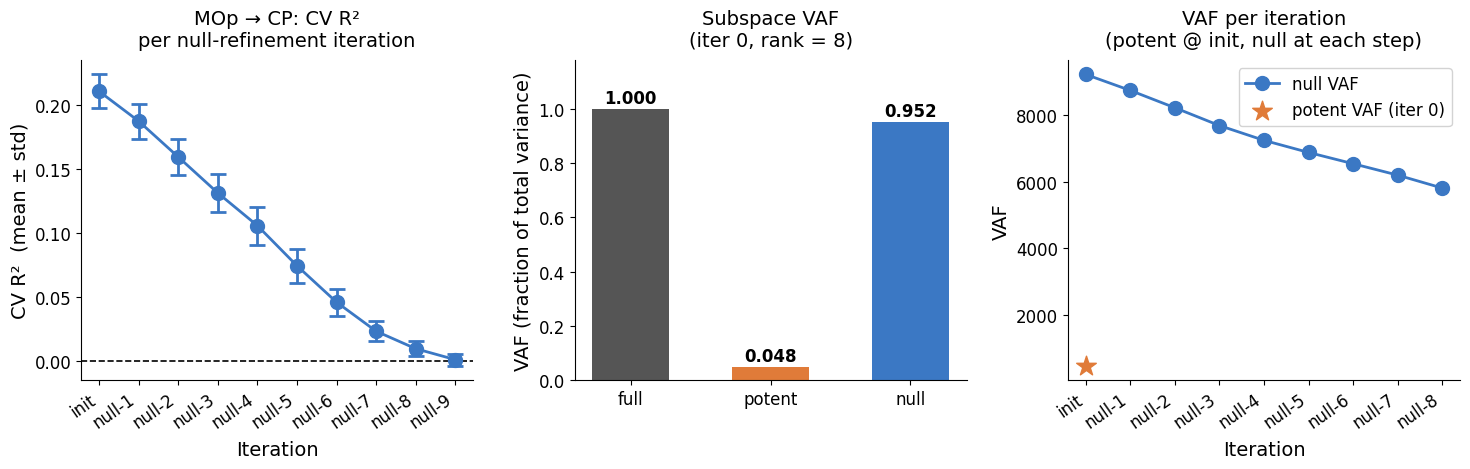

In [26]:

# ── Diagnostics: R², VAF bar, and VAF across iterations ───────────────────────
n_iters_run = len(r2_history)
iter_labels = ['init'] + [f'null-{i}' for i in range(1, n_iters_run)]

r2_means = np.array([r.mean() for r in r2_history])
r2_stds  = np.array([r.std()  for r in r2_history])

X_full    = np.concatenate(perturb_td_shuff[signal_x].values, axis=0)
total_var = np.var(X_full, axis=0).sum()

vaf_full   = 1.0
vaf_potent = var_potent_history[0] / total_var if total_var > 0 else var_potent_history[0]
vaf_null   = var_null_history[0]   / total_var if total_var > 0 else var_null_history[0]

FS       = 14
FS_TICK  = 12
FS_ANNOT = 12
LW       = 2.0
MS       = 10

C_FULL   = SUBSPACE_COLORS['full']    # '#555555'
C_POTENT = SUBSPACE_COLORS['potent']  # '#E07B39'
C_NULL   = SUBSPACE_COLORS['null']    # '#3B78C4'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: cross-val R² per iteration ──────────────────────────────────────
ax = axes[0]
ax.errorbar(range(n_iters_run), r2_means, yerr=r2_stds,
            marker='o', markersize=MS, linewidth=LW, capsize=6,
            capthick=LW, elinewidth=LW, color=C_NULL)
ax.axhline(0, color='k', linewidth=1.2, linestyle='--')
ax.set_xticks(range(n_iters_run))
ax.set_xticklabels(iter_labels, rotation=35, ha='right', fontsize=FS_TICK)
ax.tick_params(axis='y', labelsize=FS_TICK)
ax.set_xlabel('Iteration', fontsize=FS, labelpad=6)
ax.set_ylabel('CV R²  (mean ± std)', fontsize=FS)
ax.set_title(f'MOp → CP: CV R²\nper null-refinement iteration', fontsize=FS, pad=10)
sns.despine(ax=ax)

# ── Panel 2: bar — VAF of full / potent / null ────────────────────────────────
ax = axes[1]
bar_labels = ['full', 'potent', 'null']
bar_vals   = [vaf_full, vaf_potent, vaf_null]
bar_colors = [C_FULL, C_POTENT, C_NULL]
bars = ax.bar(bar_labels, bar_vals, color=bar_colors,
              edgecolor='none', linewidth=0, width=0.55)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=FS_ANNOT, fontweight='bold')
ax.set_ylabel('VAF (fraction of total variance)', fontsize=FS)
ax.set_title(f'Subspace VAF\n(iter 0, rank = {rank_history[0]})', fontsize=FS, pad=10)
ax.tick_params(axis='both', labelsize=FS_TICK)
ax.set_ylim(0, max(bar_vals) * 1.18)
sns.despine(ax=ax)

# ── Panel 3: VAF convergence across null-refinement steps ────────────────────
ax = axes[2]
null_vaf_arr = np.array(var_null_history)
ax.plot(range(len(null_vaf_arr)), null_vaf_arr,
        marker='o', markersize=MS, linewidth=LW, color=C_NULL, label='null VAF')
ax.scatter([0], [var_potent_history[0]],
           marker='*', s=220, color=C_POTENT, zorder=5, label='potent VAF (iter 0)')
ax.set_xticks(range(len(null_vaf_arr)))
ax.set_xticklabels(iter_labels[:len(null_vaf_arr)], rotation=35, ha='right', fontsize=FS_TICK)
ax.tick_params(axis='y', labelsize=FS_TICK)
ax.set_xlabel('Iteration', fontsize=FS, labelpad=6)
ax.set_ylabel('VAF', fontsize=FS)
ax.set_title('VAF per iteration\n(potent @ init, null at each step)', fontsize=FS, pad=10)
ax.legend(fontsize=FS_TICK, framealpha=0.85, edgecolor='#CCCCCC')
sns.despine(ax=ax)

plt.tight_layout(pad=1.8)
plt.show()


In [14]:

# ── Helper: ridge alpha selection ─────────────────────────────────────────────
def _naive_opt_alpha(alpha_range, cv_scores):
    means = [np.mean(sc) for sc in cv_scores]
    return alpha_range[np.argmax(means)]


def _opt_ridge_alpha(X, y, n_alpha=50, cv=KFold(5), scorer=decode.get_custom_scorer()):
    candidate_alphas = np.logspace(-5, 5, n_alpha)
    cv_scores = [
        cross_val_score(Ridge(alpha, solver='lsqr'), X, y, cv=cv, scoring=scorer)
        for alpha in candidate_alphas
    ]
    return _naive_opt_alpha(candidate_alphas, cv_scores)


def majority_class_chance_levels_from_counts(counts):
    return counts.max() / counts.sum()


# ── Decoding: disturbance score ────────────────────────────────────────────────
def decode_perturb_score_potent_null(
    td, area_origin, area_target,
    k=5, window=50, shuffle=False, opt_alpha=True,
    scorer=decode.get_custom_scorer(),
):
    rnd = 42 if shuffle else None
    y = td.disturb_sum.values
    labels = [
        f'{area_origin}_rates_pca',
        f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
    ]
    scores_list, y_preds_list = [], []
    for label in labels:
        X = np.stack(td[label].values)
        alpha = (
            _opt_ridge_alpha(X.reshape(X.shape[0], -1), y,
                             cv=KFold(shuffle=shuffle, random_state=rnd, n_splits=k))
            if opt_alpha else 1.0
        )
        scores, times, y_preds = decode.decoding_moving_window_no_time_concat(
            Ridge(alpha, solver='lsqr'), X, y,
            cv=KFold(shuffle=shuffle, random_state=rnd, n_splits=k),
            scorer=scorer, window_length_bin=window, step_bin=2,
        )
        scores_list.append(scores)
        y_preds_list.append(y_preds)
    return scores_list, times, y_preds_list


# ── Decoding: solenoid direction ───────────────────────────────────────────────
def decode_sol_dir_potent_null(
    td, area_origin, area_target,
    k=5, window=50, shuffle=False,
):
    rnd = 42 if shuffle else None
    y = np.array(td.values_Sol_direction.values.tolist())
    classes, counts = np.unique(y, return_counts=True)
    chance = majority_class_chance_levels_from_counts(counts)
    labels = [
        f'{area_origin}_rates_pca',
        f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
    ]
    scores_list = []
    for label in labels:
        X = np.stack(td[label].values)
        scores, times = decode.moving_window_decoding(
            X, y,
            cv=StratifiedKFold(n_splits=k, shuffle=shuffle, random_state=rnd),
            window_length_bin=window, step_bin=2,
        )
        scores_list.append(scores)
    return scores_list, times, chance


In [15]:

# ── Run decoding: MOp → CP ─────────────────────────────────────────────────────
area_origin = 'MOp'
area_target = 'CP'
idx_to_keep = 200
window      = 50       # bins (× 10 ms = 0.5 s window)
shuffle     = True
opt_alpha   = True

idx = sorted(dstrb_idx[2:idx_to_keep])
td_dec = (
    perturb_td_shuff[perturb_td_shuff['index'].isin(idx)]
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)

print('Running disturbance-score decoder…')
scores_perturb, times, _ = decode_perturb_score_potent_null(
    td_dec, area_origin, area_target,
    k=5, window=window, shuffle=shuffle, opt_alpha=opt_alpha,
)

print('Running solenoid-direction decoder…')
scores_dir, times_dir, chance = decode_sol_dir_potent_null(
    td_dec, area_origin, area_target,
    k=5, window=window, shuffle=shuffle,
)
print('Done.')


Running disturbance-score decoder…


100%|██████████| 226/226 [00:02<00:00, 111.11it/s]


Running solenoid-direction decoder…


100%|██████████| 226/226 [00:02<00:00, 106.61it/s]

Done.


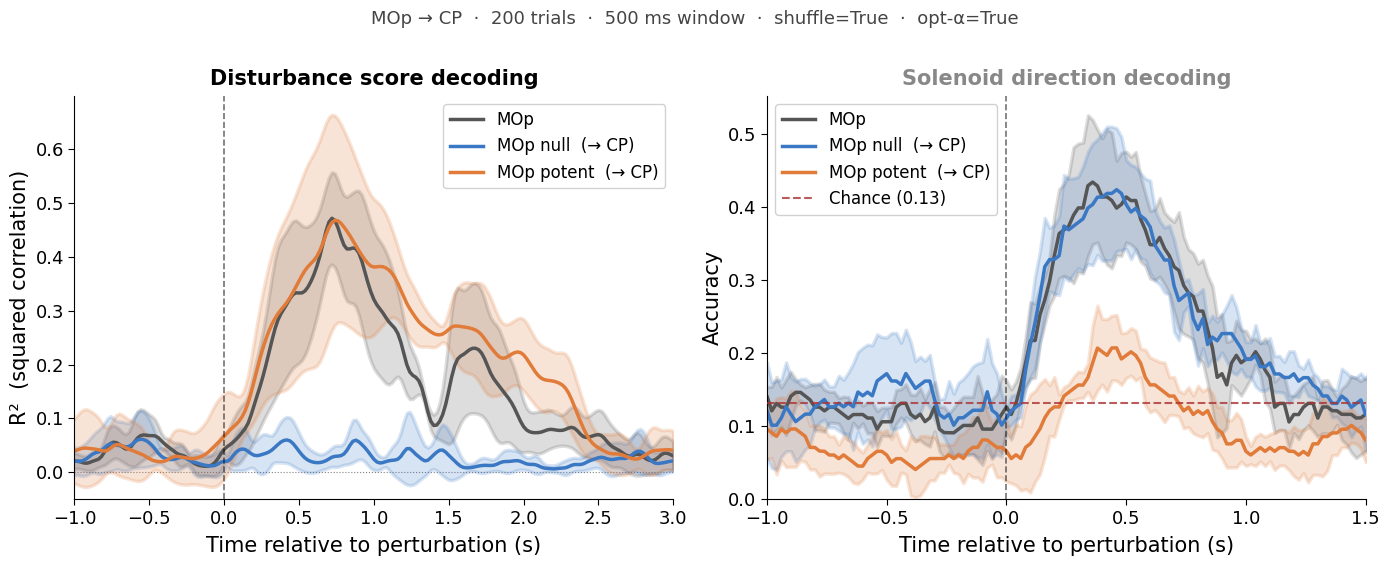

In [22]:

# ── Semantic color palette — area-agnostic, reuse for any origin → target pair ─
# potent (orange) = communicating dims; null (blue) = locally retained; full (gray) = baseline
SUBSPACE_COLORS = {
    'full'   : '#555555',   # charcoal gray  — undecomposed signal
    'potent' : '#E07B39',   # muted orange   — CP-communicating dimensions
    'null'   : '#3B78C4',   # steel blue     — locally retained (non-communicating)
}

# ── Presentation plot: disturbance score & solenoid direction ──────────────────
FS      = 15
FS_TICK = 13
FS_LEG  = 12
LW      = 2.5
ALPHA   = 0.20

# times is already in seconds; onset is 2 s into the epoch (200 bins × 10 ms)
t     = times     - 2.0
t_dir = times_dir - 2.0

LABELS = {
    'full'   : f'{area_origin}',
    'potent' : f'{area_origin} potent  (→ {area_target})',
    'null'   : f'{area_origin} null  (→ {area_target})',
}

def _style_ax(ax):
    sns.despine(ax=ax)
    ax.tick_params(labelsize=FS_TICK, length=4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')

# ── Panel 1: disturbance score ─────────────────────────────────────────────────
ax = axes[0]
for scores, key in zip(scores_perturb, ['full', 'null', 'potent']):
    vizutils.shaded_errorbar(ax, t, scores,
                             label=LABELS[key], color=SUBSPACE_COLORS[key],
                             lw=LW, alpha_err=ALPHA)
ax.axvline(0, color='k', linewidth=1.2, linestyle='--', zorder=5, alpha=0.55)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':', zorder=0)
ax.set_xlabel('Time relative to perturbation (s)', fontsize=FS, labelpad=6)
ax.set_ylabel('R²  (squared correlation)', fontsize=FS)
ax.set_title('Disturbance score decoding', fontsize=FS, pad=8, fontweight='bold')
ax.set_xlim(-1.0, 3.0)
ax.set_ylim(-0.05, None)
ax.legend(fontsize=FS_LEG, framealpha=0.9, edgecolor='#CCCCCC')
_style_ax(ax)

# ── Panel 2: solenoid direction ────────────────────────────────────────────────
ax = axes[1]
for scores, key in zip(scores_dir, ['full', 'null', 'potent']):
    vizutils.shaded_errorbar(ax, t_dir, scores,
                             label=LABELS[key], color=SUBSPACE_COLORS[key],
                             lw=LW, alpha_err=ALPHA)
ax.axhline(chance, color='#AA3333', linewidth=1.5, linestyle='--',
           label=f'Chance ({chance:.2f})', zorder=5, alpha=0.8)
ax.axvline(0, color='k', linewidth=1.2, linestyle='--', zorder=5, alpha=0.55)
ax.set_xlabel('Time relative to perturbation (s)', fontsize=FS, labelpad=6)
ax.set_ylabel('Accuracy', fontsize=FS)
ax.set_title('Solenoid direction decoding', fontsize=FS, pad=8, fontweight='bold', color='#888888')
ax.set_xlim(-1.0, 1.5)
ax.set_ylim(0, None)
ax.legend(fontsize=FS_LEG, framealpha=0.9, edgecolor='#CCCCCC')
_style_ax(ax)

plt.suptitle(
    f'{area_origin} → {area_target}  ·  {idx_to_keep} trials'
    f'  ·  {window * 0.01 * 1000:.0f} ms window  ·  shuffle={shuffle}  ·  opt-α={opt_alpha}',
    fontsize=FS - 2, y=1.02, color='#444444',
)
plt.tight_layout()
plt.show()


## MOp → all areas: full loop

In [15]:
target_lag_dict = {
    'MOp': {
        'bhv': 1,
        'MOp': None,
        'SSp': -1,
        'CP': -2,
        'VAL': -4
    },
    'SSp': {
        'bhv': None,
        'MOp': 1,
        'SSp': None,
        'CP': -1,
        'VAL': -4
    },
    'CP': {
        'bhv': None,
        'MOp': 2,
        'SSp': 1,
        'CP': None,
        'VAL': -1
    },
    'VAL': {
        'bhv': None,
        'MOp': 4,
        'SSp': 2,
        'CP': 1,
        'VAL': None
    }
}

target_ranks_dict = {
    'MOp': 30,
    'CP': 30,
    'VAL': 50,
    'SSp': 20
}

# ── MOp → all areas: Semedo decomposition ─────────────────────────────────────
area_origin  = 'MOp'

TARGET_AREAS = [
    t for t in target_lag_dict[area_origin]
    if t != 'bhv' and t != area_origin
]

n_iter      = 9
idx_to_keep = 200

semedo_results = {}   # keyed by area_target

for area_target in TARGET_AREAS:
    signal_x = f'{area_origin}_rates_pca'
    signal_y = f'{area_target}_rates_pca'

    if signal_y not in perturb_td.columns:
        print(f'[{area_target}] skipped — {signal_y} not found in data')
        continue

    shift_bins  = target_lag_dict[area_origin][area_target]
    target_rank = target_ranks_dict.get(area_target, 30)

    print(f'\n{"─"*60}')
    print(f'  {area_origin} → {area_target}  (lag={shift_bins}, target_rank={target_rank})')
    print(f'{"─"*60}')

    # Fresh shuffled table for this pair
    td_pair = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
    if shift_bins is not None:
        arrs = dt.shift_time_no_wrap(np.stack(td_pair[signal_y].values), shift=shift_bins)
        td_pair[signal_y] = [arr for arr in arrs]

    # ── Initial fit ────────────────────────────────────────────────────────────
    r2_hist, rank_hist, var_null_hist, var_potent_hist = [], [], [], []

    r2, opt_rank = subspaces.cross_val_semedo_rrr_td(
        td_pair, signal_x, signal_y, target_rank, rank=target_rank, fit_rank=True
    )
    r2_hist.append(r2); rank_hist.append(opt_rank)
    print(f'  [iter 0]  R²={r2.mean():.4f}±{r2.std():.4f}  rank={opt_rank}')

    comm_model     = subspaces.ReducedRankCommSubspace(rank=opt_rank)
    emb_null,   v_null   = subspaces.compute_embedding_on_td(td_pair, signal_x, signal_y, comm_model, null=True)
    emb_potent, v_potent = subspaces.compute_embedding_on_td(td_pair, signal_x, signal_y, comm_model, null=False)
    var_null_hist.append(v_null); var_potent_hist.append(v_potent)

    null_col   = f'{signal_x}_null_{signal_y}'
    potent_col = f'{signal_x}_potent_{signal_y}'
    td_pair = subspaces.project_signal(td_pair, emb_null,   signal_x, null_col)
    td_pair = subspaces.project_signal(td_pair, emb_potent, signal_x, potent_col)

    # ── Iterative null refinement ──────────────────────────────────────────────
    cur_signal_x = null_col
    for i in range(n_iter):
        r2, opt_rank = subspaces.cross_val_semedo_rrr_td(
            td_pair, cur_signal_x, signal_y, target_rank, rank=opt_rank, fit_rank=False
        )
        r2_hist.append(r2); rank_hist.append(opt_rank)
        print(f'  [iter {i+1}]  R²={r2.mean():.4f}±{r2.std():.4f}  rank={opt_rank}')

        if (r2.mean() - r2.std()) <= 0:
            print(f'  → R² ≤ 0 at iteration {i+1}, stopping.')
            break

        comm_model = subspaces.ReducedRankCommSubspace(rank=opt_rank)
        emb_null, v_null = subspaces.compute_embedding_on_td(
            td_pair, cur_signal_x, signal_y, comm_model, null=True
        )
        var_null_hist.append(v_null)
        td_pair = subspaces.project_signal(td_pair, emb_null, cur_signal_x, cur_signal_x)

    # ── Compute VAF fractions ──────────────────────────────────────────────────
    X_full    = np.concatenate(td_pair[signal_x].values, axis=0)
    total_var = np.var(X_full, axis=0).sum()

    # td_pair now contains null_col and potent_col as projected activity columns
    semedo_results[area_target] = dict(
        null_col           = null_col,
        potent_col         = potent_col,
        opt_rank           = rank_hist[0],
        shift_bins         = shift_bins,
        vaf_potent         = var_potent_hist[0] / total_var if total_var > 0 else var_potent_hist[0],
        vaf_null           = var_null_hist[0]   / total_var if total_var > 0 else var_null_hist[0],
        r2_history         = r2_hist,
        rank_history       = rank_hist,
        var_null_history   = var_null_hist,
        var_potent_history = var_potent_hist,
        td_pair            = td_pair,
    )
    print(f'  ✓ Done {area_origin} → {area_target}')

print(f'\nAll done. semedo_results keys: {list(semedo_results.keys())}')



────────────────────────────────────────────────────────────
  MOp → SSp  (lag=-1, target_rank=20)
────────────────────────────────────────────────────────────


100%|██████████| 19/19 [00:05<00:00,  3.54it/s]


  [iter 0]  R²=0.3118±0.0390  rank=6
  [iter 1]  R²=0.2761±0.0378  rank=6
  [iter 2]  R²=0.2346±0.0379  rank=6
  [iter 3]  R²=0.1875±0.0434  rank=6
  [iter 4]  R²=0.1447±0.0446  rank=6
  [iter 5]  R²=0.0971±0.0421  rank=6
  [iter 6]  R²=0.0513±0.0381  rank=6
  [iter 7]  R²=0.0144±0.0279  rank=6
  → R² ≤ 0 at iteration 7, stopping.
  ✓ Done MOp → SSp

────────────────────────────────────────────────────────────
  MOp → CP  (lag=-2, target_rank=30)
────────────────────────────────────────────────────────────


100%|██████████| 19/19 [00:05<00:00,  3.35it/s]


  [iter 0]  R²=0.2105±0.0131  rank=8
  [iter 1]  R²=0.1872±0.0137  rank=8
  [iter 2]  R²=0.1593±0.0143  rank=8
  [iter 3]  R²=0.1312±0.0151  rank=8
  [iter 4]  R²=0.1056±0.0148  rank=8
  [iter 5]  R²=0.0743±0.0133  rank=8
  [iter 6]  R²=0.0459±0.0106  rank=8
  [iter 7]  R²=0.0232±0.0078  rank=8
  [iter 8]  R²=0.0096±0.0060  rank=8
  [iter 9]  R²=0.0010±0.0048  rank=8
  → R² ≤ 0 at iteration 9, stopping.
  ✓ Done MOp → CP

────────────────────────────────────────────────────────────
  MOp → VAL  (lag=-4, target_rank=50)
────────────────────────────────────────────────────────────


100%|██████████| 19/19 [00:06<00:00,  2.72it/s]


  [iter 0]  R²=0.1041±0.0066  rank=10
  [iter 1]  R²=0.0935±0.0071  rank=10
  [iter 2]  R²=0.0809±0.0066  rank=10
  [iter 3]  R²=0.0673±0.0060  rank=10
  [iter 4]  R²=0.0527±0.0053  rank=10
  [iter 5]  R²=0.0417±0.0055  rank=10
  [iter 6]  R²=0.0298±0.0039  rank=10
  [iter 7]  R²=0.0185±0.0032  rank=10
  [iter 8]  R²=0.0085±0.0021  rank=10
  [iter 9]  R²=0.0020±0.0015  rank=10
  ✓ Done MOp → VAL

All done. semedo_results keys: ['SSp', 'CP', 'VAL']


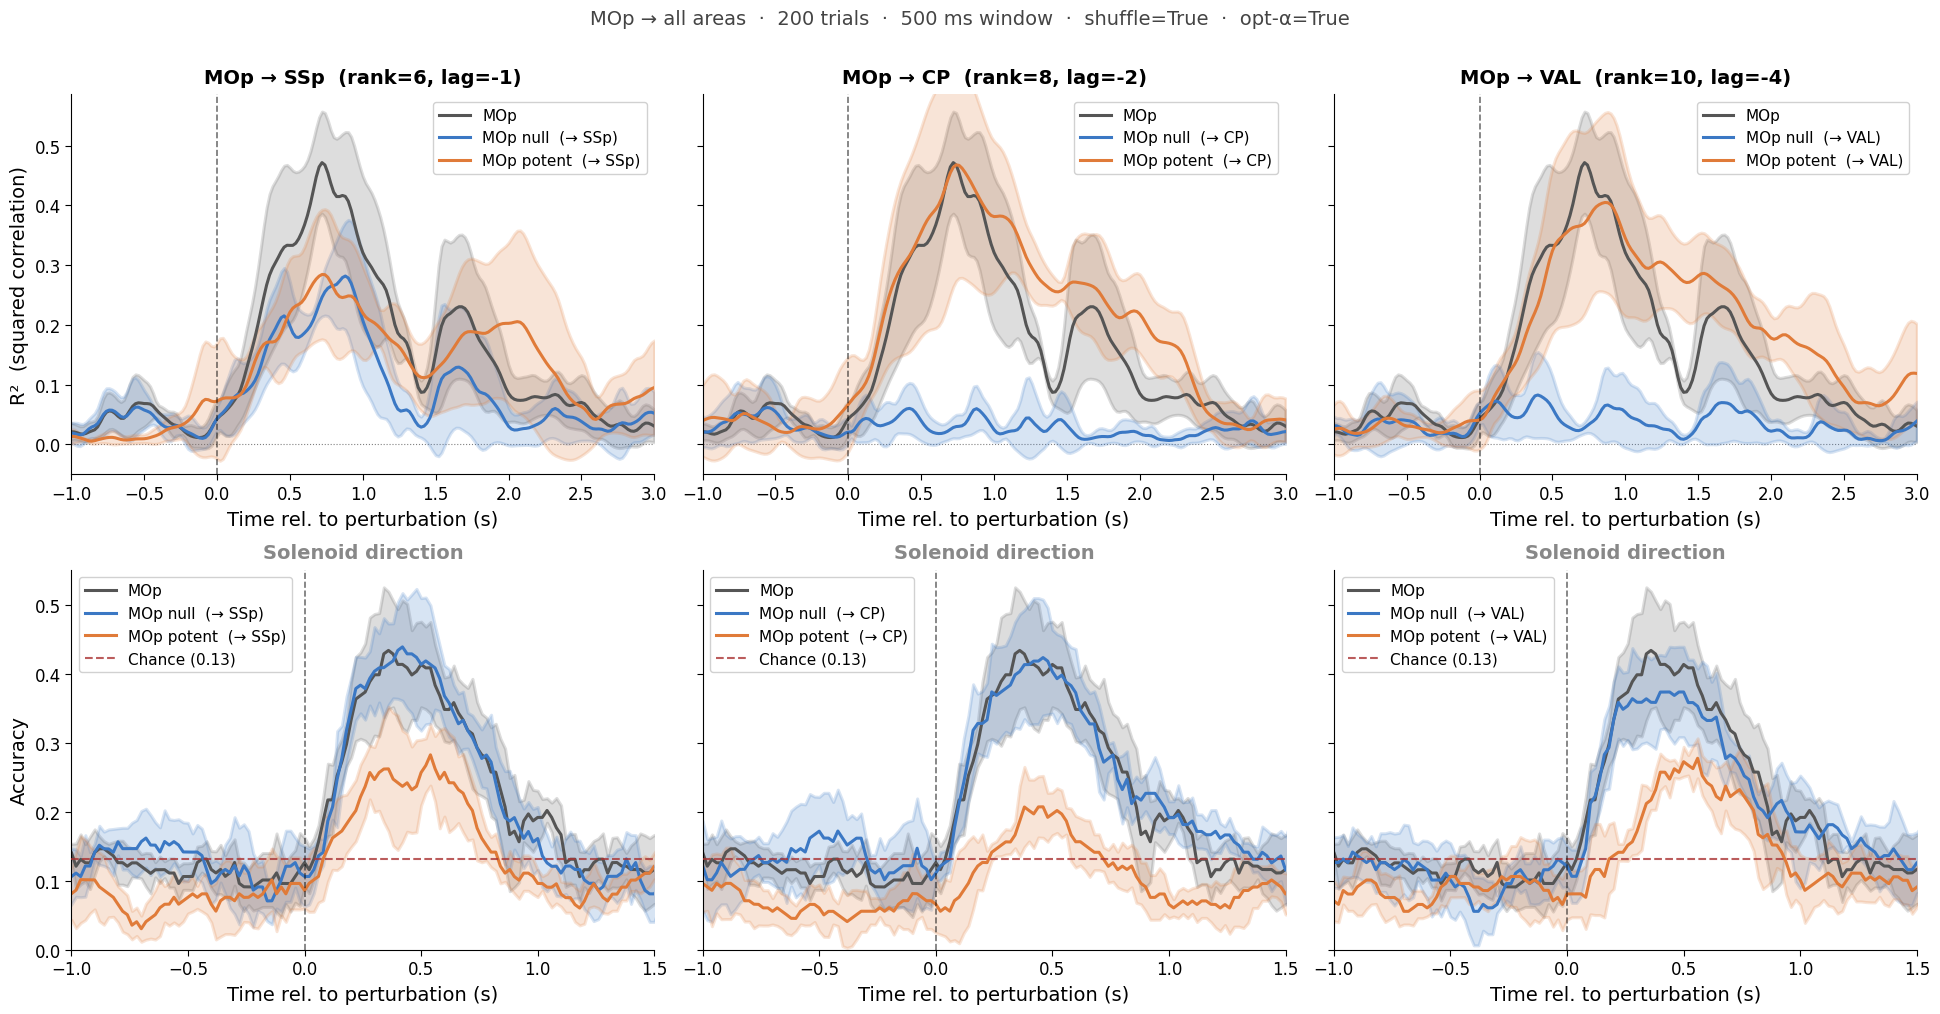

In [27]:

# ── Plot semedo_results: disturbance score & solenoid direction for all areas ──
FS      = 14
FS_TICK = 12
FS_LEG  = 11
LW      = 2.2
ALPHA   = 0.20

areas_done = list(semedo_results.keys())
n_areas    = len(areas_done)

fig, axes = plt.subplots(2, n_areas, figsize=(6.5 * n_areas, 10),
                         sharey='row')
fig.patch.set_facecolor('white')

for col, tgt in enumerate(areas_done):
    res    = semedo_results[tgt]
    t      = res['times']     - 2.0
    t_dir  = res['times_dir'] - 2.0
    ch     = res['chance']
    rank   = res['opt_rank']
    lag    = res['shift_bins']

    labels = {
        'full'   : area_origin,
        'potent' : f'{area_origin} potent  (→ {tgt})',
        'null'   : f'{area_origin} null  (→ {tgt})',
    }

    # ── Row 0: disturbance score ───────────────────────────────────────────────
    ax = axes[0, col]
    for sc, key in zip(res['scores_perturb'], ['full', 'null', 'potent']):
        vizutils.shaded_errorbar(ax, t, sc,
                                 label=labels[key], color=SUBSPACE_COLORS[key],
                                 lw=LW, alpha_err=ALPHA)
    ax.axvline(0, color='k', linewidth=1.2, linestyle='--', alpha=0.55, zorder=5)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':', zorder=0)
    ax.set_xlim(-1.0, 3.0)
    ax.set_ylim(-0.05, None)
    ax.set_xlabel('Time rel. to perturbation (s)', fontsize=FS, labelpad=5)
    if col == 0:
        ax.set_ylabel('R²  (squared correlation)', fontsize=FS)
    ax.set_title(f'{area_origin} → {tgt}  (rank={rank}, lag={lag})',
                 fontsize=FS, pad=8, fontweight='bold')
    ax.tick_params(labelsize=FS_TICK, length=4)
    ax.legend(fontsize=FS_LEG, framealpha=0.9, edgecolor='#CCCCCC')
    sns.despine(ax=ax)

    # ── Row 1: solenoid direction ──────────────────────────────────────────────
    ax = axes[1, col]
    for sc, key in zip(res['scores_dir'], ['full', 'null', 'potent']):
        vizutils.shaded_errorbar(ax, t_dir, sc,
                                 label=labels[key], color=SUBSPACE_COLORS[key],
                                 lw=LW, alpha_err=ALPHA)
    ax.axhline(ch, color='#AA3333', linewidth=1.5, linestyle='--',
               label=f'Chance ({ch:.2f})', alpha=0.8, zorder=5)
    ax.axvline(0, color='k', linewidth=1.2, linestyle='--', alpha=0.55, zorder=5)
    ax.set_xlim(-1.0, 1.5)
    ax.set_ylim(0, None)
    ax.set_xlabel('Time rel. to perturbation (s)', fontsize=FS, labelpad=5)
    if col == 0:
        ax.set_ylabel('Accuracy', fontsize=FS)
    ax.set_title(f'Solenoid direction', fontsize=FS, pad=8,
                 fontweight='bold', color='#888888')
    ax.tick_params(labelsize=FS_TICK, length=4)
    ax.legend(fontsize=FS_LEG, framealpha=0.9, edgecolor='#CCCCCC')
    sns.despine(ax=ax)

plt.suptitle(
    f'{area_origin} → all areas  ·  {idx_to_keep} trials'
    f'  ·  {window * 0.01 * 1000:.0f} ms window  ·  shuffle={shuffle}  ·  opt-α={opt_alpha}',
    fontsize=FS, y=1.01, color='#444444',
)
plt.tight_layout()
plt.show()


In [9]:

# ── Transmission Index (TI) summary ───────────────────────────────────────────
#
#   TI = (AUC_potent − AUC_null) / AUC_full   over [epoch_start, epoch_end]
#
#   +1 → signal lives entirely in the communicating (potent) dimensions
#   −1 → signal lives entirely in the locally retained (null) dimensions
#
#   DD (double dissociation) = TI_disturbance − TI_direction
#      Large positive → disturbance in potent, direction in null (ideal dissociation)

EPOCH_DIST = (0.0, 1.5)   # s post-perturbation — disturbance score peak window
EPOCH_DIR  = (0.0, 1.0)   # s post-perturbation — direction accuracy peak window

def auc_in_epoch(scores_arr, times, epoch):
    """Mean score over the given epoch.
    scores_arr shape: (n_times, n_folds) — average across folds first, then epoch."""
    mask = (times >= epoch[0]) & (times <= epoch[1])
    return scores_arr[mask].mean()   # mean over both time and folds

areas_done = list(semedo_results.keys())

ti_dist = {}
ti_dir  = {}
dd      = {}

for tgt in areas_done:
    res   = semedo_results[tgt]
    t     = res['times']     - 2.0
    t_dir = res['times_dir'] - 2.0

    sc_full_d,   sc_null_d,   sc_pot_d   = res['scores_perturb']  # [full, null, potent]
    sc_full_dir, sc_null_dir, sc_pot_dir = res['scores_dir']

    auc_full_d   = auc_in_epoch(sc_full_d,   t,     EPOCH_DIST)
    auc_null_d   = auc_in_epoch(sc_null_d,   t,     EPOCH_DIST)
    auc_pot_d    = auc_in_epoch(sc_pot_d,    t,     EPOCH_DIST)

    auc_full_dir = auc_in_epoch(sc_full_dir, t_dir, EPOCH_DIR)
    auc_null_dir = auc_in_epoch(sc_null_dir, t_dir, EPOCH_DIR)
    auc_pot_dir  = auc_in_epoch(sc_pot_dir,  t_dir, EPOCH_DIR)

    ti_dist[tgt] = (auc_pot_d   - auc_null_d)   / auc_full_d   if auc_full_d   > 0 else np.nan
    ti_dir[tgt]  = (auc_pot_dir - auc_null_dir)  / auc_full_dir if auc_full_dir > 0 else np.nan
    dd[tgt]      = ti_dist[tgt] - ti_dir[tgt]

    print(f'{area_origin} → {tgt}:  TI_dist={ti_dist[tgt]:+.3f}  TI_dir={ti_dir[tgt]:+.3f}  DD={dd[tgt]:+.3f}')

# ── Heatmap ────────────────────────────────────────────────────────────────────
FS       = 14
FS_TICK  = 13
FS_ANNOT = 12

ti_matrix = np.array([[ti_dist[a], ti_dir[a]] for a in areas_done]).T   # (2, n_areas)

fig, axes = plt.subplots(1, 2, figsize=(max(6, 3.5 * len(areas_done)), 4),
                          gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.35})
fig.patch.set_facecolor('white')

# ── Left: TI heatmap ──────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(ti_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(areas_done)))
ax.set_xticklabels([f'{area_origin}→{a}' for a in areas_done], fontsize=FS_TICK)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Disturbance\nscore', 'Solenoid\ndirection'], fontsize=FS_TICK)
for r, vals in enumerate([ti_dist, ti_dir]):
    for c, a in enumerate(areas_done):
        v = vals[a]
        ax.text(c, r, f'{v:+.2f}', ha='center', va='center',
                fontsize=FS_ANNOT, fontweight='bold',
                color='white' if abs(v) > 0.5 else 'black')
plt.colorbar(im, ax=ax, label='(potent − null) / full', shrink=0.75, pad=0.02)
ax.set_title(f'(epoch: dist {EPOCH_DIST} s · dir {EPOCH_DIR} s)',
             fontsize=FS, pad=10, fontweight='bold')
ax.tick_params(length=0)
sns.despine(ax=ax, left=True, bottom=True)

# ── Right: DD bar chart ───────────────────────────────────────────────────────
ax = axes[1]
colors_dd = [SUBSPACE_COLORS['potent'] if dd[a] > 0 else SUBSPACE_COLORS['null']
             for a in areas_done]
bars = ax.bar(areas_done, [dd[a] for a in areas_done],
              color=colors_dd, edgecolor='none', width=0.55)
for bar, a in zip(bars, areas_done):
    v = dd[a]
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + (0.015 if v >= 0 else -0.03),
            f'{v:+.2f}', ha='center', va='bottom' if v >= 0 else 'top',
            fontsize=FS_ANNOT, fontweight='bold')
ax.axhline(0, color='k', linewidth=1.0, linestyle='--')
ax.set_ylabel('Double dissociation  (dist − dir)', fontsize=FS - 1)
ax.set_title('Dissociation score\nper area', fontsize=FS, pad=10, fontweight='bold')
ax.tick_params(labelsize=FS_TICK, length=4)
ax.set_ylim(min(-0.1, min(dd.values()) * 1.25), max(0.1, max(dd.values()) * 1.25))
sns.despine(ax=ax)

# plt.suptitle(f'{area_origin} → all areas  ·  TI & double dissociation summary',
#              fontsize=FS, y=1.02, color='#444444')
plt.tight_layout()
plt.show()


NameError: name 'semedo_results' is not defined

In [10]:

# ── Kinematic decoding from potent / null ──────────────────────────────────────
#
#   (1) global  – all trial × time bins concatenated → single cross-val R²
#   (2) window  – time-resolved moving-window R²  (same 50-bin window as disturbance decoder)
#
BHV_COL    = 'bhv'
K_KIN      = 5
WINDOW_KIN = window    # 50 bins = 0.5 s (defined in the semedo loop cell)


def _decode_bhv_global(td, area_origin, area_target, bhv_col=BHV_COL, k=K_KIN,
                       scorer=decode.get_custom_scorer()):
    """Cross-validated Ridge on ALL (trials × time) points concatenated.
    KFold(shuffle=False) — trials already shuffled in td_pair, don't re-shuffle timepoints.
    Returns dict: key → cv-score array of shape (k,)."""
    y_raw = np.stack(td[bhv_col].values)          # (n_trials, T, 36)
    n_tr, T, n_bhv = y_raw.shape
    y_flat = y_raw.reshape(n_tr * T, n_bhv)

    labels = {
        'full':   f'{area_origin}_rates_pca',
        'null':   f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        'potent': f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
    }
    cv = KFold(n_splits=k, shuffle=False)
    results = {}
    for key, col in labels.items():
        X_flat = np.stack(td[col].values).reshape(n_tr * T, -1)
        alpha  = _opt_ridge_alpha(X_flat, y_flat, cv=cv, scorer=scorer)
        scores = cross_val_score(Ridge(alpha, solver='lsqr'), X_flat, y_flat,
                                 cv=cv, scoring=scorer)
        results[key] = scores
        print(f'    {key:8s}  alpha={alpha:.3g}  R²={scores.mean():.4f}±{scores.std():.4f}')
    return results


def _decode_bhv_window(td, area_origin, area_target, bhv_col=BHV_COL, k=K_KIN,
                       window=WINDOW_KIN, step_bin=2, scorer=decode.get_custom_scorer()):
    """Time-resolved moving-window Ridge on kinematics.
    Pre-optimises alpha on flattened data, then calls decode.regression_moving_window.
    Returns (results_dict, times):  results dict key → shape (n_times, k)."""
    y_raw = np.stack(td[bhv_col].values)          # (n_trials, T, 36)
    n_tr, T, n_bhv = y_raw.shape

    labels = {
        'full':   f'{area_origin}_rates_pca',
        'null':   f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        'potent': f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
    }
    cv = KFold(n_splits=k, shuffle=False)
    results   = {}
    times_out = None
    for key, col in labels.items():
        X_raw = np.stack(td[col].values)           # (n_trials, T, n_comp)
        alpha = _opt_ridge_alpha(
            X_raw.reshape(n_tr * T, -1),
            y_raw.reshape(n_tr * T, n_bhv),
            cv=cv, scorer=scorer,
        )
        scores, t = decode.regression_moving_window(
            X_raw, y_raw,
            alpha=alpha, cv=cv, scorer=scorer,
            window_length_bin=window, step_bin=step_bin,
        )
        results[key] = scores
        if times_out is None:
            times_out = t
        print(f'    {key:8s}  alpha={alpha:.3g}  peak_R²={scores.mean(axis=1).max():.4f}')
    return results, times_out


# ── Loop over all semedo_results ───────────────────────────────────────────────
kin_results = {}

for area_target, res in semedo_results.items():
    td_pair = res['td_pair']

    # Same trial selection as disturbance decoder
    idx    = sorted(dstrb_idx[2:idx_to_keep])
    td_dec = (
        td_pair[td_pair['index'].isin(idx)]
        .sort_values(by='trial_id')
        .reset_index(drop=True)
    )

    print(f'\n{"─"*55}')
    print(f'  Kin decode  {area_origin} → {area_target}  (n_trials={len(td_dec)})')
    print(f'{"─"*55}')

    print('  [global]')
    global_scores = _decode_bhv_global(td_dec, area_origin, area_target)

    print('  [window]')
    window_scores, kin_times = _decode_bhv_window(td_dec, area_origin, area_target)

    kin_results[area_target] = dict(
        global_scores = global_scores,    # dict key → shape (k,)
        window_scores = window_scores,    # dict key → shape (n_times, k)
        times         = kin_times,
    )
    print(f'  ✓ {area_origin} → {area_target}')

print(f'\nAll done.  kin_results keys: {list(kin_results.keys())}')


NameError: name 'window' is not defined